# AI-Powered GHDB Attack Surface Intelligence Platform

**A reproducible research pipeline for search-engine reconnaissance, exposure classification, and risk-based attack-surface analysis — executed entirely against a self-contained synthetic target.**

---

## 1. Project Overview

Search-engine reconnaissance ("Google dorking", formalised by the **Google Hacking Database / GHDB**) is one of the oldest and still one of the most productive techniques in the offensive-security toolkit. It is *passive*: the attacker never touches the target, they query a third-party index that has already crawled it. That property makes it invisible to the defender and cheap for the adversary, which is precisely why mature security programmes run their own continuous dork-based exposure monitoring.

The hard part of operationalising GHDB reconnaissance is not writing dorks. It is everything downstream:

1. **Selection** — the public GHDB contains thousands of queries. Which ones actually apply to *this* organisation's technology stack and asset inventory?
2. **Triage** — a broad dork sweep returns mostly noise. Which results are real exposures and which are false positives?
3. **Prioritisation** — "a config file is exposed" is not a severity. Severity is a function of exposure type, asset criticality, discoverability, authentication state, information sensitivity, and detection confidence.
4. **Measurement** — most published dorking work is anecdotal. Without ground truth you cannot state a detection rate, a false-negative rate, or whether a "smarter" query-selection strategy is actually smarter.

This notebook builds the full pipeline and, critically, **measures it**. Because the target environment is synthesised by the notebook itself, every exposure has a known label, so detection rate, precision, recall, and coverage are computed rather than asserted.

### Pipeline

```
Controlled Synthetic Target
   -> Asset Discovery
   -> Technology Fingerprinting
   -> GHDB Query Selection      (rule-based | technology-aware | TF-IDF ranked | optional LLM)
   -> Search Backend            (deterministic offline index | optional authorised live backend)
   -> Result Collection
   -> Finding Extraction        (normalise, dedupe, group)
   -> Finding Classification    (rule baseline vs. TF-IDF + linear model)
   -> Risk Scoring              (transparent multi-factor 0-100 model)
   -> Attack-Surface Graph      (NetworkX)
   -> Evaluation                (ground truth, ablation, error analysis)
   -> Security Report           (HTML + CSV/JSON exports)
   -> Interactive Dashboard     (Gradio)
```

### What is measured, not claimed

| Question | How it is answered |
|---|---|
| Does technology-aware query selection beat static selection? | Experiment 2 vs. Experiment 1, precision/recall against ground truth |
| Does an ML classifier beat keyword rules? | Section 18, macro-F1 on a held-out test split |
| Which features carry the signal? | Section 24, feature ablation |
| Where does the classifier fail and why? | Section 25, automated error analysis |
| Which GHDB families are worth running? | Section 22, findings-per-query and high-risk yield |

### Runtime profile

CPU-only Google Colab runtime. No GPU, no API keys, no downloaded datasets, no multi-GB models. End-to-end execution is on the order of a minute.

## 2. Threat Model & Ethical Scope

### 2.1 Scope statement

**All reconnaissance in this notebook is performed against a synthetic target environment that the notebook generates in memory at runtime.** No third-party system is contacted. No real domain is queried. The organisation "Acme Research Technologies" and its `*.acme.local` hosts do not exist; `.local` is a reserved special-use namespace (RFC 6762) and is not resolvable on the public internet.

The default execution path (`SEARCH_MODE = "offline"`) makes **zero outbound network requests** of any kind.

### 2.2 Threat model being emulated

| Element | Definition |
|---|---|
| **Adversary** | Unauthenticated external actor with no prior access and no relationship to the target. |
| **Capability** | Read-only queries against a public search index. No crawling, no scanning, no authentication attempts. |
| **Objective** | Enumerate the organisation's externally discoverable attack surface and identify indexed content that should not be public. |
| **Defender's mirror-image goal** | Run the same sweep first, so exposures are remediated before they are exploited. That is the purpose of this tooling. |

This is a **reconnaissance** model, deliberately stopping at the boundary of exploitation. Discovery of an exposure is the terminal state of the pipeline; what follows is a remediation recommendation, not an attack path.

### 2.3 Explicit non-goals

This notebook does **not** implement, and must not be extended to implement:

- credential theft, harvesting, or validation
- retrieval of real leaked secrets, keys, or credential dumps
- authentication bypass of any kind
- vulnerability exploitation or payload generation
- scanning, crawling, or probing of arbitrary internet hosts
- circumvention of search-engine protections, CAPTCHAs, or rate limits
- destructive or state-changing operations against any system

Every secret-shaped string in the synthetic corpus is a self-labelling placeholder (`DEMO_NOT_A_REAL_KEY`, `FAKE_PASSWORD_ONLY`) chosen so that it cannot be mistaken for, or mined as, a real credential.

### 2.4 The optional live backend

An `AuthorizedLiveSearchBackend` interface is defined in Section 10 for completeness of the architecture. It is **disabled by default and ships without a working provider implementation**. It refuses to operate unless the user supplies (a) their own search-provider credentials and (b) an explicit allow-list of domains, and it hard-blocks any query outside that allow-list. It contains no rate-limit evasion, no user-agent rotation, no proxy support, and no scraping fallback — by design.

If you enable it, you are asserting that you have **written authorisation** to assess the listed domains. That assertion is yours, not the notebook's.

### 2.5 Legal note

Passive search-engine reconnaissance against systems you do not own or have written permission to assess may still constitute unauthorised access or a terms-of-service violation depending on jurisdiction and technique. Consult counsel and obtain a signed scope document before any real-world engagement. Nothing here is legal advice.

## 3. Architecture

The notebook is organised as a set of small, single-responsibility components. Each is independently testable and none depends on notebook execution order beyond its declared inputs.

```
                         ┌────────────────────────┐
                         │   TargetEnvironment    │  synthetic org, assets,
                         │  (ground-truth corpus) │  documents, labels
                         └───────────┬────────────┘
                                     │
             ┌───────────────────────┼────────────────────────┐
             ▼                       ▼                        ▼
    ┌─────────────────┐   ┌──────────────────────┐   ┌──────────────────┐
    │ AssetDiscovery  │   │ TechnologyFinger-    │   │  SearchBackend   │
    │                 │   │ printer              │   │  (abstract)      │
    └────────┬────────┘   └──────────┬───────────┘   ├──────────────────┤
             │                       │               │ Offline (default)│
             └───────────┬───────────┘               │ AuthorizedLive   │
                         ▼                           └─────────┬────────┘
              ┌────────────────────┐                           │
              │  GHDBQueryEngine   │  static / tech-aware /     │
              │  + GHDB_CATALOG    │  TF-IDF ranked / LLM  ─────┘
              └─────────┬──────────┘
                        ▼
              ┌────────────────────┐
              │  FindingExtractor  │  normalise, dedupe, group
              └─────────┬──────────┘
                        ▼
        ┌───────────────┼────────────────┬──────────────────┐
        ▼               ▼                ▼                  ▼
┌───────────────┐ ┌────────────┐ ┌───────────────┐ ┌────────────────┐
│FindingClassi- │ │ RiskScorer │ │AttackSurface  │ │  LLMAnalyzer   │
│fier (rule/ML) │ │  0-100     │ │Graph (NetworkX│ │  (optional)    │
└───────┬───────┘ └─────┬──────┘ └───────┬───────┘ └────────┬───────┘
        └───────────────┴────────────────┴──────────────────┘
                        ▼
              ┌────────────────────┐    ┌───────────────────┐
              │  EvaluationEngine  │───▶│  ReportGenerator  │
              │  (ground truth,    │    │  HTML + CSV/JSON  │
              │   ablation, error) │    └───────────────────┘
              └────────────────────┘             │
                        └────────────────────────┴──▶ Gradio Dashboard
```

### Component contracts

| Component | Input | Output |
|---|---|---|
| `TargetEnvironment` | `CONFIG`, seed | `Asset[]`, `CorpusDocument[]` with ground-truth labels |
| `AssetDiscovery` | corpus | `DiscoveredAsset[]` with criticality |
| `TechnologyFingerprinter` | corpus | asset → technology evidence map |
| `GHDBQueryEngine` | assets, technologies, catalog | ranked `GHDBQuery[]` |
| `SearchBackend` | dork string | `SearchResult[]` |
| `FindingExtractor` | `SearchResult[]` | deduplicated `Finding[]` |
| `FindingClassifier` | `Finding[]` / corpus | predicted exposure class + confidence |
| `RiskScorer` | `Finding` | `RiskAssessment` (0-100, band, factor breakdown) |
| `AttackSurfaceGraph` | assets, techs, findings | `nx.MultiDiGraph` + centrality metrics |
| `EvaluationEngine` | findings, ground truth | detection/FN/FP rates, coverage |
| `ReportGenerator` | everything | HTML report + data exports |

### Design rules followed

- Dataclasses for every domain object; type hints throughout.
- No global mutable state outside `CONFIG` and the seeded RNG.
- Vectorisers and models are fit on the training split only — never on validation or test.
- All randomness flows from a single seed; two runs produce identical artefacts.
- No performance number in this notebook is hard-coded. Every metric is computed at execution time.

## 4. Environment Setup

The cell below installs only what is missing. In Colab, `pandas`, `numpy`, `scikit-learn`, `matplotlib`, `networkx`, `requests`, and `beautifulsoup4` are pre-installed, so a fresh runtime typically only needs `gradio` (and sometimes `plotly`).

`gradio` and `plotly` are **optional**. Every figure in this notebook is matplotlib, deliberately — static images render identically in Colab, in a saved `.ipynb`, in nbviewer, and in the exported report, whereas interactive plotly output is lost in several of those. `plotly` is installed and detected only so the environment check is complete; if it is missing, nothing changes. If `gradio` is missing, Section 27 reports that the dashboard was skipped and the notebook continues. Nothing in the analytical pipeline depends on either.

In [1]:
# --- Dependency bootstrap -----------------------------------------------------
# Installs only packages that are genuinely missing. Safe to re-run.

import importlib
import subprocess
import sys

REQUIRED = {
    # import name -> pip name
    "numpy": "numpy",
    "pandas": "pandas",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
    "networkx": "networkx",
    "joblib": "joblib",
    "requests": "requests",
    "bs4": "beautifulsoup4",
}

OPTIONAL = {
    "gradio": "gradio",   # interactive dashboard (Section 27)
    "plotly": "plotly",   # optional interactive charts
}


def _is_available(import_name: str) -> bool:
    try:
        importlib.import_module(import_name)
        return True
    except Exception:
        return False


def _pip_install(pkgs) -> None:
    if not pkgs:
        return
    print(f"Installing: {', '.join(pkgs)}")
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", *pkgs],
        check=False,
    )


missing_required = [pip for imp, pip in REQUIRED.items() if not _is_available(imp)]
missing_optional = [pip for imp, pip in OPTIONAL.items() if not _is_available(imp)]

_pip_install(missing_required)
_pip_install(missing_optional)

if not missing_required and not missing_optional:
    print("All dependencies already present - nothing to install.")

print("\nEnvironment:")
print(f"  Python {sys.version.split()[0]}")
for imp, pip in {**REQUIRED, **OPTIONAL}.items():
    try:
        mod = importlib.import_module(imp)
        print(f"  {pip:<16} {getattr(mod, '__version__', 'unknown')}")
    except Exception:
        print(f"  {pip:<16} NOT AVAILABLE (optional features disabled)")

All dependencies already present - nothing to install.

Environment:
  Python 3.12.13
  numpy            2.0.2
  pandas           2.2.2
  scikit-learn     1.6.1
  matplotlib       3.10.0
  networkx         3.6.1
  joblib           1.5.3
  requests         2.32.4
  beautifulsoup4   4.13.5
  gradio           6.20.0
  plotly           5.24.1


## 5. Configuration

A single `CONFIG` dictionary controls every switch in the notebook. **The defaults below are the supported path**: fully offline, no API keys, no Drive, deterministic.

| Key | Default | Meaning |
|---|---|---|
| `USE_GOOGLE_DRIVE` | `False` | Mount Drive and cache artefacts there instead of `/content` |
| `USE_LLM` | `False` | Enable optional LLM finding analysis (Section 20) |
| `SEARCH_MODE` | `"offline"` | `"offline"` \| `"authorized_live"` — live requires explicit allow-list |
| `RANDOM_SEED` | `42` | Global seed for Python, NumPy, and scikit-learn |
| `OUTPUT_DIR` | `/content/ghdb_project` | Root of all generated artefacts |
| `CORPUS_SIZE` | `1600` | Number of synthetic indexed documents to generate |
| `DECOY_RATE` | `0.16` | Fraction of documents given cross-class vocabulary noise |
| `AMBIGUITY_RATE` | `0.34` | Fraction of documents structurally camouflaged as a confusable class |
| `RESULTS_PER_QUERY` | `30` | Search-result cap per dork, mirroring a realistic page-one/two harvest |
| `LAUNCH_DASHBOARD` | `False` | Whether Section 27 actually calls `demo.launch()` |

In [2]:
# --- Configuration ------------------------------------------------------------

CONFIG = {
    "USE_GOOGLE_DRIVE": False,
    "USE_LLM": False,
    "SEARCH_MODE": "offline",       # "offline" | "authorized_live"
    "RANDOM_SEED": 42,
    "OUTPUT_DIR": "/content/ghdb_project",

    # --- synthetic environment ---
    "ORG_NAME": "Acme Research Technologies",
    "ORG_DOMAIN": "acme.local",
    "CORPUS_SIZE": 1600,
    "DECOY_RATE": 0.16,
    "AMBIGUITY_RATE": 0.34,

    # --- reconnaissance ---
    "RESULTS_PER_QUERY": 30,
    "INTELLIGENT_TOP_K_QUERIES": 26,

    # --- ML ---
    "TRAIN_FRAC": 0.70,
    "VAL_FRAC": 0.15,
    "TEST_FRAC": 0.15,

    # --- optional live search (see Section 9 / 10) ---
    "LIVE_SEARCH_ALLOWLIST": [],    # e.g. ["example-you-own.com"]
    "LIVE_SEARCH_PROVIDER": None,
    "LIVE_SEARCH_API_KEY": None,

    # --- optional LLM ---
    "LLM_PROVIDER": None,           # "anthropic" | "openai" | None
    "LLM_MODEL": None,
    "LLM_API_KEY": None,

    # --- dashboard ---
    "LAUNCH_DASHBOARD": False,
    "DASHBOARD_SHARE": False,
}

In [3]:
# --- Reproducibility, logging, and output scaffolding -------------------------

import json
import logging
import os
import random
from pathlib import Path

import numpy as np

SEED: int = int(CONFIG["RANDOM_SEED"])

random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# A dedicated RNG for corpus synthesis keeps generation independent of any
# incidental use of the global RNG elsewhere in the notebook.
RNG = random.Random(SEED)
NP_RNG = np.random.default_rng(SEED)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)-7s | %(name)-22s | %(message)s",
    datefmt="%H:%M:%S",
    force=True,
)
logger = logging.getLogger("ghdb.platform")


def _resolve_output_root() -> Path:
    """Resolve the artefact root, optionally mounting Google Drive."""
    if CONFIG["USE_GOOGLE_DRIVE"]:
        try:
            from google.colab import drive  # type: ignore

            drive.mount("/content/drive", force_remount=False)
            root = Path("/content/drive/MyDrive/ghdb_project")
            logger.info("Google Drive mounted; artefacts -> %s", root)
            return root
        except Exception as exc:  # not in Colab, or user declined
            logger.warning("Drive mount unavailable (%s); falling back to local path.", exc)
    return Path(CONFIG["OUTPUT_DIR"])


OUTPUT_ROOT: Path = _resolve_output_root()

SUBDIRS = ["data", "models", "results", "reports", "figures", "cache"]
PATHS = {name: OUTPUT_ROOT / name for name in SUBDIRS}
for _p in PATHS.values():
    _p.mkdir(parents=True, exist_ok=True)

logger.info("Output root: %s", OUTPUT_ROOT)
logger.info("Subdirectories: %s", ", ".join(SUBDIRS))
logger.info("Seed: %d | search mode: %s | LLM: %s",
            SEED, CONFIG["SEARCH_MODE"], CONFIG["USE_LLM"])

16:45:33 | INFO    | ghdb.platform          | Output root: /content/ghdb_project
16:45:33 | INFO    | ghdb.platform          | Subdirectories: data, models, results, reports, figures, cache
16:45:33 | INFO    | ghdb.platform          | Seed: 42 | search mode: offline | LLM: False


In [4]:
# --- Shared imports and plotting defaults -------------------------------------

import html
import math
import re
import textwrap
import warnings
from abc import ABC, abstractmethod
from collections import Counter, defaultdict
from dataclasses import dataclass, field, asdict
from datetime import datetime, timezone
from typing import Any, Dict, Iterable, List, Optional, Sequence, Tuple

import matplotlib
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

matplotlib.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.frameon": False,
    "font.size": 10,
})

# Severity palette used consistently across every figure and the HTML report.
SEVERITY_ORDER = ["Informational", "Low", "Medium", "High", "Critical"]
SEVERITY_COLORS = {
    "Informational": "#6b7280",
    "Low": "#3b82f6",
    "Medium": "#eab308",
    "High": "#f97316",
    "Critical": "#dc2626",
}
ACCENT = "#2563eb"

try:
    import plotly.express as px  # noqa: F401
    PLOTLY_AVAILABLE = True
except Exception:
    PLOTLY_AVAILABLE = False

try:
    import gradio as gr  # noqa: F401
    GRADIO_AVAILABLE = True
except Exception:
    GRADIO_AVAILABLE = False


def save_fig(fig, name: str) -> Path:
    """Persist a matplotlib figure to the figures directory."""
    path = PATHS["figures"] / f"{name}.png"
    fig.savefig(path)
    return path


print(f"plotly available : {PLOTLY_AVAILABLE}")
print(f"gradio available : {GRADIO_AVAILABLE}")
print(f"pandas {pd.__version__} | numpy {np.__version__} | networkx {nx.__version__}")

plotly available : True
gradio available : True
pandas 2.2.2 | numpy 2.0.2 | networkx 3.6.1


## 6. Synthetic Target Environment

This is the foundation of the whole project. Everything downstream — search, classification, risk, evaluation — is only meaningful because this environment carries **ground truth for every single document**.

### 6.1 The organisation

**Acme Research Technologies** is a fictional mid-size R&D company. Its (non-resolvable, RFC 6762 reserved) attack surface:

| Host | Role | Criticality | Auth expected |
|---|---|---|---|
| `acme.local` | Corporate marketing site | 0.55 | No |
| `admin.acme.local` | Internal administrative portal | 1.00 | Yes |
| `api.acme.local` | Public + internal API gateway | 0.90 | Yes |
| `files.acme.local` | File / artefact server | 0.85 | Yes |
| `legacy.acme.local` | Decommission-pending legacy app | 0.80 | Yes |
| `staging.acme.local` | Pre-production mirror | 0.75 | Yes |
| `dev.acme.local` | Developer sandbox | 0.70 | Yes |
| `docs.acme.local` | Product documentation | 0.45 | No |

"Auth expected" records what *should* be true. A document on an auth-expected host that is nonetheless indexed and reachable is, by definition, a control failure.

### 6.2 Exposure taxonomy

Eleven ground-truth classes. Ten are exposures; `benign_content` is the negative class and is deliberately the largest, because in real dork sweeps most of what you retrieve is legitimate public content.

| Class | Base severity | What it represents |
|---|---|---|
| `config_artifact` | 9.5 | `.env` / `settings.ini` / `config.yaml` reachable from the index |
| `backup_artifact` | 9.0 | `*.sql`, `*.zip`, `*.bak` database and site backups |
| `admin_interface` | 8.5 | Administrative login and console pages |
| `debug_page` | 7.5 | Stack traces, framework debug consoles, `phpinfo`-style output |
| `legacy_application` | 7.0 | Outdated, unmaintained application surfaces |
| `dev_environment` | 6.5 | Developer sandboxes, test harnesses |
| `directory_listing` | 6.0 | Autoindex pages disclosing file trees |
| `staging_environment` | 6.0 | Pre-production mirrors carrying production-shaped data |
| `exposed_document` | 5.5 | Internal PDFs / spreadsheets / CSVs published unintentionally |
| `api_documentation` | 4.5 | Interface specs that widen the attack surface map |
| `benign_content` | 0.5 | Intentionally public content (negative class) |

### 6.3 Making the classification problem real

This deserves to be stated plainly, because it is the difference between a portfolio project and a demo.

A synthetic corpus in which every backup file has `backup` in its filename yields a classifier with 100% test accuracy, a confusion matrix that is a clean diagonal, an ablation study where every feature block scores identically, and an error analysis section with nothing in it. The metrics would be real in the sense of being computed rather than fabricated — and completely uninformative, because the generator would have made the task trivially separable. **An early build of this notebook did exactly that and scored a perfect 1.000 macro-F1**, which is what prompted the two mechanisms below.

**Decoy vocabulary (`DECOY_RATE`, 16%).** Cross-class tokens are appended to a document's title or snippet: a benign press release that mentions "our staging rollout". Mild noise.

**Structural camouflage (`AMBIGUITY_RATE`, 34%).** Considerably stronger. A document keeps its true class but borrows its *surface form* — path, title, and/or snippet — from a **confusable partner class**, and is often relocated to the partner's host. A documentation page titled "Backup and Restore Guide" living at `/guides/backup_restore` is genuinely benign; a directory listing on the file server is genuinely full of archives. Surface form and true nature diverge, and that divergence is the entire reason dork triage is hard.

The constraint that makes this rigorous rather than arbitrary: **at most two of the three search-visible fields are ever borrowed**, so residual true-class signal always survives in at least one field. The task therefore stays learnable — but only by a model that *integrates evidence across fields*, which is exactly where a first-match keyword rule loses. That is the hypothesis Section 18 tests and Section 24 dissects.

Confusion pairs are chosen for semantic plausibility, not at random: `backup_artifact` ↔ `directory_listing` (both on the file server), `dev_environment` ↔ `staging_environment`, `admin_interface` ↔ `legacy_application`, `benign_content` ↔ `api_documentation`. Every document records `camouflaged_as` and `camouflaged_fields`, so Section 25 can test directly whether the classifier's errors concentrate on camouflaged documents — rather than hand-waving about why it failed.

### 6.4 Synthetic secret hygiene

Every credential-shaped value in the corpus is a self-identifying placeholder — `DEMO_NOT_A_REAL_KEY`, `FAKE_PASSWORD_ONLY`, `SYNTHETIC_TOKEN_DO_NOT_USE`. They are structurally incapable of authenticating to anything and are trivially greppable as non-secrets.

In [5]:
# --- Domain objects for the controlled target environment ---------------------

@dataclass(frozen=True)
class Asset:
    """A host in the synthetic organisation's attack surface."""
    host: str
    kind: str
    criticality: float          # 0..1, business impact if compromised
    description: str
    auth_expected: bool
    default_tech: Tuple[str, ...]


@dataclass
class CorpusDocument:
    """
    One document in the synthetic search index.

    Carries the ground-truth ``exposure_class`` that the rest of the notebook
    is measured against. Fields mirror what a real search engine exposes
    (url / title / snippet) plus environment metadata a defender would know.
    """
    doc_id: str
    host: str
    path: str
    url: str
    title: str
    snippet: str
    body: str
    file_type: str
    technology: str
    exposure_class: str
    is_exposure: bool
    auth_required: bool
    discoverability: float
    sensitivity: float
    exploitability: float
    is_decoy: bool
    camouflaged_as: Optional[str] = None      # surface form borrowed from this class
    camouflaged_fields: Tuple[str, ...] = ()  # which fields were borrowed

    @property
    def searchable_text(self) -> str:
        return f"{self.url} {self.title} {self.snippet} {self.body}"


# Placeholder tokens. Deliberately self-labelling so they can never be mistaken
# for, or mined as, real credentials.
FAKE_SECRETS = [
    "API_KEY=DEMO_NOT_A_REAL_KEY",
    "PASSWORD=FAKE_PASSWORD_ONLY",
    "DB_PASSWORD=FAKE_PASSWORD_ONLY",
    "SECRET_TOKEN=SYNTHETIC_TOKEN_DO_NOT_USE",
    "AWS_ACCESS_KEY_ID=EXAMPLE_NOT_REAL_0000",
    "JWT_SIGNING_KEY=PLACEHOLDER_VALUE_ONLY",
]

ASSETS: Tuple[Asset, ...] = (
    Asset("acme.local", "corporate", 0.55,
          "Public corporate and marketing site", False,
          ("nginx", "WordPress", "PHP")),
    Asset("admin.acme.local", "admin", 1.00,
          "Internal administrative portal", True,
          ("Apache", "PHP", "MySQL")),
    Asset("api.acme.local", "api", 0.90,
          "API gateway serving public and internal interfaces", True,
          ("nginx", "Node.js", "Express")),
    Asset("files.acme.local", "files", 0.85,
          "File and build-artefact server", True,
          ("Apache", "mod_autoindex")),
    Asset("legacy.acme.local", "legacy", 0.80,
          "Legacy application pending decommission", True,
          ("Apache", "PHP", "Struts")),
    Asset("staging.acme.local", "staging", 0.75,
          "Pre-production mirror of the production stack", True,
          ("nginx", "Django", "PostgreSQL")),
    Asset("dev.acme.local", "dev", 0.70,
          "Developer sandbox and CI preview environment", True,
          ("Flask", "Werkzeug", "Python")),
    Asset("docs.acme.local", "docs", 0.45,
          "Product and API documentation portal", False,
          ("nginx", "MkDocs")),
)

ASSET_BY_HOST: Dict[str, Asset] = {a.host: a for a in ASSETS}

EXPOSURE_CLASSES: Tuple[str, ...] = (
    "config_artifact",
    "backup_artifact",
    "admin_interface",
    "debug_page",
    "legacy_application",
    "dev_environment",
    "directory_listing",
    "staging_environment",
    "exposed_document",
    "api_documentation",
    "benign_content",
)

# Base severity (0-10) per exposure class. Used by the RiskScorer in Section 19.
CLASS_BASE_SEVERITY: Dict[str, float] = {
    "config_artifact": 9.5,
    "backup_artifact": 9.0,
    "admin_interface": 8.5,
    "debug_page": 7.5,
    "legacy_application": 7.0,
    "dev_environment": 6.5,
    "directory_listing": 6.0,
    "staging_environment": 6.0,
    "exposed_document": 5.5,
    "api_documentation": 4.5,
    "benign_content": 0.5,
}

print(f"Organisation : {CONFIG['ORG_NAME']}")
print(f"Assets       : {len(ASSETS)}")
print(f"Classes      : {len(EXPOSURE_CLASSES)} ({len(EXPOSURE_CLASSES) - 1} exposure + 1 benign)")

Organisation : Acme Research Technologies
Assets       : 8
Classes      : 11 (10 exposure + 1 benign)


In [6]:
# --- Generation specification for each exposure class -------------------------
# Data-driven so the corpus stays readable and easy to extend. Templates use
# {word}, {word2}, {n}, {year}, {ext} placeholders.

CLASS_SPEC: Dict[str, Dict[str, Any]] = {

    "admin_interface": {
        "hosts": {"admin.acme.local": 6, "legacy.acme.local": 2, "acme.local": 1, "staging.acme.local": 1},
        "paths": ["/admin", "/admin/login", "/admin/dashboard", "/administrator/index",
                  "/manage/console", "/admin/users/{word}", "/adminpanel/{word}",
                  "/cp/login", "/admin/settings/{word}"],
        "titles": ["Administrator Login", "Acme Admin Portal", "Management Console Sign In",
                   "Admin Dashboard - {word}", "Restricted Administration Area",
                   "Control Panel :: {word}"],
        "snippets": ["Enter administrator credentials to continue. Unauthorised access is prohibited.",
                     "Privileged console for managing {word} records and user sessions.",
                     "Sign in with your admin account to access the {word} management module.",
                     "Administration interface. Session timeout after 15 minutes of inactivity."],
        "body": ["username password login form csrf token session administrator role privilege",
                 "manage users roles permissions audit log administrative console backend"],
        "words": ["accounts", "billing", "tenants", "roles", "audit", "operators", "policies"],
        "filetypes": {"html": 9, "php": 3, "aspx": 1},
        "techs": ["Apache", "PHP", "nginx", "Struts"],
        "auth_prob": 0.80, "discover": (0.55, 0.85), "sens": (0.60, 0.85), "expl": (0.55, 0.85),
    },

    "directory_listing": {
        "hosts": {"files.acme.local": 7, "legacy.acme.local": 2, "dev.acme.local": 1, "staging.acme.local": 1},
        "paths": ["/files/", "/files/{word}/", "/uploads/{word}/", "/shared/{word}/",
                  "/pub/{word}/", "/archive/{year}/", "/repo/{word}/{word2}/"],
        "titles": ["Index of /{word}", "Index of /files/{word}", "Directory listing for /{word}",
                   "Index of /archive/{year}"],
        "snippets": ["Name Last modified Size Description Parent Directory {word}/ {year}",
                     "Apache Server at files.acme.local Port 80 - directory index of {word}",
                     "Index of /{word} - listing {n} entries including {word2} and subfolders."],
        "body": ["parent directory name last modified size description apache server autoindex listing",
                 "mod_autoindex fancy indexing enabled folder contents enumerated publicly"],
        "words": ["reports", "exports", "invoices", "assets", "drops", "transfer", "inbound", "builds"],
        "filetypes": {"html": 10},
        "techs": ["Apache", "mod_autoindex", "nginx"],
        "auth_prob": 0.10, "discover": (0.75, 0.98), "sens": (0.40, 0.70), "expl": (0.55, 0.80),
    },

    "backup_artifact": {
        "hosts": {"files.acme.local": 6, "legacy.acme.local": 2, "dev.acme.local": 1, "staging.acme.local": 1},
        "paths": ["/backups/{word}_backup_{year}.{ext}", "/files/backup_{year}.{ext}",
                  "/dumps/database_backup.{ext}", "/archive/{word}_dump_{n}.{ext}",
                  "/backup/site_backup_{year}.{ext}", "/old/{word}.{ext}"],
        "titles": ["backup_{year}.{ext}", "database_backup.{ext}", "{word}_dump_{n}.{ext}",
                   "Full site backup {year}", "Nightly {word} snapshot"],
        "snippets": ["SQL dump generated {year} - schema {word}, {n} tables, synthetic dataset only.",
                     "Archived backup bundle containing {word} exports and configuration snapshots.",
                     "mysqldump output for the {word} database. Demo data, no live records."],
        "body": ["mysqldump create table insert into schema dump backup archive snapshot restore tarball",
                 "zip archive contents web root database dump restore point retention nightly"],
        "words": ["crm", "billing", "hr", "inventory", "research", "portal", "wiki"],
        "filetypes": {"sql": 5, "zip": 4, "bak": 2, "tar": 2, "gz": 1},
        "techs": ["MySQL", "PostgreSQL", "Apache", "nginx"],
        "auth_prob": 0.05, "discover": (0.60, 0.90), "sens": (0.80, 1.00), "expl": (0.70, 0.95),
    },

    "config_artifact": {
        "hosts": {"dev.acme.local": 4, "staging.acme.local": 3, "files.acme.local": 2,
                  "legacy.acme.local": 2, "api.acme.local": 1},
        "paths": ["/.env", "/config/{word}.{ext}", "/settings/{word}_config.{ext}",
                  "/app/config/database.{ext}", "/conf/{word}.{ext}", "/{word}/.env.{word2}"],
        "titles": ["{word} configuration file", ".env - environment configuration",
                   "database.{ext}", "{word}_config.{ext}", "Application settings ({word})"],
        "snippets": [f"{FAKE_SECRETS[0]} DEBUG=true ENVIRONMENT={{word}} - synthetic placeholder values.",
                     f"{FAKE_SECRETS[1]} DB_HOST=localhost - demo configuration, not real credentials.",
                     f"{FAKE_SECRETS[3]} rotation interval 30d. All values are non-functional placeholders."],
        "body": [" ".join(FAKE_SECRETS) + " environment variables configuration ini yaml settings",
                 "connection string driver host port database user secret key placeholder synthetic config"],
        "words": ["staging", "worker", "queue", "cache", "mailer", "search", "auth"],
        "filetypes": {"env": 4, "ini": 3, "yaml": 3, "json": 2, "xml": 1, "php": 1},
        "techs": ["Django", "Flask", "Node.js", "PHP", "Express"],
        "auth_prob": 0.03, "discover": (0.55, 0.90), "sens": (0.85, 1.00), "expl": (0.75, 1.00),
    },

    "dev_environment": {
        "hosts": {"dev.acme.local": 8, "staging.acme.local": 1, "acme.local": 1},
        "paths": ["/dev", "/dev/{word}", "/test/{word}", "/sandbox/{word}",
                  "/dev/preview/{n}", "/ci/build/{n}", "/dev/api/{word}"],
        "titles": ["Development build - {word}", "Dev sandbox: {word}", "Test harness {word}",
                   "CI preview build #{n}", "Local development server"],
        "snippets": ["Development environment for the {word} service. Not for production use.",
                     "Werkzeug development server running. Feature branch {word}, build {n}.",
                     "Sandbox instance seeded with synthetic {word} fixtures for QA."],
        "body": ["development server werkzeug flask debug reload feature branch fixtures sandbox test harness",
                 "npm run dev localhost hot reload preview deployment build artifact ci pipeline"],
        "words": ["ingest", "reporting", "auth", "search", "notifier", "scheduler", "gateway"],
        "filetypes": {"html": 8, "json": 2},
        "techs": ["Flask", "Werkzeug", "Python", "Node.js"],
        "auth_prob": 0.15, "discover": (0.50, 0.85), "sens": (0.45, 0.75), "expl": (0.45, 0.75),
    },

    "staging_environment": {
        "hosts": {"staging.acme.local": 8, "dev.acme.local": 1, "acme.local": 1},
        "paths": ["/staging", "/staging/{word}", "/uat/{word}", "/preprod/{word}",
                  "/staging/release/{n}", "/qa/{word}/{n}"],
        "titles": ["Staging - {word}", "UAT environment: {word}", "Pre-production mirror",
                   "Release candidate {n} (staging)", "QA environment {word}"],
        "snippets": ["Pre-production mirror of the {word} service. Data is a synthetic copy of production shape.",
                     "Staging deployment, release candidate {n}. Access restricted to internal reviewers.",
                     "User acceptance testing environment for {word}. Do not index."],
        "body": ["staging preproduction uat release candidate mirror deployment environment banner internal review",
                 "django staging settings allowed hosts debug false postgres replica sanitised dataset"],
        "words": ["checkout", "portal", "billing", "identity", "catalog", "reports"],
        "filetypes": {"html": 9, "json": 1},
        "techs": ["Django", "nginx", "PostgreSQL"],
        "auth_prob": 0.25, "discover": (0.45, 0.80), "sens": (0.50, 0.80), "expl": (0.45, 0.75),
    },

    "debug_page": {
        "hosts": {"dev.acme.local": 5, "staging.acme.local": 3, "legacy.acme.local": 2},
        "paths": ["/debug", "/debug/{word}", "/__debug__/{word}", "/trace/{n}",
                  "/error/{n}", "/phpinfo", "/status/{word}"],
        "titles": ["Werkzeug Debugger - {word}Error", "Traceback (most recent call last)",
                   "500 Internal Server Error - {word}", "Django debug page: {word}",
                   "phpinfo() output", "Application error trace #{n}"],
        "snippets": ["Traceback most recent call last File app.py line {n} in {word} raised an exception.",
                     "DEBUG mode enabled. Environment variables, installed apps and settings are displayed.",
                     "Stack trace for request /{word}: NoneType object has no attribute {word2}."],
        "body": ["traceback file line module exception stack frame local variables werkzeug console debug pin",
                 "django debug true settings installed apps middleware request meta headers environ dump",
                 "phpinfo php version loaded modules configuration directives server api"],
        "words": ["Value", "Key", "Type", "Attribute", "Runtime", "Integrity"],
        "filetypes": {"html": 9, "txt": 1},
        "techs": ["Flask", "Werkzeug", "Django", "PHP"],
        "auth_prob": 0.05, "discover": (0.55, 0.90), "sens": (0.65, 0.90), "expl": (0.60, 0.90),
    },

    "api_documentation": {
        "hosts": {"api.acme.local": 5, "docs.acme.local": 4, "dev.acme.local": 1},
        "paths": ["/api/docs", "/docs/api/{word}", "/swagger/{word}", "/openapi.{ext}",
                  "/v{n}/reference/{word}", "/redoc/{word}"],
        "titles": ["Acme API Reference - {word}", "Swagger UI - {word} service",
                   "OpenAPI specification v{n}", "{word} endpoint documentation",
                   "REST API guide: {word}"],
        "snippets": ["GET /v{n}/{word} returns a paginated collection. Bearer token required.",
                     "OpenAPI 3.0 specification describing {n} endpoints of the {word} service.",
                     "Endpoint reference for {word}: request schema, response codes, rate limits."],
        "body": ["endpoint request response schema parameters bearer token pagination rate limit openapi swagger",
                 "post get put delete resource collection status code json payload authentication header"],
        "words": ["orders", "identity", "datasets", "experiments", "webhooks", "billing", "search"],
        "filetypes": {"html": 6, "json": 3, "yaml": 2},
        "techs": ["Node.js", "Express", "nginx", "MkDocs"],
        "auth_prob": 0.20, "discover": (0.70, 0.95), "sens": (0.30, 0.55), "expl": (0.30, 0.55),
    },

    "exposed_document": {
        "hosts": {"files.acme.local": 5, "docs.acme.local": 3, "acme.local": 1, "legacy.acme.local": 1},
        "paths": ["/files/{word}_{year}.{ext}", "/documents/internal_{word}.{ext}",
                  "/reports/{word}_report_{n}.{ext}", "/exports/{word}_export.{ext}",
                  "/hr/{word}_{year}.{ext}"],
        "titles": ["Internal {word} report {year}", "{word} export ({ext})",
                   "Confidential - {word} summary", "{word} roster {year}",
                   "Quarterly {word} review"],
        "snippets": ["Internal {word} document for {year}. Contains synthetic records only.",
                     "Spreadsheet export of {n} synthetic {word} rows generated for demonstration.",
                     "Marked internal use only. Distribution outside Acme Research is not permitted."],
        "body": ["internal use only confidential distribution restricted document report export spreadsheet",
                 "employee id department salary band synthetic placeholder row record csv pdf attachment"],
        "words": ["headcount", "payroll", "vendor", "roadmap", "budget", "incident", "supplier"],
        "filetypes": {"pdf": 5, "xlsx": 3, "csv": 3, "docx": 2, "txt": 1},
        "techs": ["Apache", "nginx", "MkDocs"],
        "auth_prob": 0.08, "discover": (0.65, 0.95), "sens": (0.65, 0.95), "expl": (0.35, 0.60),
    },

    "legacy_application": {
        "hosts": {"legacy.acme.local": 8, "acme.local": 1, "files.acme.local": 1},
        "paths": ["/legacy/{word}.php", "/old/{word}/index.php", "/cgi-bin/{word}.cgi",
                  "/v1/{word}.jsp", "/portal/{word}.aspx", "/classic/{word}"],
        "titles": ["Acme Portal (Classic) - {word}", "Legacy {word} system",
                   "{word}.php - deprecated interface", "Powered by Struts 2 - {word}",
                   "Archived application: {word}"],
        "snippets": ["Deprecated {word} interface retained for archival access. Scheduled for decommission.",
                     "Powered by an unmaintained framework release. Migration to the new {word} portal pending.",
                     "Legacy CGI endpoint for {word}. Last updated {year}."],
        "body": ["deprecated legacy unmaintained end of life struts jsp cgi-bin classic portal migration pending",
                 "powered by php 5 apache 2.2 outdated framework version no longer receiving security updates"],
        "words": ["timesheet", "helpdesk", "intranet", "expenses", "directory", "requests"],
        "filetypes": {"php": 4, "jsp": 2, "aspx": 2, "cgi": 1, "html": 2},
        "techs": ["Struts", "PHP", "Apache", "JSP"],
        "auth_prob": 0.30, "discover": (0.50, 0.85), "sens": (0.45, 0.75), "expl": (0.65, 0.95),
    },

    "benign_content": {
        "hosts": {"acme.local": 5, "docs.acme.local": 4, "api.acme.local": 1},
        "paths": ["/about", "/careers/{word}", "/blog/{year}/{word}", "/products/{word}",
                  "/research/{word}", "/press/{year}/{word}", "/support/{word}",
                  "/guides/{word}", "/team/{word}", "/contact"],
        "titles": ["Acme Research Technologies - {word}", "Blog: {word} in {year}",
                   "Product overview: {word}", "Careers - {word} team",
                   "Getting started with {word}", "Press release: {word}",
                   "Customer story: {word}"],
        "snippets": ["Acme Research Technologies builds {word} tooling for applied research teams.",
                     "Read how our {word} platform helped a customer reduce cycle time by {n}%.",
                     "A step-by-step guide to configuring {word} in your first project.",
                     "We are hiring across {word}. Remote-friendly, {n} open roles."],
        "body": ["company overview mission values customers case study product feature announcement webinar",
                 "getting started tutorial installation quickstart example usage guide documentation public",
                 "press release partnership funding milestone award community open source contribution"],
        "words": ["analytics", "simulation", "workflow", "collaboration", "insights", "platform",
                  "engineering", "science", "onboarding", "integration"],
        "filetypes": {"html": 9, "pdf": 1},
        "techs": ["nginx", "WordPress", "MkDocs", "PHP"],
        "auth_prob": 0.02, "discover": (0.85, 1.00), "sens": (0.05, 0.20), "expl": (0.05, 0.20),
    },
}

# Share of the corpus per class. Benign dominates, mirroring a real dork sweep
# where most retrieved content is legitimately public.
CLASS_WEIGHTS: Dict[str, float] = {
    "benign_content": 0.28,
    "api_documentation": 0.09,
    "exposed_document": 0.09,
    "dev_environment": 0.08,
    "directory_listing": 0.08,
    "staging_environment": 0.07,
    "legacy_application": 0.07,
    "admin_interface": 0.07,
    "debug_page": 0.06,
    "backup_artifact": 0.06,
    "config_artifact": 0.05,
}

assert abs(sum(CLASS_WEIGHTS.values()) - 1.0) < 1e-9, "Class weights must sum to 1."
assert set(CLASS_WEIGHTS) == set(CLASS_SPEC) == set(EXPOSURE_CLASSES), "Class definitions out of sync."

# --- Confusable class pairs ---------------------------------------------------
# Pairs that are genuinely hard to separate from search-visible fields alone.
# A "Backup and Restore Guide" on the docs host is benign documentation; a
# directory listing on the file server is full of backup archives. Surface form
# and true nature diverge, and that divergence is what makes triage hard.
CONFUSION_PAIRS: Dict[str, Tuple[str, ...]] = {
    "benign_content":      ("api_documentation", "exposed_document", "staging_environment"),
    "api_documentation":   ("benign_content", "config_artifact", "dev_environment"),
    "exposed_document":    ("benign_content", "backup_artifact", "directory_listing"),
    "backup_artifact":     ("directory_listing", "exposed_document", "config_artifact"),
    "directory_listing":   ("backup_artifact", "exposed_document"),
    "config_artifact":     ("dev_environment", "api_documentation", "backup_artifact"),
    "dev_environment":     ("staging_environment", "debug_page", "config_artifact"),
    "staging_environment": ("dev_environment", "benign_content"),
    "debug_page":          ("dev_environment", "legacy_application"),
    "legacy_application":  ("admin_interface", "debug_page"),
    "admin_interface":     ("legacy_application", "dev_environment"),
}

_CAMO_FIELDS: Tuple[str, ...] = ("path", "title", "snippet")

print(f"Generation spec defined for {len(CLASS_SPEC)} classes.")
print(f"Confusion pairs defined for {len(CONFUSION_PAIRS)} classes.")

Generation spec defined for 11 classes.
Confusion pairs defined for 11 classes.


In [7]:
# --- TargetEnvironment --------------------------------------------------------

class TargetEnvironment:
    """
    Builds and owns the controlled synthetic target.

    Produces a deterministic corpus of :class:`CorpusDocument` objects, each
    carrying a ground-truth ``exposure_class``. Nothing here touches the
    network; the "index" is entirely in-memory.
    """

    _PLACEHOLDER_RE = re.compile(r"\{(word2|word|year|n|ext)\}")

    def __init__(self, config: Dict[str, Any], rng: random.Random) -> None:
        self.config = config
        self.rng = rng
        self.org_name: str = config["ORG_NAME"]
        self.assets: Tuple[Asset, ...] = ASSETS
        self.documents: List[CorpusDocument] = []
        self._log = logging.getLogger("ghdb.target")

    # -- helpers ------------------------------------------------------------
    def _weighted_choice(self, weights: Dict[str, int]) -> str:
        keys = list(weights.keys())
        return self.rng.choices(keys, weights=[weights[k] for k in keys], k=1)[0]

    def _fill(self, template: str, spec: Dict[str, Any], ext: str) -> str:
        words = spec["words"]

        def _sub(match: "re.Match") -> str:
            token = match.group(1)
            if token == "word":
                return self.rng.choice(words)
            if token == "word2":
                return self.rng.choice(words)
            if token == "year":
                return str(self.rng.choice([2022, 2023, 2024, 2025, 2026]))
            if token == "n":
                return str(self.rng.randint(1, 99))
            if token == "ext":
                return ext
            return match.group(0)

        return self._PLACEHOLDER_RE.sub(_sub, template)

    def _decoy_tokens(self, own_class: str) -> str:
        """Vocabulary borrowed from a *different* class, to create ambiguity."""
        other = self.rng.choice([c for c in EXPOSURE_CLASSES if c != own_class])
        other_spec = CLASS_SPEC[other]
        borrowed = [
            self.rng.choice(other_spec["words"]),
            self.rng.choice(other_spec["body"]).split()[self.rng.randint(0, 4)],
            other.replace("_", " "),
        ]
        self.rng.shuffle(borrowed)
        return " ".join(borrowed[: self.rng.randint(1, 3)])

    # -- generation ---------------------------------------------------------
    def _select_camouflage(self, exposure_class: str) -> Tuple[Optional[str], Tuple[str, ...]]:
        """
        Decide whether this document borrows its surface form from a
        confusable class, and if so which fields.

        At most two of the three search-visible fields are ever borrowed, so a
        residual signal for the true class always survives somewhere. That
        keeps the task hard without making it unlearnable: a model that
        integrates evidence across fields can win where a first-match keyword
        rule cannot.
        """
        if self.rng.random() >= float(self.config.get("AMBIGUITY_RATE", 0.0)):
            return None, ()
        partners = CONFUSION_PAIRS.get(exposure_class)
        if not partners:
            return None, ()
        partner = self.rng.choice(partners)
        n_fields = 1 if self.rng.random() < 0.45 else 2
        fields = tuple(self.rng.sample(_CAMO_FIELDS, n_fields))
        return partner, fields

    def _make_document(self, index: int, exposure_class: str) -> CorpusDocument:
        spec = CLASS_SPEC[exposure_class]
        partner, camo_fields = self._select_camouflage(exposure_class)
        pspec = CLASS_SPEC[partner] if partner else spec

        # A camouflaged document is often hosted where its apparent class lives.
        host_spec = pspec if (partner and self.rng.random() < 0.5) else spec
        host = self._weighted_choice(host_spec["hosts"])
        asset = ASSET_BY_HOST[host]

        ext_spec = pspec if ("path" in camo_fields or "title" in camo_fields) else spec
        ext = self._weighted_choice(ext_spec["filetypes"])

        def _pick(field: str, key: str) -> str:
            source = pspec if field in camo_fields else spec
            return self._fill(self.rng.choice(source[key]), source, ext)

        path = _pick("path", "paths")
        title = _pick("title", "titles")
        snippet = _pick("snippet", "snippets")
        body = self._fill(self.rng.choice(spec["body"]), spec, ext)

        # File type is implied by the path extension when one is present.
        path_ext = path.rsplit(".", 1)[-1].lower() if "." in path.rsplit("/", 1)[-1] else None
        file_type = path_ext if path_ext else ("html" if ext not in spec["filetypes"] else ext)
        if not path_ext and ext in ("html", "php", "aspx", "jsp", "cgi"):
            file_type = ext

        technology = self.rng.choice(spec["techs"])
        is_decoy = self.rng.random() < float(self.config["DECOY_RATE"])
        if is_decoy:
            noise = self._decoy_tokens(exposure_class)
            if self.rng.random() < 0.5:
                title = f"{title} - {noise}"
            snippet = f"{snippet} {noise}"

        lo, hi = spec["discover"]
        discoverability = round(self.rng.uniform(lo, hi), 3)
        lo, hi = spec["sens"]
        sensitivity = round(self.rng.uniform(lo, hi), 3)
        lo, hi = spec["expl"]
        exploitability = round(self.rng.uniform(lo, hi), 3)

        auth_required = self.rng.random() < spec["auth_prob"]

        url = f"http://{host}{path}"
        return CorpusDocument(
            doc_id=f"DOC-{index:05d}",
            host=host,
            path=path,
            url=url,
            title=title,
            snippet=snippet,
            body=f"{body} {asset.description.lower()} {technology.lower()}",
            file_type=file_type,
            technology=technology,
            exposure_class=exposure_class,
            is_exposure=exposure_class != "benign_content",
            auth_required=auth_required,
            discoverability=discoverability,
            sensitivity=sensitivity,
            exploitability=exploitability,
            is_decoy=is_decoy,
            camouflaged_as=partner,
            camouflaged_fields=camo_fields,
        )

    def build(self) -> List[CorpusDocument]:
        """Generate the full corpus. Deterministic for a fixed seed."""
        total = int(self.config["CORPUS_SIZE"])
        plan: List[str] = []
        for cls, weight in CLASS_WEIGHTS.items():
            plan.extend([cls] * int(round(weight * total)))
        while len(plan) < total:
            plan.append("benign_content")
        plan = plan[:total]
        self.rng.shuffle(plan)

        seen_urls: set = set()
        docs: List[CorpusDocument] = []
        idx = 0
        for cls in plan:
            # Retry a few times to avoid exact URL collisions.
            for _ in range(6):
                doc = self._make_document(idx, cls)
                if doc.url not in seen_urls:
                    break
            seen_urls.add(doc.url)
            docs.append(doc)
            idx += 1

        self.documents = docs
        self._log.info("Synthesised %d documents across %d hosts.",
                       len(docs), len({d.host for d in docs}))
        return docs

    # -- views --------------------------------------------------------------
    def to_frame(self) -> pd.DataFrame:
        return pd.DataFrame([asdict(d) for d in self.documents])

    def summary(self) -> pd.DataFrame:
        df = self.to_frame()
        df = df.assign(camouflaged=df["camouflaged_as"].notna())
        out = (df.groupby("exposure_class")
                 .agg(documents=("doc_id", "count"),
                      hosts=("host", "nunique"),
                      decoys=("is_decoy", "sum"),
                      camouflaged=("camouflaged", "sum"),
                      mean_sensitivity=("sensitivity", "mean"))
                 .reset_index())
        out["base_severity"] = out["exposure_class"].map(CLASS_BASE_SEVERITY)
        out["share_%"] = (100 * out["documents"] / len(df)).round(1)
        return out.sort_values("base_severity", ascending=False).reset_index(drop=True)


target_env = TargetEnvironment(CONFIG, RNG)
CORPUS: List[CorpusDocument] = target_env.build()
CORPUS_BY_ID: Dict[str, CorpusDocument] = {d.doc_id: d for d in CORPUS}
corpus_df = target_env.to_frame()

_camo_mask = corpus_df["camouflaged_as"].notna()
print(f"\nCorpus size  : {len(CORPUS)} documents")
print(f"Decoys       : {int(corpus_df['is_decoy'].sum())} "
      f"({100 * corpus_df['is_decoy'].mean():.1f}%)")
print(f"Camouflaged  : {int(_camo_mask.sum())} ({100 * _camo_mask.mean():.1f}%)")
print(f"Exposures    : {int(corpus_df['is_exposure'].sum())} "
      f"({100 * corpus_df['is_exposure'].mean():.1f}%)\n")
display(target_env.summary())

16:45:38 | INFO    | ghdb.target            | Synthesised 1600 documents across 8 hosts.



Corpus size  : 1600 documents
Decoys       : 246 (15.4%)
Camouflaged  : 627 (39.2%)
Exposures    : 1152 (72.0%)



,exposure_class,documents,hosts,decoys,camouflaged,mean_sensitivity,base_severity,share_%
0,config_artifact,80,5,12,26,0.926488,9.5,5.0
1,backup_artifact,96,5,10,33,0.900219,9.0,6.0
2,admin_interface,112,6,21,47,0.715527,8.5,7.0
3,debug_page,96,4,12,32,0.772844,7.5,6.0
4,legacy_application,112,6,18,41,0.584116,7.0,7.0
5,dev_environment,128,6,17,52,0.600523,6.5,8.0
6,staging_environment,112,4,15,43,0.648670,6.0,7.0
7,directory_listing,128,5,31,42,0.559766,6.0,8.0
8,exposed_document,144,7,20,45,0.799403,5.5,9.0
9,api_documentation,144,7,28,63,0.429972,4.5,9.0


In [8]:
# --- Sample the environment (sanity check that content looks plausible) -------

_sample_classes = ["config_artifact", "backup_artifact", "admin_interface",
                   "directory_listing", "debug_page", "benign_content"]

for cls in _sample_classes:
    doc = next(d for d in CORPUS if d.exposure_class == cls)
    print(f"[{cls}]  {doc.doc_id}   decoy={doc.is_decoy}")
    print(f"  URL     : {doc.url}")
    print(f"  Title   : {doc.title}")
    print(f"  Snippet : {textwrap.shorten(doc.snippet, 110)}")
    print(f"  Type/Tech: {doc.file_type} / {doc.technology}\n")

[config_artifact]  DOC-00025   decoy=False
  URL     : http://dev.acme.local/conf/cache.env
  Title   : Application settings (search)
  Snippet : Development environment for the search service. Not for production use.
  Type/Tech: env / Node.js

[backup_artifact]  DOC-00014   decoy=False
  URL     : http://staging.acme.local/backup/site_backup_2026.zip
  Title   : backup_2025.zip
  Snippet : Archived backup bundle containing crm exports and configuration snapshots.
  Type/Tech: zip / Apache

[admin_interface]  DOC-00007   decoy=False
  URL     : http://staging.acme.local/admin/login
  Title   : Control Panel :: operators
  Snippet : Administration interface. Session timeout after 15 minutes of inactivity.
  Type/Tech: php / Apache

[directory_listing]  DOC-00002   decoy=False
  URL     : http://files.acme.local/repo/transfer/transfer/
  Title   : Index of /files/assets
  Snippet : Name Last modified Size Description Parent Directory invoices/ 2024
  Type/Tech: html / Apache

[debug_pag

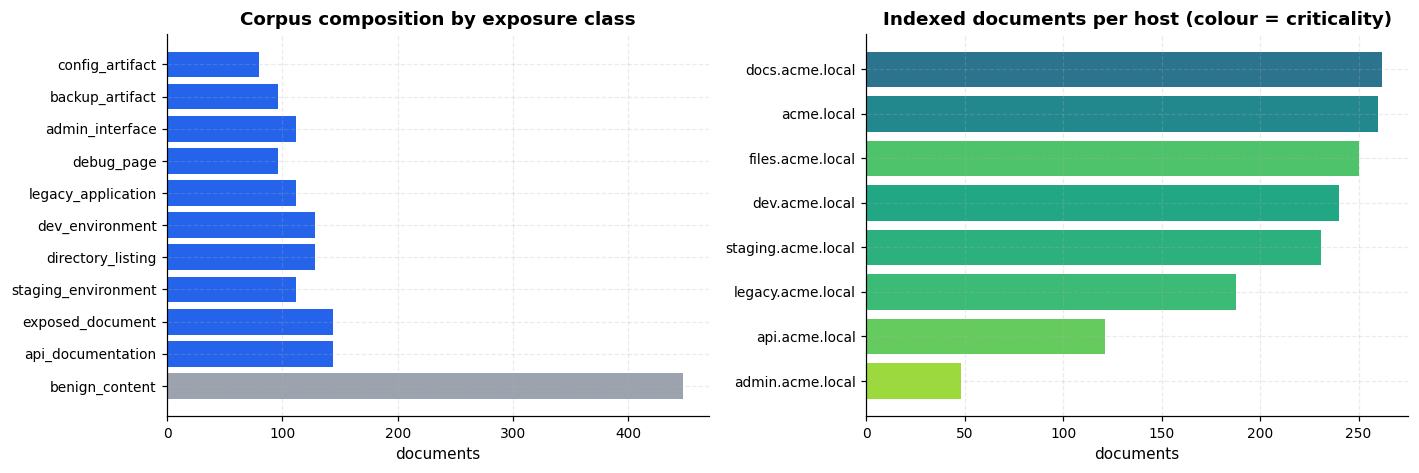

In [9]:
# --- Corpus distribution figure ----------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

counts = corpus_df["exposure_class"].value_counts().reindex(
    sorted(EXPOSURE_CLASSES, key=lambda c: -CLASS_BASE_SEVERITY[c])
)
colors = ["#9ca3af" if c == "benign_content" else ACCENT for c in counts.index]
axes[0].barh(counts.index[::-1], counts.values[::-1], color=colors[::-1])
axes[0].set_title("Corpus composition by exposure class")
axes[0].set_xlabel("documents")

host_counts = corpus_df["host"].value_counts()
crit = [ASSET_BY_HOST[h].criticality for h in host_counts.index]
sc = axes[1].barh(host_counts.index[::-1], host_counts.values[::-1],
                  color=plt.cm.viridis([c * 0.85 for c in crit])[::-1])
axes[1].set_title("Indexed documents per host (colour = criticality)")
axes[1].set_xlabel("documents")

plt.tight_layout()
save_fig(fig, "01_corpus_composition")
plt.show()

## 7. GHDB Query Dataset

The public Google Hacking Database groups thousands of community-contributed dorks into categories such as *Files Containing Juicy Info*, *Sensitive Directories*, and *Pages Containing Login Portals*. Reproducing it verbatim would be neither useful nor safe here, so this notebook ships a **structured catalog of GHDB-style queries** modelled on those families and parameterised for the controlled target.

Each entry is far more than a query string. The metadata is what makes intelligent selection and quantitative evaluation possible:

| Field | Purpose |
|---|---|
| `query_id` | Stable identifier for provenance — every finding records which query produced it |
| `category` | GHDB-style family, used for the effectiveness ranking in Section 22 |
| `query_template` | The dork, with `{domain}` / `{host}` placeholders |
| `description` | Analyst-readable intent |
| `target_type` | Asset kind the dork is designed for (`any`, `dev`, `admin`, ...) — drives technology-aware selection |
| `risk_category` | The risk theme the query hunts for |
| `target_classes` | **Ground-truth classes the query is *supposed* to retrieve** — this is what makes per-query precision/recall computable |
| `required_tech` | Technologies that must be fingerprinted for the query to be relevant |

`target_classes` is the crucial addition. Without it, "did this dork work?" is a judgement call. With it, a retrieved document is a true positive if and only if its ground-truth class is in the query's target set — so precision, recall, and findings-per-query become arithmetic.

### Dork operators supported

The offline engine in Section 10 implements the operator subset that GHDB dorks actually rely on: `site:`, `filetype:`, `ext:`, `inurl:`, `intitle:`, `intext:`, quoted phrases, and `-` negation.

In [10]:
# --- GHDB-style query catalog -------------------------------------------------

@dataclass(frozen=True)
class GHDBQuery:
    """A GHDB-style dork plus the metadata needed for selection and scoring."""
    query_id: str
    category: str
    query_template: str
    description: str
    target_type: str                    # asset kind, or "any"
    risk_category: str
    target_classes: Tuple[str, ...]     # ground-truth classes this dork hunts
    required_tech: Tuple[str, ...] = ()

    def render(self, domain: str, host: Optional[str] = None) -> str:
        return self.query_template.format(domain=domain, host=host or domain)

    @property
    def profile_text(self) -> str:
        """Free text used by the TF-IDF query ranker in Section 11."""
        return (f"{self.category} {self.description} {self.risk_category} "
                f"{self.target_type} {' '.join(self.target_classes)} "
                f"{' '.join(self.required_tech)} {self.query_template}")


def _q(qid, cat, tmpl, desc, ttype, risk, classes, tech=()):
    return GHDBQuery(qid, cat, tmpl, desc, ttype, risk, tuple(classes), tuple(tech))


GHDB_CATALOG: Tuple[GHDBQuery, ...] = (
    # --- Exposed administrative interfaces ---------------------------------
    _q("GHDB-001", "Exposed Administrative Interfaces",
       'site:{domain} inurl:admin intitle:login',
       "Administrative login portals reachable from the public index.",
       "admin", "Unauthorised privileged access", ["admin_interface"]),
    _q("GHDB-002", "Exposed Administrative Interfaces",
       'site:{domain} inurl:administrator',
       "Alternate administrator path naming convention.",
       "admin", "Unauthorised privileged access", ["admin_interface"]),
    _q("GHDB-003", "Exposed Administrative Interfaces",
       'site:{domain} intitle:"control panel"',
       "Vendor control-panel interfaces indexed publicly.",
       "admin", "Unauthorised privileged access", ["admin_interface"]),
    _q("GHDB-004", "Exposed Administrative Interfaces",
       'site:{domain} inurl:admin dashboard',
       "Administrative dashboards leaking operational structure.",
       "admin", "Unauthorised privileged access", ["admin_interface"]),
    _q("GHDB-005", "Exposed Administrative Interfaces",
       'site:{domain} inurl:cp login -blog',
       "Short-form control panel paths, excluding blog false positives.",
       "admin", "Unauthorised privileged access", ["admin_interface"]),

    # --- Directory listings ------------------------------------------------
    _q("GHDB-010", "Directory Listings",
       'site:{domain} intitle:"index of"',
       "Classic autoindex directory listing disclosure.",
       "files", "Information disclosure", ["directory_listing"], ["Apache", "mod_autoindex"]),
    _q("GHDB-011", "Directory Listings",
       'site:{domain} intitle:"index of" parent directory',
       "Autoindex pages confirmed by the parent-directory marker.",
       "files", "Information disclosure", ["directory_listing"], ["Apache", "mod_autoindex"]),
    _q("GHDB-012", "Directory Listings",
       'site:{domain} intext:"last modified" intext:"size" intitle:"index of"',
       "Autoindex column headers as a high-precision signature.",
       "files", "Information disclosure", ["directory_listing"], ["Apache"]),
    _q("GHDB-013", "Directory Listings",
       'site:{domain} inurl:uploads intitle:"index of"',
       "Publicly listed upload directories.",
       "files", "Information disclosure", ["directory_listing"]),

    # --- Backup artefacts --------------------------------------------------
    _q("GHDB-020", "Backup Artefacts",
       'site:{domain} filetype:sql',
       "SQL dumps reachable from the index.",
       "files", "Data exposure", ["backup_artifact"], ["MySQL", "PostgreSQL"]),
    _q("GHDB-021", "Backup Artefacts",
       'site:{domain} inurl:backup',
       "Any path advertising itself as a backup location.",
       "files", "Data exposure", ["backup_artifact"]),
    _q("GHDB-022", "Backup Artefacts",
       'site:{domain} filetype:zip backup',
       "Compressed backup bundles.",
       "files", "Data exposure", ["backup_artifact"]),
    _q("GHDB-023", "Backup Artefacts",
       'site:{domain} intext:"mysqldump"',
       "Content signature of a MySQL dump file.",
       "files", "Data exposure", ["backup_artifact"], ["MySQL"]),
    _q("GHDB-024", "Backup Artefacts",
       'site:{domain} filetype:bak',
       "Editor and deployment backup extensions.",
       "files", "Data exposure", ["backup_artifact"]),
    _q("GHDB-025", "Backup Artefacts",
       'site:{domain} inurl:dumps filetype:sql',
       "Dump directories containing database exports.",
       "files", "Data exposure", ["backup_artifact"], ["MySQL", "PostgreSQL"]),

    # --- Configuration artefacts -------------------------------------------
    _q("GHDB-030", "Configuration Artefacts",
       'site:{domain} inurl:.env',
       "Environment files exposed through the web root.",
       "any", "Credential material exposure", ["config_artifact"],
       ["Django", "Flask", "Node.js", "Express"]),
    _q("GHDB-031", "Configuration Artefacts",
       'site:{domain} filetype:ini config',
       "INI-format application configuration.",
       "any", "Credential material exposure", ["config_artifact"]),
    _q("GHDB-032", "Configuration Artefacts",
       'site:{domain} filetype:yaml config',
       "YAML configuration manifests.",
       "any", "Credential material exposure", ["config_artifact"]),
    _q("GHDB-033", "Configuration Artefacts",
       'site:{domain} intext:"API_KEY" configuration',
       "Configuration content containing key-shaped assignments.",
       "any", "Credential material exposure", ["config_artifact"]),
    _q("GHDB-034", "Configuration Artefacts",
       'site:{domain} inurl:config filetype:json',
       "JSON configuration served from a config path.",
       "any", "Credential material exposure", ["config_artifact"], ["Node.js", "Express"]),
    _q("GHDB-035", "Configuration Artefacts",
       'site:{domain} intext:"DB_PASSWORD"',
       "Database credential assignment pattern in indexed content.",
       "any", "Credential material exposure", ["config_artifact"]),

    # --- Development environments ------------------------------------------
    _q("GHDB-040", "Development Environments",
       'site:{domain} inurl:dev',
       "Developer sandboxes exposed to the index.",
       "dev", "Pre-production exposure", ["dev_environment"], ["Flask", "Werkzeug", "Node.js"]),
    _q("GHDB-041", "Development Environments",
       'site:{domain} inurl:sandbox',
       "Sandbox instances outside change control.",
       "dev", "Pre-production exposure", ["dev_environment"]),
    _q("GHDB-042", "Development Environments",
       'site:{domain} intitle:"development" -careers',
       "Pages self-identifying as development builds.",
       "dev", "Pre-production exposure", ["dev_environment"]),
    _q("GHDB-043", "Development Environments",
       'site:{domain} inurl:test harness',
       "Test harnesses and QA scaffolding.",
       "dev", "Pre-production exposure", ["dev_environment"]),
    _q("GHDB-044", "Development Environments",
       'site:{domain} intext:"not for production use"',
       "Explicit non-production banners.",
       "dev", "Pre-production exposure", ["dev_environment", "staging_environment"]),

    # --- Staging environments ----------------------------------------------
    _q("GHDB-050", "Staging Environments",
       'site:{domain} inurl:staging',
       "Staging mirrors indexed alongside production.",
       "staging", "Pre-production exposure", ["staging_environment"], ["Django", "nginx"]),
    _q("GHDB-051", "Staging Environments",
       'site:{domain} inurl:uat',
       "User acceptance testing environments.",
       "staging", "Pre-production exposure", ["staging_environment"]),
    _q("GHDB-052", "Staging Environments",
       'site:{domain} intitle:"pre-production"',
       "Pre-production banner pages.",
       "staging", "Pre-production exposure", ["staging_environment"]),
    _q("GHDB-053", "Staging Environments",
       'site:{domain} inurl:preprod OR inurl:qa',
       "Alternate pre-production naming conventions.",
       "staging", "Pre-production exposure", ["staging_environment"]),

    # --- Debug pages --------------------------------------------------------
    _q("GHDB-060", "Debugging Pages",
       'site:{domain} intitle:"traceback"',
       "Python traceback pages disclosing code paths.",
       "dev", "Technical information disclosure", ["debug_page"], ["Flask", "Django", "Werkzeug"]),
    _q("GHDB-061", "Debugging Pages",
       'site:{domain} intext:"most recent call last"',
       "Traceback body signature.",
       "dev", "Technical information disclosure", ["debug_page"], ["Python", "Flask", "Django"]),
    _q("GHDB-062", "Debugging Pages",
       'site:{domain} inurl:debug',
       "Debug endpoints left routable.",
       "dev", "Technical information disclosure", ["debug_page"]),
    _q("GHDB-063", "Debugging Pages",
       'site:{domain} intitle:"phpinfo()"',
       "phpinfo output disclosing full server configuration.",
       "legacy", "Technical information disclosure", ["debug_page"], ["PHP"]),
    _q("GHDB-064", "Debugging Pages",
       'site:{domain} intext:"werkzeug" debugger',
       "Werkzeug interactive debugger exposure.",
       "dev", "Technical information disclosure", ["debug_page"], ["Werkzeug", "Flask"]),
    _q("GHDB-065", "Debugging Pages",
       'site:{domain} intitle:"500 internal server error"',
       "Unhandled error pages leaking stack context.",
       "any", "Technical information disclosure", ["debug_page"]),

    # --- API documentation ---------------------------------------------------
    _q("GHDB-070", "API Documentation",
       'site:{domain} inurl:swagger',
       "Swagger UI instances mapping the API surface.",
       "api", "Attack surface enumeration", ["api_documentation"], ["Node.js", "Express"]),
    _q("GHDB-071", "API Documentation",
       'site:{domain} inurl:openapi',
       "OpenAPI specification documents.",
       "api", "Attack surface enumeration", ["api_documentation"]),
    _q("GHDB-072", "API Documentation",
       'site:{domain} inurl:api docs endpoint',
       "API reference pages describing endpoints.",
       "api", "Attack surface enumeration", ["api_documentation"]),
    _q("GHDB-073", "API Documentation",
       'site:{domain} intext:"bearer token" endpoint',
       "Authentication scheme disclosure in API docs.",
       "api", "Attack surface enumeration", ["api_documentation"]),

    # --- Exposed documents ---------------------------------------------------
    _q("GHDB-080", "Exposed Documents",
       'site:{domain} filetype:pdf',
       "Indexed PDF documents.",
       "any", "Information disclosure", ["exposed_document"]),
    _q("GHDB-081", "Exposed Documents",
       'site:{domain} filetype:xlsx',
       "Indexed spreadsheets, frequently containing internal records.",
       "any", "Information disclosure", ["exposed_document"]),
    _q("GHDB-082", "Exposed Documents",
       'site:{domain} filetype:csv',
       "Indexed CSV exports.",
       "any", "Information disclosure", ["exposed_document"]),
    _q("GHDB-083", "Exposed Documents",
       'site:{domain} intext:"internal use only"',
       "Documents carrying internal-use classification markings.",
       "any", "Information disclosure", ["exposed_document"]),
    _q("GHDB-084", "Exposed Documents",
       'site:{domain} intext:"confidential" filetype:pdf',
       "Confidential-marked PDFs.",
       "any", "Information disclosure", ["exposed_document"]),

    # --- Legacy applications --------------------------------------------------
    _q("GHDB-090", "Legacy Applications",
       'site:{domain} inurl:cgi-bin',
       "CGI endpoints indicating a legacy stack.",
       "legacy", "Unsupported software", ["legacy_application"], ["Apache", "PHP"]),
    _q("GHDB-091", "Legacy Applications",
       'site:{domain} intext:"powered by struts"',
       "Struts-based applications with known EOL exposure.",
       "legacy", "Unsupported software", ["legacy_application"], ["Struts"]),
    _q("GHDB-092", "Legacy Applications",
       'site:{domain} inurl:legacy',
       "Explicitly legacy-labelled application paths.",
       "legacy", "Unsupported software", ["legacy_application"]),
    _q("GHDB-093", "Legacy Applications",
       'site:{domain} filetype:jsp',
       "JSP endpoints on unmaintained application servers.",
       "legacy", "Unsupported software", ["legacy_application"], ["JSP", "Struts"]),
    _q("GHDB-094", "Legacy Applications",
       'site:{domain} intext:"deprecated" interface',
       "Interfaces self-declaring deprecation.",
       "legacy", "Unsupported software", ["legacy_application"]),

    # --- Technology discovery --------------------------------------------------
    _q("GHDB-100", "Technology Discovery",
       'site:{domain} intext:"apache server at"',
       "Apache server signature footers.",
       "any", "Fingerprinting", ["directory_listing", "legacy_application"], ["Apache"]),
    _q("GHDB-101", "Technology Discovery",
       'site:{domain} filetype:php',
       "PHP-backed endpoints across the estate.",
       "any", "Fingerprinting", ["legacy_application", "admin_interface"], ["PHP"]),
    _q("GHDB-102", "Technology Discovery",
       'site:{domain} intext:"django" settings',
       "Django-stack indicators.",
       "staging", "Fingerprinting", ["staging_environment", "debug_page"], ["Django"]),
    _q("GHDB-103", "Technology Discovery",
       'site:{domain} intext:"npm run dev"',
       "Node toolchain indicators in indexed content.",
       "dev", "Fingerprinting", ["dev_environment"], ["Node.js"]),

    # --- Off-stack queries --------------------------------------------------
    # Real GHDB catalogs are dominated by dorks for technologies a given target
    # does not run. They are included here deliberately: they are the cost that
    # technology-aware selection is supposed to eliminate, and Experiment 1 vs 2
    # measures whether it actually does.
    _q("GHDB-110", "Exposed Administrative Interfaces",
       'site:{domain} inurl:manager/html',
       "Tomcat manager application exposure.",
       "admin", "Unauthorised privileged access", ["admin_interface"], ["Tomcat"]),
    _q("GHDB-111", "Exposed Administrative Interfaces",
       'site:{domain} inurl:phpmyadmin',
       "phpMyAdmin database console exposure.",
       "admin", "Unauthorised privileged access", ["admin_interface"], ["phpMyAdmin"]),
    _q("GHDB-112", "Exposed Administrative Interfaces",
       'site:{domain} intitle:"jenkins" dashboard',
       "Jenkins CI dashboards reachable without authentication.",
       "dev", "Unauthorised privileged access", ["admin_interface"], ["Jenkins"]),
    _q("GHDB-113", "Exposed Administrative Interfaces",
       'site:{domain} inurl:grafana OR inurl:kibana',
       "Observability consoles exposing internal telemetry.",
       "admin", "Unauthorised privileged access", ["admin_interface"], ["Grafana", "Kibana"]),
    _q("GHDB-114", "Legacy Applications",
       'site:{domain} intext:"coldfusion"',
       "ColdFusion application indicators.",
       "legacy", "Unsupported software", ["legacy_application"], ["ColdFusion"]),
    _q("GHDB-115", "Legacy Applications",
       'site:{domain} inurl:_layouts',
       "SharePoint layout paths.",
       "legacy", "Unsupported software", ["legacy_application"], ["SharePoint"]),
    _q("GHDB-116", "Legacy Applications",
       'site:{domain} intext:"apache tomcat" version',
       "Tomcat version banners.",
       "legacy", "Unsupported software", ["legacy_application"], ["Tomcat"]),
    _q("GHDB-117", "Directory Listings",
       'site:{domain} inurl:sites/default/files',
       "Drupal public file directories.",
       "files", "Information disclosure", ["directory_listing"], ["Drupal"]),
    _q("GHDB-118", "Configuration Artefacts",
       'site:{domain} inurl:web.config',
       "IIS configuration files served as content.",
       "any", "Credential material exposure", ["config_artifact"], ["IIS"]),
    _q("GHDB-119", "Backup Artefacts",
       'site:{domain} intext:"oracle database" export',
       "Oracle export artefacts.",
       "files", "Data exposure", ["backup_artifact"], ["Oracle"]),
    _q("GHDB-120", "Debugging Pages",
       'site:{domain} inurl:iisstart',
       "Default IIS pages indicating unconfigured hosts.",
       "any", "Technical information disclosure", ["debug_page"], ["IIS"]),
    _q("GHDB-121", "API Documentation",
       'site:{domain} intext:"getting started" guide',
       "Broad documentation sweep inherited from a Tomcat-era catalog. "
       "Low precision on non-Tomcat estates.",
       "api", "Attack surface enumeration", ["api_documentation"], ["Tomcat"]),
    _q("GHDB-122", "Exposed Documents",
       'site:{domain} inurl:support',
       "Support-portal document sweep. Off-stack and historically noisy.",
       "any", "Information disclosure", ["exposed_document"], ["SharePoint"]),
    _q("GHDB-123", "Development Environments",
       'site:{domain} intext:"magento" developer',
       "Magento developer-mode indicators.",
       "dev", "Pre-production exposure", ["dev_environment"], ["Magento"]),
)

GHDB_BY_ID: Dict[str, GHDBQuery] = {q.query_id: q for q in GHDB_CATALOG}

ghdb_df = pd.DataFrame([{
    "query_id": q.query_id,
    "category": q.category,
    "query_template": q.query_template,
    "target_type": q.target_type,
    "risk_category": q.risk_category,
    "target_classes": ", ".join(q.target_classes),
    "required_tech": ", ".join(q.required_tech) or "-",
} for q in GHDB_CATALOG])

print(f"GHDB catalog: {len(GHDB_CATALOG)} queries across "
      f"{ghdb_df['category'].nunique()} categories\n")
display(ghdb_df.groupby("category").size().rename("queries").to_frame()
        .sort_values("queries", ascending=False))
display(ghdb_df.head(12))

GHDB catalog: 68 queries across 11 categories



,queries
category,
Exposed Administrative Interfaces,9
Legacy Applications,8
Backup Artefacts,7
Debugging Pages,7
Configuration Artefacts,7
Exposed Documents,6
Development Environments,6
API Documentation,5
Directory Listings,5


,query_id,category,query_template,target_type,risk_category,target_classes,required_tech
0,GHDB-001,Exposed Administrative Interfaces,site:{domain} inurl:admin intitle:login,admin,Unauthorised privileged access,admin_interface,-
1,GHDB-002,Exposed Administrative Interfaces,site:{domain} inurl:administrator,admin,Unauthorised privileged access,admin_interface,-
2,GHDB-003,Exposed Administrative Interfaces,"site:{domain} intitle:""control panel""",admin,Unauthorised privileged access,admin_interface,-
3,GHDB-004,Exposed Administrative Interfaces,site:{domain} inurl:admin dashboard,admin,Unauthorised privileged access,admin_interface,-
4,GHDB-005,Exposed Administrative Interfaces,site:{domain} inurl:cp login -blog,admin,Unauthorised privileged access,admin_interface,-
5,GHDB-010,Directory Listings,"site:{domain} intitle:""index of""",files,Information disclosure,directory_listing,"Apache, mod_autoindex"
6,GHDB-011,Directory Listings,"site:{domain} intitle:""index of"" parent directory",files,Information disclosure,directory_listing,"Apache, mod_autoindex"
7,GHDB-012,Directory Listings,"site:{domain} intext:""last modified"" intext:""s...",files,Information disclosure,directory_listing,Apache
8,GHDB-013,Directory Listings,"site:{domain} inurl:uploads intitle:""index of""",files,Information disclosure,directory_listing,-
9,GHDB-020,Backup Artefacts,site:{domain} filetype:sql,files,Data exposure,backup_artifact,"MySQL, PostgreSQL"


## 8. Asset Discovery

In a real engagement this stage is passive subdomain enumeration: certificate transparency logs, passive DNS, search-engine host extraction, and public source-code references. In this notebook the equivalent operation is **host extraction from the search index** — exactly what the `site:` operator lets an analyst do without ever contacting the target.

`AssetDiscovery` recovers the host inventory from the corpus and enriches each host with:

- **indexed document count** — how much of the host is publicly visible
- **unique path count** — a proxy for structural surface area
- **criticality** — business impact weighting, used later by the risk model
- **auth expectation** — whether the host is supposed to be behind authentication

Note what discovery does *not* do: it does not connect to anything, and it does not assume that a host with few indexed pages is low risk. `admin.acme.local` having a small footprint is not reassurance; a single indexed admin login page is the whole problem.

In [11]:
# --- Asset discovery ----------------------------------------------------------

@dataclass
class DiscoveredAsset:
    """A host recovered from the index, enriched with defender-side context."""
    host: str
    kind: str
    criticality: float
    description: str
    auth_expected: bool
    indexed_documents: int
    unique_paths: int
    file_types: Tuple[str, ...]
    discovery_method: str = "passive-index-host-extraction"


class AssetDiscovery:
    """Recovers the organisation's host inventory from indexed content."""

    def __init__(self, corpus: Sequence[CorpusDocument]) -> None:
        self.corpus = corpus
        self._log = logging.getLogger("ghdb.discovery")

    def discover(self) -> List[DiscoveredAsset]:
        by_host: Dict[str, List[CorpusDocument]] = defaultdict(list)
        for doc in self.corpus:
            by_host[doc.host].append(doc)

        assets: List[DiscoveredAsset] = []
        for host, docs in sorted(by_host.items()):
            meta = ASSET_BY_HOST.get(host)
            if meta is None:  # defensive: an unknown host would itself be a finding
                self._log.warning("Host %s not in asset registry.", host)
                continue
            assets.append(DiscoveredAsset(
                host=host,
                kind=meta.kind,
                criticality=meta.criticality,
                description=meta.description,
                auth_expected=meta.auth_expected,
                indexed_documents=len(docs),
                unique_paths=len({d.path for d in docs}),
                file_types=tuple(sorted({d.file_type for d in docs})),
            ))

        assets.sort(key=lambda a: (-a.criticality, a.host))
        self._log.info("Discovered %d assets from %d indexed documents.",
                       len(assets), len(self.corpus))
        return assets


asset_discovery = AssetDiscovery(CORPUS)
DISCOVERED_ASSETS: List[DiscoveredAsset] = asset_discovery.discover()
ASSET_LOOKUP: Dict[str, DiscoveredAsset] = {a.host: a for a in DISCOVERED_ASSETS}

assets_df = pd.DataFrame([{
    "host": a.host,
    "kind": a.kind,
    "criticality": a.criticality,
    "auth_expected": a.auth_expected,
    "indexed_docs": a.indexed_documents,
    "unique_paths": a.unique_paths,
    "file_types": ", ".join(a.file_types),
} for a in DISCOVERED_ASSETS])

display(assets_df)

16:45:41 | INFO    | ghdb.discovery         | Discovered 8 assets from 1600 indexed documents.


,host,kind,criticality,auth_expected,indexed_docs,unique_paths,file_types
0,admin.acme.local,admin,1.00,True,48,43,"aspx, cgi, html, jsp, php"
1,api.acme.local,api,0.90,True,121,114,"cache, docx, env, html, ini, json, pdf, php, yaml"
2,files.acme.local,files,0.85,True,250,245,"aspx, bak, cache, cgi, csv, docx, env, gz, htm..."
3,legacy.acme.local,legacy,0.80,True,188,173,"aspx, bak, cgi, csv, docx, env, gz, html, ini,..."
4,staging.acme.local,staging,0.75,True,231,226,"aspx, env, html, ini, json, jsp, mailer, pdf, ..."
5,dev.acme.local,dev,0.70,True,240,231,"aspx, auth, bak, cache, env, gz, html, ini, js..."
6,acme.local,corporate,0.55,False,260,236,"aspx, cgi, csv, docx, html, ini, json, jsp, pd..."
7,docs.acme.local,docs,0.45,False,262,249,"csv, docx, html, ini, json, pdf, txt, xlsx, ya..."


## 9. Technology Fingerprinting

Query selection is only "intelligent" if it is grounded in what the target actually runs. Firing Struts dorks at a pure Node estate wastes budget and inflates the false-positive rate.

`TechnologyFingerprinter` derives a per-host technology profile from indexed content using signature matching — the passive equivalent of banner and header analysis. Each detection carries a **confidence** equal to the fraction of the host's indexed documents supporting it, so a single incidental mention of "apache" does not promote Apache to a confirmed stack component.

The output feeds two things:

1. **Technology-aware query selection** (Experiment 2) — only run dorks whose `required_tech` intersects the fingerprinted stack.
2. **The attack-surface graph** — technology nodes become first-class entities linking hosts that share a stack, which is how you reason about blast radius when a framework CVE drops.

In [12]:
# --- Technology fingerprinting ------------------------------------------------

TECH_SIGNATURES: Dict[str, Tuple[str, ...]] = {
    "Apache":        ("apache", "mod_autoindex", "apache server at"),
    "nginx":         ("nginx",),
    "PHP":           ("php", "phpinfo", ".php"),
    "MySQL":         ("mysql", "mysqldump"),
    "PostgreSQL":    ("postgres", "postgresql"),
    "Flask":         ("flask",),
    "Werkzeug":      ("werkzeug",),
    "Django":        ("django",),
    "Node.js":       ("node.js", "npm run", "node"),
    "Express":       ("express",),
    "Struts":        ("struts",),
    "JSP":           (".jsp", "jsp"),
    "WordPress":     ("wordpress", "wp-admin"),
    "MkDocs":        ("mkdocs",),
    "mod_autoindex": ("mod_autoindex", "autoindex"),
    "Python":        ("python", "traceback", "werkzeug"),
}


@dataclass
class TechnologyDetection:
    host: str
    technology: str
    evidence_documents: int
    total_documents: int
    confidence: float
    sample_evidence: str


class TechnologyFingerprinter:
    """Passive technology detection from indexed document content."""

    MIN_CONFIDENCE = 0.02

    def __init__(self, corpus: Sequence[CorpusDocument],
                 signatures: Dict[str, Tuple[str, ...]] = TECH_SIGNATURES) -> None:
        self.corpus = corpus
        self.signatures = signatures
        self._log = logging.getLogger("ghdb.fingerprint")

    def fingerprint(self) -> List[TechnologyDetection]:
        by_host: Dict[str, List[CorpusDocument]] = defaultdict(list)
        for doc in self.corpus:
            by_host[doc.host].append(doc)

        detections: List[TechnologyDetection] = []
        for host, docs in sorted(by_host.items()):
            hits: Dict[str, List[CorpusDocument]] = defaultdict(list)
            for doc in docs:
                blob = doc.searchable_text.lower()
                for tech, patterns in self.signatures.items():
                    if doc.technology == tech or any(p in blob for p in patterns):
                        hits[tech].append(doc)
            for tech, evidence in hits.items():
                conf = len(evidence) / len(docs)
                if conf < self.MIN_CONFIDENCE:
                    continue
                detections.append(TechnologyDetection(
                    host=host,
                    technology=tech,
                    evidence_documents=len(evidence),
                    total_documents=len(docs),
                    confidence=round(conf, 3),
                    sample_evidence=textwrap.shorten(evidence[0].title, 70),
                ))

        detections.sort(key=lambda d: (d.host, -d.confidence))
        self._log.info("Fingerprinted %d host/technology pairs across %d hosts.",
                       len(detections), len(by_host))
        return detections


fingerprinter = TechnologyFingerprinter(CORPUS)
TECH_DETECTIONS: List[TechnologyDetection] = fingerprinter.fingerprint()

# host -> {technology: confidence}
HOST_TECH: Dict[str, Dict[str, float]] = defaultdict(dict)
for det in TECH_DETECTIONS:
    HOST_TECH[det.host][det.technology] = det.confidence

# Estate-wide technology set used for technology-aware query selection.
ESTATE_TECH: Dict[str, float] = {}
for det in TECH_DETECTIONS:
    ESTATE_TECH[det.technology] = max(ESTATE_TECH.get(det.technology, 0.0), det.confidence)

tech_df = pd.DataFrame([asdict(d) for d in TECH_DETECTIONS])

print(f"Technologies identified estate-wide: {len(ESTATE_TECH)}")
print(", ".join(sorted(ESTATE_TECH)) + "\n")
display(tech_df.sort_values("confidence", ascending=False).head(15).reset_index(drop=True))

16:45:41 | INFO    | ghdb.fingerprint       | Fingerprinted 90 host/technology pairs across 8 hosts.


Technologies identified estate-wide: 16
Apache, Django, Express, Flask, JSP, MkDocs, MySQL, Node.js, PHP, PostgreSQL, Python, Struts, Werkzeug, WordPress, mod_autoindex, nginx



,host,technology,evidence_documents,total_documents,confidence,sample_evidence
0,files.acme.local,Apache,120,250,0.480,Index of /files/assets
1,dev.acme.local,Python,110,240,0.458,QA environment checkout
2,dev.acme.local,Werkzeug,101,240,0.421,QA environment checkout
3,admin.acme.local,Apache,19,48,0.396,Management Console Sign In
4,legacy.acme.local,Apache,72,188,0.383,roadmap export (csv)
5,admin.acme.local,Struts,17,48,0.354,Administrator Login
6,admin.acme.local,PHP,17,48,0.354,Management Console Sign In
7,legacy.acme.local,PHP,59,188,0.314,Acme Portal (Classic) - intranet
8,api.acme.local,MkDocs,34,121,0.281,Swagger UI - experiments service
9,docs.acme.local,nginx,73,262,0.279,REST API guide: billing


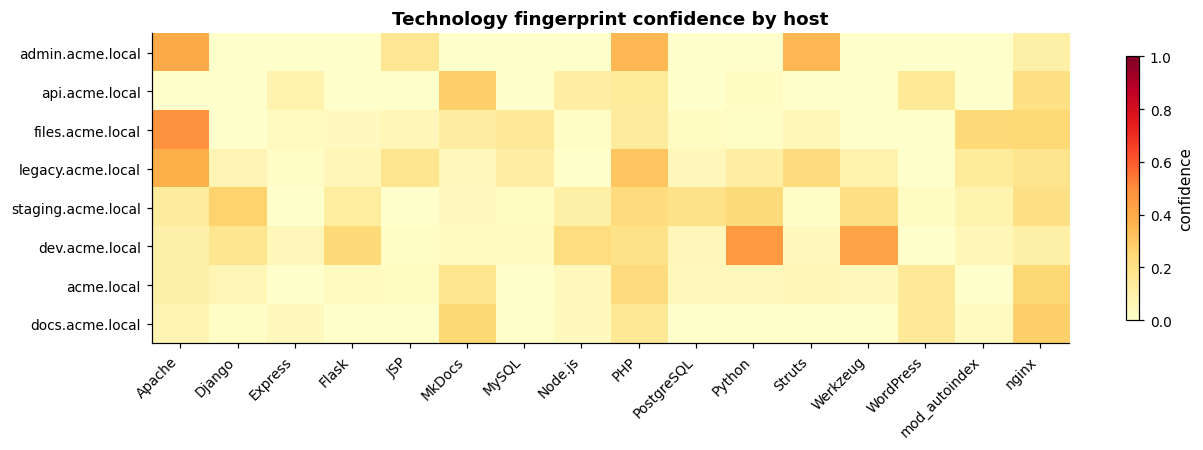

In [13]:
# --- Technology distribution figure -------------------------------------------

pivot = (tech_df.pivot_table(index="host", columns="technology",
                             values="confidence", aggfunc="max")
                .fillna(0.0))
pivot = pivot.loc[sorted(pivot.index, key=lambda h: -ASSET_BY_HOST[h].criticality)]

fig, ax = plt.subplots(figsize=(12, 4.2))
im = ax.imshow(pivot.values, cmap="YlOrRd", aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=45, ha="right")
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_title("Technology fingerprint confidence by host")
ax.grid(False)
fig.colorbar(im, ax=ax, label="confidence", shrink=0.85)
plt.tight_layout()
save_fig(fig, "02_technology_fingerprint")
plt.show()

## 10. Offline Search Engine

This section is the load-bearing element that makes the whole notebook reproducible without API keys.

Rather than calling a commercial search API — which would require credentials, introduce non-determinism, and drag the project toward scanning real infrastructure — the notebook builds a **local inverted index over the controlled corpus** and implements the GHDB operator grammar against it.

### Supported operator grammar

| Operator | Semantics here |
|---|---|
| `site:acme.local` | host equals, or is a subdomain of, the value |
| `filetype:pdf` / `ext:pdf` | resolved file type equals the value |
| `inurl:admin` | substring match against the URL |
| `intitle:login` | substring match against the title |
| `intext:"most recent call last"` | substring match against snippet + body |
| `"quoted phrase"` | phrase match anywhere in the document |
| `-term` | negation; document is excluded if the term matches |
| `A OR B` | either side satisfies the constraint |
| bare term | must appear somewhere in the document (AND across bare terms) |

### Ranking

Documents that satisfy every constraint are scored by term frequency across the URL, title, and body, with title matches weighted more heavily — a deliberately simple, fully transparent BM25-lite. Ties break on `doc_id`, so **result ordering is completely deterministic**. Results are truncated at `RESULTS_PER_QUERY` (default 30), mirroring the realistic behaviour of an analyst harvesting the first couple of result pages rather than paginating exhaustively.

### The backend abstraction

`SearchBackend` is an ABC with a single `search(query) -> List[SearchResult]` method. Two implementations exist:

- **`OfflineSearchBackend`** — the default. Zero network I/O.
- **`AuthorizedLiveSearchBackend`** — a guarded stub. It raises unless the user supplies a provider, a key, and an explicit domain allow-list, and it refuses any query whose `site:` operator falls outside that list. It deliberately implements no rate-limit evasion, no proxying, and no scraping fallback.

Everything downstream depends only on the ABC, so the analytical pipeline is identical in either mode.

In [14]:
# --- Search result model and backend interface --------------------------------

@dataclass
class SearchResult:
    """A single result returned by a search backend."""
    url: str
    title: str
    snippet: str
    domain: str
    file_type: str
    technology: str
    query_id: str
    query_string: str
    rank: int
    score: float
    doc_id: Optional[str] = None   # offline mode only: links back to ground truth


class SearchBackend(ABC):
    """Abstract interface every search backend must satisfy."""

    name: str = "abstract"

    @abstractmethod
    def search(self, query: str, query_id: str = "AD-HOC",
               limit: int = 30) -> List[SearchResult]:
        """Execute a dork and return ranked results."""
        raise NotImplementedError

In [15]:
# --- Offline search backend ---------------------------------------------------

_TOKEN_RE = re.compile(
    r'(?P<neg>-)?'
    r'(?:(?P<op>site|filetype|ext|inurl|intitle|intext|allintext):)?'
    r'(?P<val>"[^"]*"|\S+)',
    re.IGNORECASE,
)

_WORD_RE = re.compile(r"[a-z0-9_]+")


@dataclass(frozen=True)
class _Constraint:
    field: str      # site | filetype | inurl | intitle | intext | any
    value: str
    negate: bool = False


class OfflineSearchBackend(SearchBackend):
    """
    Deterministic search over the controlled corpus.

    Implements the GHDB operator subset described above. Makes no network
    requests of any kind.
    """

    name = "offline"

    def __init__(self, corpus: Sequence[CorpusDocument]) -> None:
        self.corpus = list(corpus)
        self._index: List[Dict[str, Any]] = []
        self._log = logging.getLogger("ghdb.search.offline")
        self._build_index()

    # -- index --------------------------------------------------------------
    def _build_index(self) -> None:
        for doc in self.corpus:
            url_l = doc.url.lower()
            title_l = doc.title.lower()
            text_l = f"{doc.snippet} {doc.body}".lower()
            all_l = f"{url_l} {title_l} {text_l}"
            self._index.append({
                "doc": doc,
                "host": doc.host.lower(),
                "file_type": doc.file_type.lower(),
                "url": url_l,
                "title": title_l,
                "text": text_l,
                "all": all_l,
                "tf": Counter(_WORD_RE.findall(all_l)),
                "title_tf": Counter(_WORD_RE.findall(title_l)),
            })
        self._log.info("Offline index built over %d documents.", len(self._index))

    # -- query parsing -------------------------------------------------------
    @staticmethod
    def _parse(query: str) -> List[Any]:
        """Parse a dork into a list of constraints / OR-groups."""
        raw: List[Any] = []
        for m in _TOKEN_RE.finditer(query):
            val = m.group("val")
            if val is None:
                continue
            if val.upper() == "OR" and not m.group("op"):
                raw.append("OR")
                continue
            phrase = val.startswith('"') and val.endswith('"')
            value = val.strip('"').lower()
            if not value:
                continue
            op = (m.group("op") or "").lower()
            field = {
                "site": "site", "filetype": "filetype", "ext": "filetype",
                "inurl": "inurl", "intitle": "intitle",
                "intext": "intext", "allintext": "intext",
            }.get(op, "any")
            raw.append(_Constraint(field, value, negate=bool(m.group("neg"))))
            if phrase:
                pass  # phrase and bare terms are both substring matches here

        # Fold "A OR B" into OR-groups.
        folded: List[Any] = []
        i = 0
        while i < len(raw):
            if raw[i] == "OR":
                i += 1
                continue
            if i + 1 < len(raw) and raw[i + 1] == "OR" and i + 2 < len(raw):
                group = [raw[i], raw[i + 2]]
                i += 3
                while i + 1 < len(raw) and raw[i] == "OR":
                    group.append(raw[i + 1])
                    i += 2
                folded.append(tuple(group))
            else:
                folded.append(raw[i])
                i += 1
        return folded

    # -- matching ------------------------------------------------------------
    @staticmethod
    def _match_one(entry: Dict[str, Any], c: _Constraint) -> bool:
        if c.field == "site":
            hit = entry["host"] == c.value or entry["host"].endswith("." + c.value)
        elif c.field == "filetype":
            hit = entry["file_type"] == c.value
        elif c.field == "inurl":
            hit = c.value in entry["url"]
        elif c.field == "intitle":
            hit = c.value in entry["title"]
        elif c.field == "intext":
            hit = c.value in entry["text"]
        else:
            hit = c.value in entry["all"]
        return not hit if c.negate else hit

    def _matches(self, entry: Dict[str, Any], constraints: List[Any]) -> bool:
        for item in constraints:
            if isinstance(item, tuple):
                if not any(self._match_one(entry, c) for c in item):
                    return False
            elif not self._match_one(entry, item):
                return False
        return True

    @staticmethod
    def _score(entry: Dict[str, Any], constraints: List[Any]) -> float:
        """Transparent BM25-lite: term frequency with a title boost."""
        score = 0.0
        flat: List[_Constraint] = []
        for item in constraints:
            flat.extend(item if isinstance(item, tuple) else [item])
        for c in flat:
            if c.negate or c.field in ("site", "filetype"):
                continue
            for term in _WORD_RE.findall(c.value):
                score += math.log1p(entry["tf"].get(term, 0))
                score += 1.6 * math.log1p(entry["title_tf"].get(term, 0))
        # Mild preference for shorter URLs (closer to the site root).
        return round(score + 1.0 / (1 + len(entry["url"]) / 100.0), 6)

    # -- public API ----------------------------------------------------------
    def search(self, query: str, query_id: str = "AD-HOC",
               limit: int = 30) -> List[SearchResult]:
        constraints = self._parse(query)
        if not constraints:
            return []

        scored: List[Tuple[float, str, Dict[str, Any]]] = []
        for entry in self._index:
            if self._matches(entry, constraints):
                scored.append((self._score(entry, constraints), entry["doc"].doc_id, entry))

        # Deterministic ordering: score desc, then doc_id asc.
        scored.sort(key=lambda t: (-t[0], t[1]))

        results: List[SearchResult] = []
        for rank, (score, _, entry) in enumerate(scored[:limit], start=1):
            doc: CorpusDocument = entry["doc"]
            results.append(SearchResult(
                url=doc.url, title=doc.title,
                snippet=textwrap.shorten(doc.snippet, 200, placeholder=" ..."),
                domain=doc.host, file_type=doc.file_type,
                technology=doc.technology, query_id=query_id,
                query_string=query, rank=rank, score=score, doc_id=doc.doc_id,
            ))
        return results


offline_backend = OfflineSearchBackend(CORPUS)

# Smoke test of the operator grammar.
for demo_query in ['site:acme.local filetype:pdf',
                   'site:files.acme.local intitle:"index of" parent directory',
                   'site:acme.local inurl:.env']:
    hits = offline_backend.search(demo_query, limit=3)
    print(f"\n> {demo_query}   ->  {len(hits)} shown")
    for r in hits:
        print(f"   [{r.rank}] {r.url}")
        print(f"       {textwrap.shorten(r.title, 78)}")

16:45:43 | INFO    | ghdb.search.offline    | Offline index built over 1600 documents.



> site:acme.local filetype:pdf   ->  3 shown
   [1] http://docs.acme.local/about
       Getting started with workflow
   [2] http://acme.local/team/science
       Getting started with workflow
   [3] http://acme.local/support/science
       Blog: insights in 2022

> site:files.acme.local intitle:"index of" parent directory   ->  3 shown
   [1] http://files.acme.local/pub/invoices/
       Index of /archive/2022
   [2] http://files.acme.local/shared/reports/
       Index of /files/invoices
   [3] http://files.acme.local/backup/site_backup_2025.sql
       Index of /archive/2022

> site:acme.local inurl:.env   ->  3 shown
   [1] http://staging.acme.local/.env
       database.env
   [2] http://legacy.acme.local/openapi.env
       database.env
   [3] http://dev.acme.local/conf/search.env
       .env - environment configuration


In [16]:
# --- Optional authorised live backend (disabled by default) -------------------

class AuthorizedLiveSearchBackend(SearchBackend):
    """
    Guarded interface for an authorised, opt-in live search provider.

    This class intentionally ships **without** a working provider
    implementation. It exists to document the boundary of the architecture and
    to enforce the safety preconditions if a user wires in their own
    provider under their own authorisation.

    Hard requirements before it will run:
      * ``CONFIG['SEARCH_MODE'] == 'authorized_live'``
      * a provider name and API key supplied by the user
      * a non-empty ``LIVE_SEARCH_ALLOWLIST`` of domains the user is
        authorised, in writing, to assess

    Deliberately absent, and not to be added: rate-limit evasion, user-agent
    rotation, proxy pools, CAPTCHA handling, and HTML scraping fallbacks.
    """

    name = "authorized_live"

    def __init__(self, config: Dict[str, Any]) -> None:
        self.config = config
        self.allowlist = [d.lower().strip() for d in config.get("LIVE_SEARCH_ALLOWLIST", [])]
        self.provider = config.get("LIVE_SEARCH_PROVIDER")
        self.api_key = config.get("LIVE_SEARCH_API_KEY")
        self._log = logging.getLogger("ghdb.search.live")
        self._preflight()

    def _preflight(self) -> None:
        if not self.allowlist:
            raise RuntimeError(
                "Live search refused: LIVE_SEARCH_ALLOWLIST is empty. Populate it with "
                "domains you have written authorisation to assess."
            )
        if not self.provider or not self.api_key:
            raise RuntimeError(
                "Live search refused: no provider/API key configured. Supply your own "
                "search-provider credentials; none are bundled with this notebook."
            )
        self._log.warning("Live search armed for %d authorised domain(s): %s",
                          len(self.allowlist), ", ".join(self.allowlist))

    def _authorised(self, query: str) -> bool:
        m = re.search(r"site:([^\s]+)", query, re.IGNORECASE)
        if not m:
            return False  # fail closed: an unscoped dork is never authorised
        domain = m.group(1).lower().strip('"')
        return any(domain == d or domain.endswith("." + d) for d in self.allowlist)

    def search(self, query: str, query_id: str = "AD-HOC",
               limit: int = 30) -> List[SearchResult]:
        if not self._authorised(query):
            raise PermissionError(
                f"Query blocked: '{query}' targets a domain outside the authorisation "
                f"allow-list {self.allowlist}."
            )
        raise NotImplementedError(
            "No live provider is bundled. Implement this method against a search API "
            "you are licensed to use, respecting its terms of service and rate limits, "
            "and only for domains you are authorised to assess."
        )


def make_search_backend(config: Dict[str, Any],
                        corpus: Sequence[CorpusDocument]) -> SearchBackend:
    """Factory honouring CONFIG['SEARCH_MODE']; falls back to offline on failure."""
    mode = config.get("SEARCH_MODE", "offline")
    if mode == "authorized_live":
        try:
            return AuthorizedLiveSearchBackend(config)
        except Exception as exc:
            logger.error("Live backend unavailable (%s). Falling back to offline mode.", exc)
    elif mode != "offline":
        logger.warning("Unknown SEARCH_MODE=%r; defaulting to offline.", mode)
    return OfflineSearchBackend(corpus)


SEARCH_BACKEND: SearchBackend = make_search_backend(CONFIG, CORPUS)
print(f"Active search backend: {SEARCH_BACKEND.name}")
print("No outbound network requests are made in offline mode.")

16:45:43 | INFO    | ghdb.search.offline    | Offline index built over 1600 documents.


Active search backend: offline
No outbound network requests are made in offline mode.


## 11. GHDB Reconnaissance

`GHDBQueryEngine` decides *which* dorks to run. Four selection strategies are implemented, and Section 23 measures them against each other:

| Strategy | Mechanism |
|---|---|
| **`static`** | Baseline. Run the entire catalog, scoped only by `site:`. This is what a naive dork script does. |
| **`tech_aware`** | Rule-based filter. Keep a query if its `required_tech` intersects the fingerprinted estate **and** its `target_type` matches a discovered asset kind. Untargeted (`any`) queries always qualify. |
| **`intelligent`** | Lightweight ML ranking. Build a TF-IDF profile of the *target* (asset kinds, descriptions, fingerprinted technologies, observed file types) and rank every query by cosine similarity between its `profile_text` and that profile. Take the top *K*. No LLM, no API key, fully deterministic. |
| **`llm`** | Optional. Asks a language model to select queries given the same profile. Falls back to `intelligent` when `USE_LLM=False`, which is the default. |

The `intelligent` ranker deserves a note on honesty: cosine similarity over TF-IDF is a modest technique, not a neural reranker. It is included because it is *appropriate to the data volume* — with 54 queries and a single target profile, a heavyweight model would be theatre. What matters is that its selection is measured against the alternatives rather than assumed to be better.

### Execution

`ReconEngine` renders each selected query against the target domain, dispatches it to the active `SearchBackend`, caps results at `RESULTS_PER_QUERY`, and records full provenance — which query produced which result at which rank.

In [17]:
# --- Query selection engine ---------------------------------------------------

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


class GHDBQueryEngine:
    """Selects and ranks GHDB queries for a specific target profile."""

    def __init__(self,
                 catalog: Sequence[GHDBQuery],
                 assets: Sequence[DiscoveredAsset],
                 technologies: Dict[str, float],
                 corpus_file_types: Sequence[str]) -> None:
        self.catalog = list(catalog)
        self.assets = list(assets)
        self.technologies = technologies
        self.file_types = list(corpus_file_types)
        self.asset_kinds = {a.kind for a in assets}
        self._log = logging.getLogger("ghdb.queryengine")

    # -- target profile ------------------------------------------------------
    def target_profile_text(self) -> str:
        parts: List[str] = []
        for a in self.assets:
            parts.append(f"{a.kind} {a.host} {a.description}")
        parts.append(" ".join(sorted(self.technologies)))
        parts.append(" ".join(sorted(set(self.file_types))))
        return " ".join(parts).lower()

    # -- strategies ----------------------------------------------------------
    def select_static(self) -> List[GHDBQuery]:
        """Baseline: everything in the catalog."""
        return list(self.catalog)

    def select_tech_aware(self) -> List[GHDBQuery]:
        """Keep queries whose technology and asset-kind prerequisites hold."""
        selected: List[GHDBQuery] = []
        for q in self.catalog:
            tech_ok = (not q.required_tech) or any(t in self.technologies for t in q.required_tech)
            kind_ok = q.target_type == "any" or q.target_type in self.asset_kinds
            if tech_ok and kind_ok:
                selected.append(q)
        self._log.info("Technology-aware selection: %d/%d queries retained.",
                       len(selected), len(self.catalog))
        return selected

    def rank_intelligent(self, top_k: Optional[int] = None) -> List[Tuple[GHDBQuery, float]]:
        """TF-IDF cosine similarity between each query profile and the target."""
        docs = [q.profile_text.lower() for q in self.catalog] + [self.target_profile_text()]
        vec = TfidfVectorizer(sublinear_tf=True, stop_words="english",
                              token_pattern=r"[a-z0-9_\.]+")
        matrix = vec.fit_transform(docs)
        sims = cosine_similarity(matrix[-1], matrix[:-1]).ravel()
        ranked = sorted(zip(self.catalog, sims), key=lambda t: (-t[1], t[0].query_id))
        if top_k is not None:
            ranked = ranked[:top_k]
        return [(q, float(s)) for q, s in ranked]

    def select_intelligent(self, top_k: Optional[int] = None) -> List[GHDBQuery]:
        k = top_k or int(CONFIG["INTELLIGENT_TOP_K_QUERIES"])
        ranked = self.rank_intelligent(top_k=k)
        self._log.info("Intelligent selection: top %d queries by TF-IDF relevance.", len(ranked))
        return [q for q, _ in ranked]

    def select(self, strategy: str = "tech_aware", top_k: Optional[int] = None) -> List[GHDBQuery]:
        if strategy == "static":
            return self.select_static()
        if strategy == "tech_aware":
            return self.select_tech_aware()
        if strategy == "intelligent":
            return self.select_intelligent(top_k)
        if strategy == "llm":
            return select_queries_with_llm(self, top_k)  # defined in Section 20
        raise ValueError(f"Unknown selection strategy: {strategy!r}")


query_engine = GHDBQueryEngine(
    catalog=GHDB_CATALOG,
    assets=DISCOVERED_ASSETS,
    technologies=ESTATE_TECH,
    corpus_file_types=corpus_df["file_type"].unique().tolist(),
)

_ranked_preview = query_engine.rank_intelligent(top_k=10)
print("Top 10 queries by TF-IDF relevance to the target profile:\n")
for q, s in _ranked_preview:
    print(f"  {s:.3f}  {q.query_id}  [{q.category}]  {q.query_template}")

Top 10 queries by TF-IDF relevance to the target profile:

  0.184  GHDB-093  [Legacy Applications]  site:{domain} filetype:jsp
  0.162  GHDB-050  [Staging Environments]  site:{domain} inurl:staging
  0.161  GHDB-040  [Development Environments]  site:{domain} inurl:dev
  0.153  GHDB-090  [Legacy Applications]  site:{domain} inurl:cgi-bin
  0.143  GHDB-052  [Staging Environments]  site:{domain} intitle:"pre-production"
  0.137  GHDB-072  [API Documentation]  site:{domain} inurl:api docs endpoint
  0.126  GHDB-070  [API Documentation]  site:{domain} inurl:swagger
  0.126  GHDB-030  [Configuration Artefacts]  site:{domain} inurl:.env
  0.117  GHDB-053  [Staging Environments]  site:{domain} inurl:preprod OR inurl:qa
  0.114  GHDB-020  [Backup Artefacts]  site:{domain} filetype:sql


In [18]:
# --- Reconnaissance execution -------------------------------------------------

@dataclass
class ReconRun:
    """Everything produced by one reconnaissance sweep."""
    strategy: str
    queries: List[GHDBQuery]
    results: List[SearchResult]
    per_query_counts: Dict[str, int]
    backend: str

    @property
    def n_queries(self) -> int:
        return len(self.queries)

    @property
    def n_results(self) -> int:
        return len(self.results)


class ReconEngine:
    """Executes a set of GHDB queries against a search backend."""

    def __init__(self, backend: SearchBackend, domain: str,
                 results_per_query: int) -> None:
        self.backend = backend
        self.domain = domain
        self.results_per_query = results_per_query
        self._log = logging.getLogger("ghdb.recon")

    def run(self, queries: Sequence[GHDBQuery], strategy: str = "custom") -> ReconRun:
        results: List[SearchResult] = []
        counts: Dict[str, int] = {}
        for q in queries:
            rendered = q.render(self.domain)
            try:
                hits = self.backend.search(rendered, query_id=q.query_id,
                                           limit=self.results_per_query)
            except (PermissionError, NotImplementedError) as exc:
                self._log.error("Query %s blocked or unsupported: %s", q.query_id, exc)
                hits = []
            except Exception as exc:  # never let one bad dork kill the sweep
                self._log.exception("Query %s failed: %s", q.query_id, exc)
                hits = []
            counts[q.query_id] = len(hits)
            results.extend(hits)

        self._log.info("[%s] %d queries -> %d raw results (backend=%s).",
                       strategy, len(queries), len(results), self.backend.name)
        return ReconRun(strategy=strategy, queries=list(queries), results=results,
                        per_query_counts=counts, backend=self.backend.name)


recon_engine = ReconEngine(SEARCH_BACKEND, CONFIG["ORG_DOMAIN"],
                           int(CONFIG["RESULTS_PER_QUERY"]))

PRIMARY_STRATEGY = "tech_aware"
primary_queries = query_engine.select(PRIMARY_STRATEGY)
recon_run = recon_engine.run(primary_queries, strategy=PRIMARY_STRATEGY)

print(f"\nStrategy        : {recon_run.strategy}")
print(f"Queries executed: {recon_run.n_queries}")
print(f"Raw results     : {recon_run.n_results}")
print(f"Unique URLs     : {len({r.url for r in recon_run.results})}")

_top = sorted(recon_run.per_query_counts.items(), key=lambda kv: -kv[1])[:8]
print("\nHighest-yield queries:")
for qid, n in _top:
    print(f"  {qid}  {n:>3} results   {GHDB_BY_ID[qid].query_template}")

16:45:44 | INFO    | ghdb.queryengine       | Technology-aware selection: 54/68 queries retained.
16:45:44 | INFO    | ghdb.recon             | [tech_aware] 54 queries -> 1223 raw results (backend=offline).



Strategy        : tech_aware
Queries executed: 54
Raw results     : 1223
Unique URLs     : 817

Highest-yield queries:
  GHDB-010   30 results   site:{domain} intitle:"index of"
  GHDB-011   30 results   site:{domain} intitle:"index of" parent directory
  GHDB-012   30 results   site:{domain} intext:"last modified" intext:"size" intitle:"index of"
  GHDB-020   30 results   site:{domain} filetype:sql
  GHDB-021   30 results   site:{domain} inurl:backup
  GHDB-023   30 results   site:{domain} intext:"mysqldump"
  GHDB-030   30 results   site:{domain} inurl:.env
  GHDB-033   30 results   site:{domain} intext:"API_KEY" configuration


## 12. Finding Extraction

Raw search results are not findings. A single exposed backup archive may be retrieved by four different dorks at four different ranks; reporting it four times is how a security report loses its reader.

`FindingExtractor` performs the normalisation that turns a result stream into an analyst-consumable finding set:

1. **Deduplicate** on URL, retaining the highest-ranked observation as canonical.
2. **Attribute provenance** — every finding records the full list of queries that discovered it, plus the primary (first, best-ranked) one. Multi-query corroboration later feeds the confidence score.
3. **Assign an initial exposure type** from the discovering query's `target_classes` — the pre-ML, purely rule-based hypothesis.
4. **Compute an initial confidence** from corroboration count, result rank, and asset context.
5. **Group** related findings by `(asset, exposure_type)` so the report can collapse "37 directory listings on files.acme.local" into one narrative unit with 37 instances.

Each `Finding` also carries `true_class` and `split`. These are **evaluation-only fields**: `true_class` is the ground-truth label used exclusively to compute metrics, and `split` records which ML partition the underlying document belongs to. Neither is ever used as a model input — Section 14 constructs the feature matrix from search-visible fields only.

In [19]:
# --- Finding model and extraction --------------------------------------------

@dataclass
class Finding:
    """A deduplicated, provenance-tracked exposure candidate."""
    finding_id: str
    asset: str
    url: str
    path: str
    title: str
    snippet: str
    file_type: str
    technology: str
    query_category: str
    exposure_type: str                  # rule-based hypothesis from the query
    discovered_by: List[str]            # all query_ids that returned this URL
    primary_query_id: str
    primary_query: str
    best_rank: int
    evidence: str
    confidence: float

    # --- populated later in the pipeline ---
    predicted_class: Optional[str] = None
    predicted_confidence: Optional[float] = None
    risk_score: Optional[float] = None
    severity: Optional[str] = None
    risk_factors: Dict[str, float] = field(default_factory=dict)
    explanation: str = ""
    remediation: str = ""

    # --- evaluation-only (never used as model features) ---
    doc_id: Optional[str] = None
    true_class: Optional[str] = None
    split: Optional[str] = None


class FindingExtractor:
    """Converts raw search results into deduplicated, grouped findings."""

    def __init__(self, corpus_by_id: Dict[str, CorpusDocument],
                 asset_lookup: Dict[str, DiscoveredAsset]) -> None:
        self.corpus_by_id = corpus_by_id
        self.asset_lookup = asset_lookup
        self._log = logging.getLogger("ghdb.findings")

    @staticmethod
    def _initial_confidence(n_queries: int, best_rank: int, criticality: float) -> float:
        """
        Pre-ML confidence that a retrieved URL is a genuine exposure.

        Rises with corroboration across independent dorks, decays with the
        rank at which it was retrieved, and is nudged by asset criticality
        (high-value hosts warrant a lower evidential bar for triage).
        """
        corroboration = 1.0 - math.exp(-0.75 * n_queries)      # 0.53 @1, 0.78 @2, 0.89 @3
        rank_factor = 1.0 / (1.0 + math.log1p(max(best_rank - 1, 0)))
        base = 0.55 * corroboration + 0.35 * rank_factor + 0.10 * criticality
        return round(min(max(base, 0.05), 0.99), 4)

    def extract(self, run: ReconRun) -> List[Finding]:
        by_url: Dict[str, Dict[str, Any]] = {}
        for res in run.results:
            slot = by_url.setdefault(res.url, {"best": res, "queries": []})
            slot["queries"].append(res.query_id)
            if res.rank < slot["best"].rank:
                slot["best"] = res

        findings: List[Finding] = []
        for i, (url, slot) in enumerate(sorted(by_url.items()), start=1):
            best: SearchResult = slot["best"]
            qids = sorted(set(slot["queries"]))
            primary = GHDB_BY_ID[best.query_id]
            asset = self.asset_lookup.get(best.domain)
            criticality = asset.criticality if asset else 0.5
            doc = self.corpus_by_id.get(best.doc_id) if best.doc_id else None

            findings.append(Finding(
                finding_id=f"ACME-{i:04d}",
                asset=best.domain,
                url=url,
                path=url.split(best.domain, 1)[-1] or "/",
                title=best.title,
                snippet=best.snippet,
                file_type=best.file_type,
                technology=best.technology,
                query_category=primary.category,
                exposure_type=primary.target_classes[0],
                discovered_by=qids,
                primary_query_id=primary.query_id,
                primary_query=primary.render(CONFIG["ORG_DOMAIN"]),
                best_rank=best.rank,
                evidence=textwrap.shorten(best.snippet, 180, placeholder=" ..."),
                confidence=self._initial_confidence(len(qids), best.rank, criticality),
                doc_id=best.doc_id,
                true_class=doc.exposure_class if doc else None,
            ))

        self._log.info("Extracted %d unique findings from %d raw results (%.1f%% dedup).",
                       len(findings), len(run.results),
                       100 * (1 - len(findings) / max(len(run.results), 1)))
        return findings

    @staticmethod
    def group(findings: Sequence[Finding]) -> pd.DataFrame:
        rows = defaultdict(lambda: {"instances": 0, "queries": set(), "max_conf": 0.0})
        for f in findings:
            key = (f.asset, f.exposure_type)
            rows[key]["instances"] += 1
            rows[key]["queries"].update(f.discovered_by)
            rows[key]["max_conf"] = max(rows[key]["max_conf"], f.confidence)
        return pd.DataFrame([{
            "asset": a, "exposure_type": e,
            "instances": v["instances"],
            "discovering_queries": len(v["queries"]),
            "max_confidence": round(v["max_conf"], 3),
        } for (a, e), v in rows.items()]).sort_values(
            ["instances"], ascending=False).reset_index(drop=True)


extractor = FindingExtractor(CORPUS_BY_ID, ASSET_LOOKUP)
FINDINGS: List[Finding] = extractor.extract(recon_run)

findings_group_df = FindingExtractor.group(FINDINGS)
print(f"\nUnique findings: {len(FINDINGS)}")
print(f"Assets affected: {len({f.asset for f in FINDINGS})}\n")
display(findings_group_df.head(12))

16:45:44 | INFO    | ghdb.findings          | Extracted 817 unique findings from 1223 raw results (33.2% dedup).



Unique findings: 817
Assets affected: 8



,asset,exposure_type,instances,discovering_queries,max_confidence
0,dev.acme.local,dev_environment,58,9,0.912
1,staging.acme.local,staging_environment,48,5,0.852
2,files.acme.local,backup_artifact,45,9,0.862
3,files.acme.local,exposed_document,44,5,0.725
4,docs.acme.local,exposed_document,39,6,0.685
5,acme.local,exposed_document,30,6,0.832
6,files.acme.local,directory_listing,30,7,0.958
7,legacy.acme.local,legacy_application,30,8,0.857
8,dev.acme.local,config_artifact,27,7,0.912
9,api.acme.local,api_documentation,27,7,0.963


## 13. Ground Truth

This is what separates a measurable experiment from a screenshot gallery.

Because the environment was synthesised here, the *complete* set of exposures is known — not just the ones reconnaissance happened to find. That permits the metric that dork tooling almost never reports honestly: **recall**. Anyone can show you what their scanner found. The interesting question is what it missed.

Two levels of ground truth are maintained:

**Instance level** — `GROUND_TRUTH_INSTANCES` maps every exposure document to its true class. Used for precision, recall, and coverage.

**Category level** — `GROUND_TRUTH_CATEGORIES` is the compact "does this exposure class exist in the environment at all?" map, used for the detection-rate summary.

### Metric definitions used throughout

Let *E* be the set of ground-truth exposure documents, and *R* the set of documents retrieved by a reconnaissance sweep.

- **Precision** = |R ∩ E| / |R| — of what we surfaced, how much was real
- **Recall / detection rate** = |R ∩ E| / |E| — of what exists, how much we surfaced
- **False-negative rate** = 1 − recall
- **False-positive rate** = |R \ E| / |R| — benign content promoted to a finding
- **Coverage** = fraction of exposure *classes* with at least one true positive retrieved

A note on interpretation: precision here is measured against *ground-truth exposure status*, not against the specific class a dork was aiming for. A backup dork that surfaces a config file is still surfacing a real exposure. Per-query class-level precision is reported separately in Section 22.

In [20]:
# --- Ground truth construction ------------------------------------------------

# Instance-level: every exposure document in the environment.
GROUND_TRUTH_INSTANCES: Dict[str, str] = {
    d.doc_id: d.exposure_class for d in CORPUS if d.is_exposure
}
ALL_EXPOSURE_DOC_IDS: set = set(GROUND_TRUTH_INSTANCES)
BENIGN_DOC_IDS: set = {d.doc_id for d in CORPUS if not d.is_exposure}

# Category-level: which exposure classes exist in the environment at all.
GROUND_TRUTH_CATEGORIES: Dict[str, bool] = {
    cls: any(d.exposure_class == cls for d in CORPUS)
    for cls in EXPOSURE_CLASSES if cls != "benign_content"
}

# Per-class instance counts, for recall-by-class reporting.
GROUND_TRUTH_COUNTS: Dict[str, int] = dict(
    Counter(GROUND_TRUTH_INSTANCES.values())
)


@dataclass
class DetectionMetrics:
    retrieved: int
    true_positives: int
    false_positives: int
    false_negatives: int
    precision: float
    recall: float
    f1: float
    false_positive_rate: float
    false_negative_rate: float
    coverage: float


class EvaluationEngine:
    """Scores a reconnaissance sweep against instance-level ground truth."""

    def __init__(self, exposure_ids: set, all_classes: Dict[str, int]) -> None:
        self.exposure_ids = exposure_ids
        self.class_counts = all_classes
        self._log = logging.getLogger("ghdb.eval")

    def score(self, retrieved_doc_ids: Iterable[str]) -> DetectionMetrics:
        retrieved = {d for d in retrieved_doc_ids if d}
        tp = len(retrieved & self.exposure_ids)
        fp = len(retrieved - self.exposure_ids)
        fn = len(self.exposure_ids - retrieved)
        precision = tp / len(retrieved) if retrieved else 0.0
        recall = tp / len(self.exposure_ids) if self.exposure_ids else 0.0
        f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) else 0.0

        found_classes = {GROUND_TRUTH_INSTANCES[d] for d in (retrieved & self.exposure_ids)}
        coverage = len(found_classes) / len(self.class_counts) if self.class_counts else 0.0

        return DetectionMetrics(
            retrieved=len(retrieved), true_positives=tp, false_positives=fp,
            false_negatives=fn, precision=round(precision, 4), recall=round(recall, 4),
            f1=round(f1, 4),
            false_positive_rate=round(fp / len(retrieved), 4) if retrieved else 0.0,
            false_negative_rate=round(1 - recall, 4), coverage=round(coverage, 4),
        )

    def recall_by_class(self, retrieved_doc_ids: Iterable[str]) -> pd.DataFrame:
        retrieved = {d for d in retrieved_doc_ids if d}
        rows = []
        for cls, total in sorted(self.class_counts.items(),
                                 key=lambda kv: -CLASS_BASE_SEVERITY[kv[0]]):
            cls_ids = {d for d, c in GROUND_TRUTH_INSTANCES.items() if c == cls}
            found = len(cls_ids & retrieved)
            rows.append({
                "exposure_class": cls,
                "base_severity": CLASS_BASE_SEVERITY[cls],
                "ground_truth": total,
                "detected": found,
                "missed": total - found,
                "recall": round(found / total, 4) if total else 0.0,
            })
        return pd.DataFrame(rows)


evaluator = EvaluationEngine(ALL_EXPOSURE_DOC_IDS, GROUND_TRUTH_COUNTS)

retrieved_ids = {f.doc_id for f in FINDINGS}
primary_metrics = evaluator.score(retrieved_ids)

print("Ground truth")
print(f"  Exposure documents : {len(ALL_EXPOSURE_DOC_IDS)}")
print(f"  Benign documents   : {len(BENIGN_DOC_IDS)}")
print(f"  Exposure classes   : {len(GROUND_TRUTH_CATEGORIES)}\n")

print(f"Reconnaissance sweep ({recon_run.strategy})")
for k, v in asdict(primary_metrics).items():
    print(f"  {k:<22}: {v}")

print()
display(evaluator.recall_by_class(retrieved_ids))

Ground truth
  Exposure documents : 1152
  Benign documents   : 448
  Exposure classes   : 10

Reconnaissance sweep (tech_aware)
  retrieved             : 817
  true_positives        : 754
  false_positives       : 63
  false_negatives       : 398
  precision             : 0.9229
  recall                : 0.6545
  f1                    : 0.7659
  false_positive_rate   : 0.0771
  false_negative_rate   : 0.3455
  coverage              : 1.0



,exposure_class,base_severity,ground_truth,detected,missed,recall
0,config_artifact,9.5,80,72,8,0.9000
1,backup_artifact,9.0,96,78,18,0.8125
2,admin_interface,8.5,112,57,55,0.5089
3,debug_page,7.5,96,72,24,0.7500
4,legacy_application,7.0,112,72,40,0.6429
5,dev_environment,6.5,128,95,33,0.7422
6,directory_listing,6.0,128,76,52,0.5938
7,staging_environment,6.0,112,75,37,0.6696
8,exposed_document,5.5,144,80,64,0.5556
9,api_documentation,4.5,144,77,67,0.5347


## 14. ML Dataset Construction

### 14.1 What is being classified, and why

The learning task is: **given only what a search engine exposes about a document, predict its exposure class.**

That constraint is the point. A defender running dork sweeps at scale sees URLs, titles, and snippets — nothing more. They cannot fetch every result to inspect it (that would be active reconnaissance and would not scale). So the model is trained on exactly the fields a `SearchResult` carries. Ground-truth fields such as `sensitivity`, `auth_required`, and `discoverability` exist in the environment but are **deliberately excluded from the feature matrix**; they are environment metadata, not search-visible signal, and using them would be leakage dressed up as feature engineering.

### 14.2 Population

The dataset is the **full corpus** (all 1,600 documents), not just the subset reconnaissance happened to retrieve. Two reasons:

1. Training only on retrieved documents would bake the retrieval strategy's biases into the classifier — the model would never see the exposure types the dorks miss, which are precisely the ones we most want it to recognise.
2. It keeps the class distribution intact for stratified splitting.

The split is performed at the **document** level *before* any vectoriser is fitted. Findings are then tagged with the split their underlying document belongs to, so Section 18 can report pipeline-level classification metrics restricted to held-out documents only.

### 14.3 Feature blocks

Features are organised into four named blocks so the ablation study in Section 24 can add and remove them cleanly.

| Block | Contents |
|---|---|
| **`url`** | TF-IDF over URL tokens (host labels, path segments, extension) |
| **`title`** | TF-IDF over the result title, with bigrams |
| **`snippet`** | TF-IDF over the snippet text, with bigrams |
| **`meta`** | One-hot `file_type` and `technology`, plus engineered numeric features |

The engineered numeric features cover the signals a human analyst actually eyeballs: presence of `backup` / `config` / `admin` / `debug` / `dev` / `staging` / `test` / `index of` / `traceback` / `internal` / `swagger` / `legacy` / `.env` tokens, path depth, URL length, digit density, and whether the path carries a file extension.

In [21]:
# --- Feature construction -----------------------------------------------------

from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, MaxAbsScaler

# Lexical signals a human analyst scans for. Each becomes a binary feature.
KEYWORD_FLAGS: Dict[str, Tuple[str, ...]] = {
    "kw_backup":    ("backup", "dump", "mysqldump", ".sql", ".bak", "snapshot", "archive"),
    "kw_config":    ("config", ".env", "settings", "api_key", "password", "secret", ".ini", ".yaml"),
    "kw_admin":     ("admin", "administrator", "control panel", "console", "login", "/cp/"),
    "kw_debug":     ("debug", "traceback", "phpinfo", "stack", "werkzeug", "500 internal"),
    "kw_dev":       ("/dev", "sandbox", "development", "npm run", "feature branch"),
    "kw_staging":   ("staging", "preprod", "uat", "pre-production", "release candidate"),
    "kw_test":      ("test", "/qa/", "harness", "fixture"),
    "kw_listing":   ("index of", "parent directory", "autoindex", "last modified"),
    "kw_internal":  ("internal use only", "confidential", "do not distribute", "restricted"),
    "kw_api":       ("swagger", "openapi", "endpoint", "bearer token", "api reference"),
    "kw_legacy":    ("legacy", "deprecated", "cgi-bin", "struts", ".jsp", "classic"),
    "kw_doc":       (".pdf", ".xlsx", ".csv", ".docx", "report", "export"),
}

NUMERIC_FEATURES: List[str] = list(KEYWORD_FLAGS) + [
    "path_depth", "url_length", "digit_ratio", "has_extension", "n_query_terms",
]

_URL_SPLIT_RE = re.compile(r"[^a-z0-9]+")


def tokenize_url(url: str) -> str:
    """Explode a URL into whitespace-separated tokens (host labels + path segments)."""
    stripped = re.sub(r"^https?://", "", url.lower())
    return " ".join(t for t in _URL_SPLIT_RE.split(stripped) if t)


def build_record(url: str, title: str, snippet: str, file_type: str,
                 technology: str, doc_id: Optional[str] = None,
                 label: Optional[str] = None) -> Dict[str, Any]:
    """
    Build a feature record from search-visible fields only.

    Deliberately does NOT accept sensitivity / auth / discoverability: those are
    environment ground truth, not signals a search result exposes.
    """
    path = re.sub(r"^https?://[^/]+", "", url.lower()) or "/"
    blob = f"{url} {title} {snippet}".lower()

    rec: Dict[str, Any] = {
        "doc_id": doc_id,
        "url_text": tokenize_url(url),
        "title_text": title.lower(),
        "snippet_text": snippet.lower(),
        "file_type": (file_type or "unknown").lower(),
        "technology": (technology or "unknown").lower(),
        "path_depth": path.count("/"),
        "url_length": min(len(url) / 100.0, 3.0),
        "digit_ratio": sum(c.isdigit() for c in path) / max(len(path), 1),
        "has_extension": 1.0 if re.search(r"\.[a-z0-9]{2,5}$", path) else 0.0,
        "n_query_terms": len(blob.split()) / 50.0,
    }
    for flag, patterns in KEYWORD_FLAGS.items():
        rec[flag] = 1.0 if any(p in blob for p in patterns) else 0.0
    if label is not None:
        rec["label"] = label
    return rec


ml_df = pd.DataFrame([
    build_record(d.url, d.title, d.snippet, d.file_type, d.technology,
                 doc_id=d.doc_id, label=d.exposure_class)
    for d in CORPUS
])

print(f"ML dataset: {ml_df.shape[0]} rows x {ml_df.shape[1]} columns")
print(f"Text blocks   : url_text, title_text, snippet_text")
print(f"Categorical   : file_type, technology")
print(f"Numeric       : {len(NUMERIC_FEATURES)} engineered features\n")
display(ml_df["label"].value_counts().rename("documents").to_frame())

ML dataset: 1600 rows x 24 columns
Text blocks   : url_text, title_text, snippet_text
Categorical   : file_type, technology
Numeric       : 17 engineered features



,documents
label,
benign_content,448
exposed_document,144
api_documentation,144
directory_listing,128
dev_environment,128
staging_environment,112
admin_interface,112
legacy_application,112
backup_artifact,96


In [22]:
# --- Feature-block assembly (also used by the ablation study in Section 24) ----

FEATURE_BLOCKS: Tuple[str, ...] = ("url", "title", "snippet", "meta")


def build_preprocessor(blocks: Sequence[str]) -> ColumnTransformer:
    """
    Assemble a ColumnTransformer from a subset of feature blocks.

    Every transformer is unfitted; fitting happens inside a Pipeline on the
    training split only, which is what keeps vectorisation leakage-free.
    """
    transformers: List[Tuple[str, Any, Any]] = []

    if "url" in blocks:
        transformers.append(("url", TfidfVectorizer(
            sublinear_tf=True, min_df=2, ngram_range=(1, 1),
            token_pattern=r"[a-z0-9]+"), "url_text"))

    if "title" in blocks:
        transformers.append(("title", TfidfVectorizer(
            sublinear_tf=True, min_df=2, ngram_range=(1, 2),
            token_pattern=r"[a-z0-9_\.]+"), "title_text"))

    if "snippet" in blocks:
        transformers.append(("snippet", TfidfVectorizer(
            sublinear_tf=True, min_df=2, ngram_range=(1, 2), max_features=20000,
            token_pattern=r"[a-z0-9_\.]+"), "snippet_text"))

    if "meta" in blocks:
        transformers.append(("cat", OneHotEncoder(handle_unknown="ignore"),
                             ["file_type", "technology"]))
        transformers.append(("num", MaxAbsScaler(), NUMERIC_FEATURES))

    if not transformers:
        raise ValueError("At least one feature block is required.")

    return ColumnTransformer(transformers, remainder="drop", sparse_threshold=1.0)


def build_pipeline(estimator, blocks: Sequence[str] = FEATURE_BLOCKS) -> Pipeline:
    """A leakage-safe pipeline: preprocessing is fit inside cross-validation."""
    return Pipeline([("features", build_preprocessor(blocks)),
                     ("clf", estimator)])


print("Feature blocks available:", ", ".join(FEATURE_BLOCKS))
_demo = build_preprocessor(FEATURE_BLOCKS)
print("Full preprocessor stages:", [name for name, _, _ in _demo.transformers])

Feature blocks available: url, title, snippet, meta
Full preprocessor stages: ['url', 'title', 'snippet', 'cat', 'num']


## 15. Train / Validation / Test Split

A 70 / 15 / 15 stratified split over the 1,600 documents, seeded at 42.

### Why three splits and not two

The notebook makes a **model-selection decision** — logistic regression versus linear SVM, and which feature blocks to keep. If that decision were made by looking at test performance, the reported test metrics would be optimistically biased: the test set would have leaked into the modelling process through the analyst's choices.

So the roles are strictly separated:

- **Train (70%, ~1,120 docs)** — vectorisers and model coefficients are fit here, and nowhere else.
- **Validation (15%, ~240 docs)** — used to choose between candidate estimators and to inspect the ablation. Consulted freely.
- **Test (15%, ~240 docs)** — **touched exactly once**, in Section 18, after all decisions are locked. Every headline number in the report comes from here.

### Stratification

Stratified on `exposure_class`. The rarest class (`config_artifact`, 5% of the corpus) still contributes ~12 documents to each held-out split — thin, and the confidence interval on its per-class F1 is correspondingly wide. That limitation is stated in Section 29 rather than hidden.

### Leakage controls

- The split is on documents, before any fitting.
- `TfidfVectorizer` vocabularies and IDF weights are learned inside the `Pipeline`, so cross-validation refits them per fold rather than reusing a globally-fit vocabulary.
- No ground-truth environment metadata is in the feature matrix.
- Findings inherit their document's split tag, so pipeline-level metrics can be restricted to held-out data.

In [23]:
# --- Stratified 70/15/15 split ------------------------------------------------

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

X_all = ml_df.drop(columns=["label"])
y_all = ml_df["label"].values

test_frac = float(CONFIG["TEST_FRAC"])
val_frac = float(CONFIG["VAL_FRAC"])

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_all, y_all, test_size=test_frac, stratify=y_all, random_state=SEED)

# val_frac is expressed relative to the whole dataset, so rescale for the second split.
rel_val = val_frac / (1.0 - test_frac)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=rel_val, stratify=y_trainval, random_state=SEED)

SPLIT_BY_DOC: Dict[str, str] = {}
for frame, name in ((X_train, "train"), (X_val, "val"), (X_test, "test")):
    for did in frame["doc_id"]:
        SPLIT_BY_DOC[did] = name

# Propagate split membership onto findings for held-out pipeline evaluation.
for f in FINDINGS:
    f.split = SPLIT_BY_DOC.get(f.doc_id)

split_df = pd.DataFrame({
    "train": pd.Series(y_train).value_counts(),
    "val": pd.Series(y_val).value_counts(),
    "test": pd.Series(y_test).value_counts(),
}).fillna(0).astype(int)
split_df["total"] = split_df.sum(axis=1)
split_df = split_df.sort_values("total", ascending=False)

print(f"train {len(y_train):>5}  ({100*len(y_train)/len(y_all):.1f}%)")
print(f"val   {len(y_val):>5}  ({100*len(y_val)/len(y_all):.1f}%)")
print(f"test  {len(y_test):>5}  ({100*len(y_test)/len(y_all):.1f}%)")
print(f"\nRarest class in test: {split_df['test'].min()} documents\n")
display(split_df)

_f_splits = Counter(f.split for f in FINDINGS)
print("\nFindings by split:", dict(_f_splits))

train  1119  (69.9%)
val     241  (15.1%)
test    240  (15.0%)

Rarest class in test: 12 documents



,train,val,test,total
benign_content,314,67,67,448
exposed_document,100,22,22,144
api_documentation,100,22,22,144
directory_listing,90,19,19,128
dev_environment,90,19,19,128
legacy_application,78,17,17,112
admin_interface,78,17,17,112
staging_environment,78,17,17,112
backup_artifact,68,14,14,96
debug_page,67,15,14,96



Findings by split: {'train': 583, 'val': 117, 'test': 117}


## 16. Rule-Based Baseline

Before claiming a machine-learning model earns its place, there has to be something honest to compare it against. The baseline here is not a strawman — it is a careful, ordered keyword classifier of exactly the kind a competent engineer would write in an afternoon, and of the kind that most published dork-triage tooling actually uses.

`RuleBasedClassifier` walks an ordered rule list; the first rule whose pattern matches the URL, title, or snippet wins. Order encodes priority: config and backup signatures are evaluated before the broader development and staging patterns, because a `.env` inside `/dev/` is a config exposure first and a dev exposure second.

Confidence is derived from how many of a rule's patterns fired, giving the baseline a usable score for the ROC comparison rather than bare hard labels.

The baseline is evaluated on the **same held-out test split** as the ML model. Anything else would be a rigged comparison.

In [24]:
# --- Rule-based baseline classifier -------------------------------------------

class RuleBasedClassifier:
    """
    Ordered keyword classifier over search-visible fields.

    Deliberately a strong baseline: first-match-wins with a priority ordering
    that reflects how an analyst triages. Exposed as a scikit-learn-like
    ``predict`` / ``predict_proba`` interface for a fair comparison.
    """

    RULES: Tuple[Tuple[str, Tuple[str, ...]], ...] = (
        ("config_artifact",     (".env", "api_key", "db_password", "secret_token",
                                 "configuration file", "config.", "settings/", "/conf/")),
        ("backup_artifact",     ("backup", "mysqldump", ".sql", ".bak", "dump",
                                 "snapshot", "tarball", ".zip")),
        ("directory_listing",   ("index of", "parent directory", "autoindex",
                                 "last modified size")),
        ("debug_page",          ("traceback", "most recent call last", "phpinfo",
                                 "werkzeug", "debug", "500 internal server error",
                                 "stack trace")),
        ("admin_interface",     ("admin", "administrator", "control panel",
                                 "management console", "/cp/", "control panel")),
        ("legacy_application",  ("legacy", "deprecated", "cgi-bin", "struts",
                                 ".jsp", "classic", "powered by php 5")),
        ("staging_environment", ("staging", "uat", "preprod", "pre-production",
                                 "release candidate", "/qa/")),
        ("dev_environment",     ("/dev", "sandbox", "development", "npm run",
                                 "feature branch", "test harness", "ci preview")),
        ("api_documentation",   ("swagger", "openapi", "api reference",
                                 "bearer token", "endpoint documentation", "/api/docs")),
        ("exposed_document",    ("internal use only", "confidential", ".pdf",
                                 ".xlsx", ".csv", ".docx", "report", "export")),
    )

    DEFAULT_CLASS = "benign_content"

    def __init__(self) -> None:
        self.classes_: List[str] = [c for c, _ in self.RULES] + [self.DEFAULT_CLASS]
        self._log = logging.getLogger("ghdb.baseline")

    @staticmethod
    def _blob(row: pd.Series) -> str:
        return f"{row['url_text']} {row['title_text']} {row['snippet_text']}"

    def _classify_one(self, blob: str) -> Tuple[str, float]:
        for label, patterns in self.RULES:
            hits = sum(1 for p in patterns if p in blob)
            if hits:
                # Confidence saturates with the number of corroborating patterns.
                return label, round(min(0.45 + 0.18 * hits, 0.97), 4)
        return self.DEFAULT_CLASS, 0.40

    def fit(self, X=None, y=None) -> "RuleBasedClassifier":
        return self  # nothing to learn; present for interface symmetry

    def predict(self, X: pd.DataFrame) -> np.ndarray:
        return np.array([self._classify_one(self._blob(r)) [0]
                         for _, r in X.iterrows()])

    def predict_with_confidence(self, X: pd.DataFrame) -> Tuple[np.ndarray, np.ndarray]:
        out = [self._classify_one(self._blob(r)) for _, r in X.iterrows()]
        return np.array([o[0] for o in out]), np.array([o[1] for o in out])

    def predict_proba(self, X: pd.DataFrame, classes: Sequence[str]) -> np.ndarray:
        """Pseudo-probabilities: confidence on the predicted class, remainder spread."""
        labels, confs = self.predict_with_confidence(X)
        idx = {c: i for i, c in enumerate(classes)}
        proba = np.zeros((len(labels), len(classes)))
        for i, (lab, conf) in enumerate(zip(labels, confs)):
            proba[i, :] = (1.0 - conf) / (len(classes) - 1)
            proba[i, idx[lab]] = conf
        return proba


baseline_clf = RuleBasedClassifier()

from sklearn.metrics import f1_score, accuracy_score

_bl_val_pred = baseline_clf.predict(X_val)
print("Rule-based baseline on VALIDATION split")
print(f"  accuracy : {accuracy_score(y_val, _bl_val_pred):.4f}")
print(f"  macro F1 : {f1_score(y_val, _bl_val_pred, average='macro', zero_division=0):.4f}")

Rule-based baseline on VALIDATION split
  accuracy : 0.6805
  macro F1 : 0.6592


## 17. ML Classifier

### Model choice

Two linear candidates are trained on the training split and compared on **validation** macro-F1:

- **TF-IDF + Logistic Regression** (multinomial, L2, `class_weight='balanced'`)
- **TF-IDF + Linear SVM** (`LinearSVC`, `class_weight='balanced'`), wrapped in `CalibratedClassifierCV` so it emits usable probabilities

Linear models over TF-IDF are the right tool here, and not out of laziness. The signal in this problem is genuinely lexical — the presence of `mysqldump`, `parent directory`, or `most recent call last` is close to a sufficient statistic. A gradient-boosted or transformer model would add parameters, training time, and opacity without a plausible route to more signal, and on a 1,600-document corpus it would mostly learn to overfit the generator's templates. Linear models also give **inspectable coefficients**, which matters when a security analyst has to justify why a page was flagged.

`class_weight='balanced'` matters because the classes are unbalanced by design (28% benign, 5% config artefacts), and the rare classes are the high-severity ones. An unweighted model would happily sacrifice `config_artifact` recall for overall accuracy — exactly backwards for a security tool.

### Cross-validation

5-fold stratified cross-validation on the training split reports the stability of the macro-F1 estimate. The whole `Pipeline` is passed to `cross_val_score`, so **each fold refits its own vectoriser vocabulary** — a globally-fit vectoriser would leak test-fold vocabulary and IDF statistics into training.

In [25]:
# --- Candidate models and validation-based selection --------------------------

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

CANDIDATES: Dict[str, Any] = {
    "TF-IDF + Logistic Regression": LogisticRegression(
        max_iter=2000, C=4.0, class_weight="balanced", random_state=SEED),
    "TF-IDF + Linear SVM": CalibratedClassifierCV(
        LinearSVC(C=0.6, class_weight="balanced", random_state=SEED, max_iter=5000),
        cv=3, method="sigmoid"),
}

candidate_scores: Dict[str, Dict[str, float]] = {}
fitted_candidates: Dict[str, Pipeline] = {}

for name, estimator in CANDIDATES.items():
    pipe = build_pipeline(estimator, FEATURE_BLOCKS)
    pipe.fit(X_train, y_train)
    val_pred = pipe.predict(X_val)
    candidate_scores[name] = {
        "val_accuracy": round(accuracy_score(y_val, val_pred), 4),
        "val_macro_f1": round(f1_score(y_val, val_pred, average="macro", zero_division=0), 4),
        "val_weighted_f1": round(f1_score(y_val, val_pred, average="weighted", zero_division=0), 4),
    }
    fitted_candidates[name] = pipe
    logger.info("%s -> val macro-F1 %.4f", name, candidate_scores[name]["val_macro_f1"])

# Rule baseline scored on the same validation split, for context.
candidate_scores["Rule-Based Baseline"] = {
    "val_accuracy": round(accuracy_score(y_val, _bl_val_pred), 4),
    "val_macro_f1": round(f1_score(y_val, _bl_val_pred, average="macro", zero_division=0), 4),
    "val_weighted_f1": round(f1_score(y_val, _bl_val_pred, average="weighted", zero_division=0), 4),
}

selection_df = pd.DataFrame(candidate_scores).T.sort_values("val_macro_f1", ascending=False)
display(selection_df)

BEST_MODEL_NAME = max(fitted_candidates, key=lambda n: candidate_scores[n]["val_macro_f1"])
best_pipeline: Pipeline = fitted_candidates[BEST_MODEL_NAME]
print(f"\nSelected on validation macro-F1: {BEST_MODEL_NAME}")

16:45:47 | INFO    | ghdb.platform          | TF-IDF + Logistic Regression -> val macro-F1 0.9036
16:45:48 | INFO    | ghdb.platform          | TF-IDF + Linear SVM -> val macro-F1 0.8973


,val_accuracy,val_macro_f1,val_weighted_f1
TF-IDF + Logistic Regression,0.9004,0.9036,0.9007
TF-IDF + Linear SVM,0.9004,0.8973,0.9003
Rule-Based Baseline,0.6805,0.6592,0.6736



Selected on validation macro-F1: TF-IDF + Logistic Regression


In [26]:
# --- Cross-validation on the training split -----------------------------------

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_pipeline = build_pipeline(CANDIDATES[BEST_MODEL_NAME], FEATURE_BLOCKS)

cv_scores = cross_val_score(cv_pipeline, X_train, y_train,
                            cv=cv, scoring="f1_macro", n_jobs=1)

print(f"5-fold CV macro-F1 on TRAIN ({BEST_MODEL_NAME})")
print(f"  folds : {', '.join(f'{s:.4f}' for s in cv_scores)}")
print(f"  mean  : {cv_scores.mean():.4f}  (+/- {cv_scores.std():.4f})")

CV_MEAN_F1 = float(cv_scores.mean())
CV_STD_F1 = float(cv_scores.std())

5-fold CV macro-F1 on TRAIN (TF-IDF + Logistic Regression)
  folds : 0.8739, 0.8681, 0.9041, 0.8918, 0.8370
  mean  : 0.8750  (+/- 0.0229)


In [27]:
# --- Refit the selected model on train+validation, then freeze ----------------
# Standard practice: once selection is complete, the model is refit on all data
# the analyst was allowed to look at. The test split remains untouched.

FINAL_MODEL: Pipeline = build_pipeline(CANDIDATES[BEST_MODEL_NAME], FEATURE_BLOCKS)
FINAL_MODEL.fit(X_trainval, y_trainval)
MODEL_CLASSES: List[str] = list(FINAL_MODEL.named_steps["clf"].classes_)

import joblib
_model_path = PATHS["models"] / "finding_classifier.joblib"
joblib.dump(FINAL_MODEL, _model_path)

_n_features = FINAL_MODEL.named_steps["features"].transform(X_train.head(5)).shape[1]
print(f"Final model : {BEST_MODEL_NAME}")
print(f"Fit on      : {len(X_trainval)} documents (train + validation)")
print(f"Feature dim : {_n_features}")
print(f"Classes     : {len(MODEL_CLASSES)}")
print(f"Persisted   : {_model_path}")

Final model : TF-IDF + Logistic Regression
Fit on      : 1360 documents (train + validation)
Feature dim : 2251
Classes     : 11
Persisted   : /content/ghdb_project/models/finding_classifier.joblib


## 18. Evaluation

The test split is opened here, once. Everything below is computed at execution time.

Reported:

- **Accuracy** — headline, but weak on unbalanced data
- **Macro precision / recall / F1** — the honest metric, weighting `config_artifact` equally with `benign_content`
- **Weighted F1** — accuracy-like but class-aware
- **Per-class classification report**
- **Confusion matrix** — where the errors actually live
- **ROC-AUC and PR-AUC** for the derived *high-severity detection* view

### The binary high-severity view

Multi-class accuracy is not the number an operator cares about. What they care about is: *does this tool reliably separate the exposures that need paging someone at 2am from everything else?*

So a binary view is derived from the same model without training anything new: score = the predicted probability mass over the high-severity classes (`config_artifact`, `backup_artifact`, `admin_interface`, `debug_page`), label = whether the true class is in that set. ROC-AUC and PR-AUC are computed on that. This is mathematically appropriate because the score is a genuine ranking over a well-defined binary label, and PR-AUC is the more informative of the two given the positive class is a minority.

In [28]:
# --- Held-out test evaluation -------------------------------------------------

from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_recall_fscore_support,
                             roc_auc_score, average_precision_score,
                             roc_curve, precision_recall_curve)

HIGH_SEVERITY_CLASSES = ("config_artifact", "backup_artifact",
                         "admin_interface", "debug_page")

y_pred_ml = FINAL_MODEL.predict(X_test)
proba_ml = FINAL_MODEL.predict_proba(X_test)
y_pred_rule, conf_rule = baseline_clf.predict_with_confidence(X_test)


def summarise(y_true, y_pred, name: str) -> Dict[str, Any]:
    p_ma, r_ma, f_ma, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0)
    p_w, r_w, f_w, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0)
    return {
        "model": name,
        "accuracy": round(accuracy_score(y_true, y_pred), 4),
        "precision_macro": round(p_ma, 4),
        "recall_macro": round(r_ma, 4),
        "f1_macro": round(f_ma, 4),
        "precision_weighted": round(p_w, 4),
        "recall_weighted": round(r_w, 4),
        "f1_weighted": round(f_w, 4),
    }


TEST_RESULTS = pd.DataFrame([
    summarise(y_test, y_pred_rule, "Rule-Based Baseline"),
    summarise(y_test, y_pred_ml, BEST_MODEL_NAME),
])

print("=" * 78)
print("HELD-OUT TEST SET RESULTS  (n = %d)" % len(y_test))
print("=" * 78)
display(TEST_RESULTS)

_delta = (TEST_RESULTS.loc[1, "f1_macro"] - TEST_RESULTS.loc[0, "f1_macro"])
print(f"\nMacro-F1 delta (ML - rules): {_delta:+.4f} "
      f"({100 * _delta / max(TEST_RESULTS.loc[0, 'f1_macro'], 1e-9):+.1f}% relative)")

print("\nPer-class report for the selected model:\n")
print(classification_report(y_test, y_pred_ml, zero_division=0, digits=3))

HELD-OUT TEST SET RESULTS  (n = 240)


,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,Rule-Based Baseline,0.7000,0.7102,0.7626,0.7109,0.7585,0.7000,0.6993
1,TF-IDF + Logistic Regression,0.8875,0.8764,0.9050,0.8863,0.8965,0.8875,0.8876



Macro-F1 delta (ML - rules): +0.1754 (+24.7% relative)

Per-class report for the selected model:

                     precision    recall  f1-score   support

    admin_interface      0.810     1.000     0.895        17
  api_documentation      0.769     0.909     0.833        22
    backup_artifact      0.875     1.000     0.933        14
     benign_content      0.966     0.836     0.896        67
    config_artifact      0.786     0.917     0.846        12
         debug_page      0.867     0.929     0.897        14
    dev_environment      0.941     0.842     0.889        19
  directory_listing      0.944     0.895     0.919        19
   exposed_document      0.905     0.864     0.884        22
 legacy_application      0.929     0.765     0.839        17
staging_environment      0.850     1.000     0.919        17

           accuracy                          0.887       240
          macro avg      0.876     0.905     0.886       240
       weighted avg      0.896     0.887     

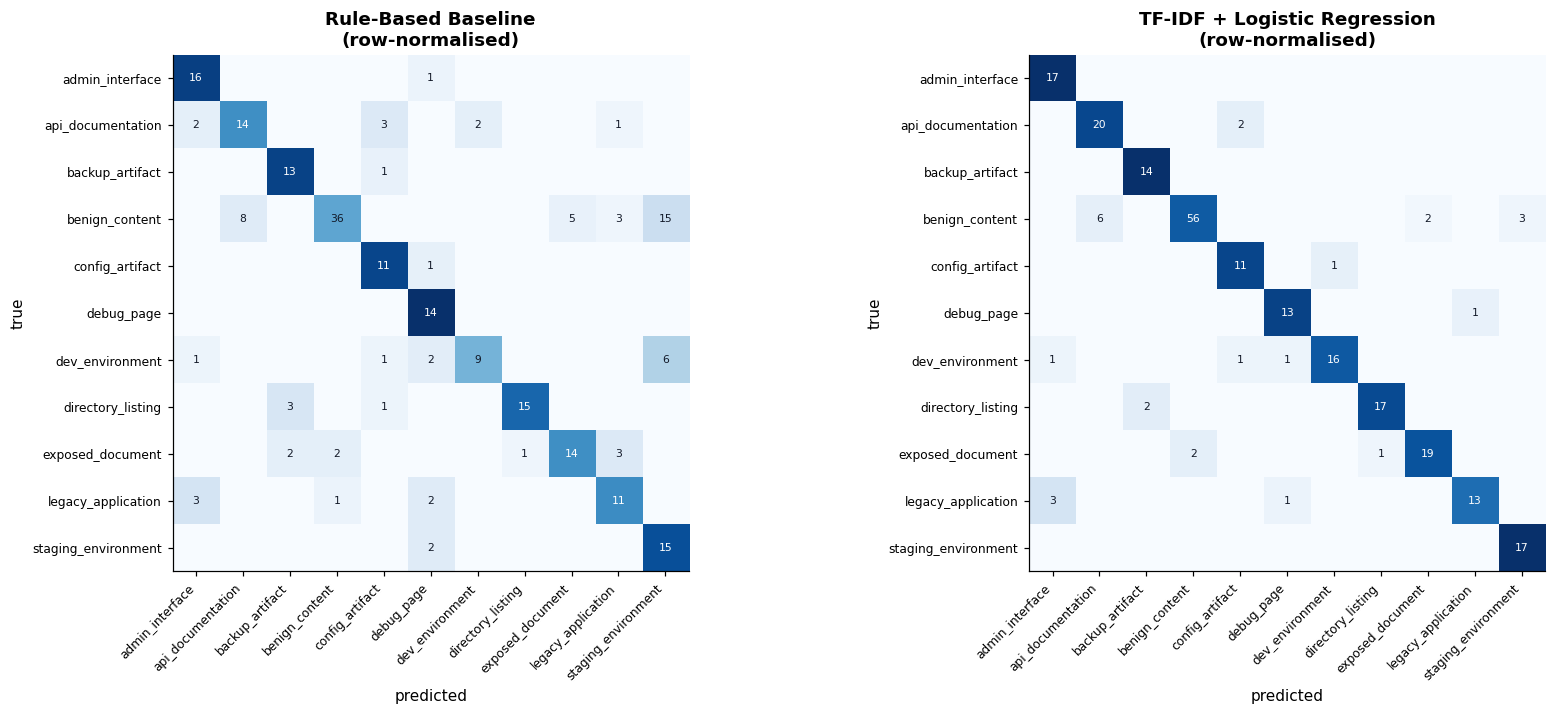

In [29]:
# --- Confusion matrices -------------------------------------------------------

_labels = sorted(set(y_test))

fig, axes = plt.subplots(1, 2, figsize=(16, 6.6))
for ax, (preds, title) in zip(axes, [(y_pred_rule, "Rule-Based Baseline"),
                                     (y_pred_ml, BEST_MODEL_NAME)]):
    cm = confusion_matrix(y_test, preds, labels=_labels)
    cm_norm = cm / np.clip(cm.sum(axis=1, keepdims=True), 1, None)
    im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(_labels)))
    ax.set_xticklabels(_labels, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(_labels)))
    ax.set_yticklabels(_labels, fontsize=8)
    ax.set_xlabel("predicted")
    ax.set_ylabel("true")
    ax.set_title(f"{title}\n(row-normalised)")
    ax.grid(False)
    for i in range(len(_labels)):
        for j in range(len(_labels)):
            if cm[i, j]:
                ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=7,
                        color="white" if cm_norm[i, j] > 0.55 else "#111827")

plt.tight_layout()
save_fig(fig, "03_confusion_matrices")
plt.show()

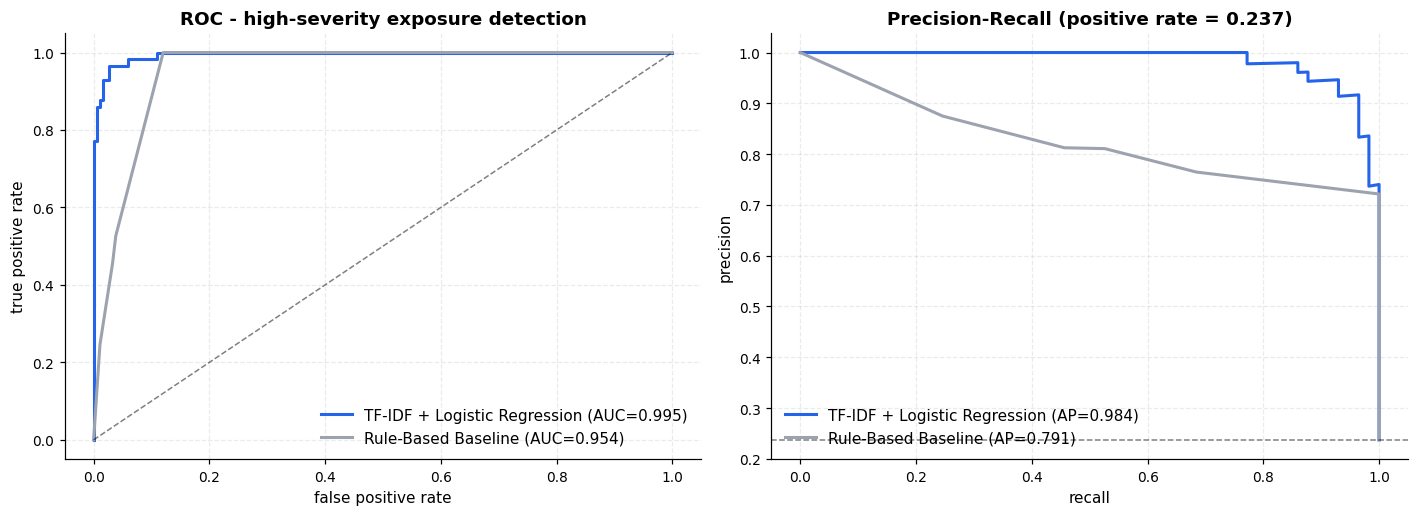

ROC-AUC  ML: 0.9945 | rules: 0.9540
PR-AUC   ML: 0.9842 | rules: 0.7915


In [30]:
# --- Binary high-severity detection: ROC and PR -------------------------------

hs_index = [MODEL_CLASSES.index(c) for c in HIGH_SEVERITY_CLASSES if c in MODEL_CLASSES]
y_test_binary = np.array([1 if c in HIGH_SEVERITY_CLASSES else 0 for c in y_test])

score_ml = proba_ml[:, hs_index].sum(axis=1)
proba_rule = baseline_clf.predict_proba(X_test, MODEL_CLASSES)
score_rule = proba_rule[:, hs_index].sum(axis=1)

ROC_AUC = {
    BEST_MODEL_NAME: roc_auc_score(y_test_binary, score_ml),
    "Rule-Based Baseline": roc_auc_score(y_test_binary, score_rule),
}
PR_AUC = {
    BEST_MODEL_NAME: average_precision_score(y_test_binary, score_ml),
    "Rule-Based Baseline": average_precision_score(y_test_binary, score_rule),
}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for name, score, colour in ((BEST_MODEL_NAME, score_ml, ACCENT),
                            ("Rule-Based Baseline", score_rule, "#9ca3af")):
    fpr, tpr, _ = roc_curve(y_test_binary, score)
    axes[0].plot(fpr, tpr, color=colour, lw=2,
                 label=f"{name} (AUC={ROC_AUC[name]:.3f})")
    prec, rec, _ = precision_recall_curve(y_test_binary, score)
    axes[1].plot(rec, prec, color=colour, lw=2,
                 label=f"{name} (AP={PR_AUC[name]:.3f})")

axes[0].plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
axes[0].set_xlabel("false positive rate"); axes[0].set_ylabel("true positive rate")
axes[0].set_title("ROC - high-severity exposure detection"); axes[0].legend(loc="lower right")

_baseline_rate = y_test_binary.mean()
axes[1].axhline(_baseline_rate, ls="--", c="k", lw=1, alpha=0.5)
axes[1].set_xlabel("recall"); axes[1].set_ylabel("precision")
axes[1].set_title(f"Precision-Recall (positive rate = {_baseline_rate:.3f})")
axes[1].legend(loc="lower left")

plt.tight_layout()
save_fig(fig, "04_roc_pr_curves")
plt.show()

print(f"ROC-AUC  ML: {ROC_AUC[BEST_MODEL_NAME]:.4f} | rules: {ROC_AUC['Rule-Based Baseline']:.4f}")
print(f"PR-AUC   ML: {PR_AUC[BEST_MODEL_NAME]:.4f} | rules: {PR_AUC['Rule-Based Baseline']:.4f}")

In [31]:
# --- Which classes are hard, and why ------------------------------------------

_p, _r, _f, _s = precision_recall_fscore_support(
    y_test, y_pred_ml, labels=_labels, zero_division=0)
per_class_df = pd.DataFrame({
    "class": _labels, "precision": _p.round(3), "recall": _r.round(3),
    "f1": _f.round(3), "support": _s,
}).sort_values("f1")

# Most frequent confusion pairs on the test split.
cm_full = confusion_matrix(y_test, y_pred_ml, labels=_labels)
pairs = [(_labels[i], _labels[j], int(cm_full[i, j]))
         for i in range(len(_labels)) for j in range(len(_labels))
         if i != j and cm_full[i, j] > 0]
pairs.sort(key=lambda t: -t[2])

print("Hardest classes (lowest F1):\n")
display(per_class_df.head(5).reset_index(drop=True))

print("\nMost frequent confusions (true -> predicted):")
for true_c, pred_c, n in pairs[:8]:
    print(f"  {n:>3}x  {true_c:<22} -> {pred_c}")

HARDEST_CLASSES = per_class_df.head(3)["class"].tolist()
TOP_CONFUSIONS = pairs[:8]

Hardest classes (lowest F1):



,class,precision,recall,f1,support
0,api_documentation,0.769,0.909,0.833,22
1,legacy_application,0.929,0.765,0.839,17
2,config_artifact,0.786,0.917,0.846,12
3,exposed_document,0.905,0.864,0.884,22
4,dev_environment,0.941,0.842,0.889,19



Most frequent confusions (true -> predicted):
    6x  benign_content         -> api_documentation
    3x  benign_content         -> staging_environment
    3x  legacy_application     -> admin_interface
    2x  api_documentation      -> config_artifact
    2x  benign_content         -> exposed_document
    2x  directory_listing      -> backup_artifact
    2x  exposed_document       -> benign_content
    1x  config_artifact        -> dev_environment


## 19. Finding Severity Model

### 19.1 The design principle

The single most common failure in exposure tooling is collapsing severity onto one axis — usually "does it contain something that looks like a secret?" That produces two symmetric errors: a `.env` full of placeholder values on a decommissioned host gets paged out as Critical, while a directory listing on the primary file server that indexes the entire build tree gets filed as Informational.

Severity is not a property of the artefact. It is a property of the artefact **in context**.

### 19.2 The model

Seven independent factors, each normalised to (0, 1]:

| Factor | Weight | Source |
|---|---|---|
| **Exposure severity** | 0.28 | Base severity of the classified exposure type (÷10) |
| **Asset criticality** | 0.22 | Business impact of the host |
| **Detection confidence** | 0.16 | Corroboration across queries, retrieval rank, model probability |
| **Information sensitivity** | 0.13 | How damaging the disclosed content is |
| **Exploitability** | 0.11 | How directly the exposure enables a next step |
| **Public discoverability** | 0.06 | How easily an untargeted adversary stumbles onto it |
| **Authentication status** | 0.04 | Penalty applied when the resource sits behind auth |

Combined as a **weighted geometric mean**, then scaled to 0–100:

```
risk = 100 × Π (factor_i ^ weight_i)      where Σ weight_i = 1
```

### 19.3 Why geometric, not arithmetic

A weighted *sum* lets a single large factor mask a near-zero one: a benign public marketing page on a maximally critical host would still accumulate a middling score. A weighted *product* is closer to how risk actually behaves — if any necessary condition collapses, the risk collapses with it. A `config_artifact` behind working authentication is genuinely much less urgent than the same file served anonymously, and the geometric mean expresses that without needing a special case.

It also keeps the output well-distributed across the band range rather than clustering everything in the middle, which is what makes the bands actionable.

### 19.4 Bands

| Score | Band |
|---|---|
| 0–24 | Informational |
| 25–49 | Low |
| 50–74 | Medium |
| 75–89 | High |
| 90–100 | Critical |

Every factor value is retained on the finding, so any score can be decomposed and argued with. Opaque risk scores do not survive contact with a remediation team.

### 19.5 Sensitivity and exploitability at inference time

In this controlled environment, per-document sensitivity and exploitability are known. In a real deployment they are not directly observable from a search result, so the scorer falls back to **class-level priors** whenever the ground-truth value is unavailable — and that fallback path is the one exercised for any finding the environment did not generate. The class priors are computed from the training split only.

In [32]:
# --- Risk scoring -------------------------------------------------------------

RISK_WEIGHTS: Dict[str, float] = {
    "exposure_severity": 0.28,
    "asset_criticality": 0.22,
    "confidence": 0.16,
    "sensitivity": 0.13,
    "exploitability": 0.11,
    "discoverability": 0.06,
    "authentication": 0.04,
}
assert abs(sum(RISK_WEIGHTS.values()) - 1.0) < 1e-9, "Risk weights must sum to 1."

SEVERITY_BANDS: Tuple[Tuple[float, float, str], ...] = (
    (0, 25, "Informational"),
    (25, 50, "Low"),
    (50, 75, "Medium"),
    (75, 90, "High"),
    (90, 101, "Critical"),
)

# Class-level priors for factors not observable from a search result.
# Computed from the TRAINING split only, so no test information leaks in.
_train_ids = set(X_train["doc_id"])
_prior_rows = [(d.exposure_class, d.sensitivity, d.exploitability, d.discoverability)
               for d in CORPUS if d.doc_id in _train_ids]
_prior_df = pd.DataFrame(_prior_rows, columns=["cls", "sens", "expl", "disc"])
CLASS_PRIORS: Dict[str, Dict[str, float]] = {
    cls: {"sensitivity": float(g["sens"].mean()),
          "exploitability": float(g["expl"].mean()),
          "discoverability": float(g["disc"].mean())}
    for cls, g in _prior_df.groupby("cls")
}


@dataclass
class RiskAssessment:
    score: float
    band: str
    factors: Dict[str, float]


class RiskScorer:
    """Transparent, decomposable multi-factor risk model (0-100)."""

    FLOOR = 0.02  # keeps the geometric mean finite when a factor is ~0

    def __init__(self, weights: Dict[str, float] = RISK_WEIGHTS,
                 class_priors: Dict[str, Dict[str, float]] = CLASS_PRIORS,
                 asset_lookup: Dict[str, DiscoveredAsset] = None) -> None:
        self.weights = weights
        self.priors = class_priors
        self.assets = asset_lookup or ASSET_LOOKUP
        self._log = logging.getLogger("ghdb.risk")

    @staticmethod
    def band_for(score: float) -> str:
        for lo, hi, name in SEVERITY_BANDS:
            if lo <= score < hi:
                return name
        return "Critical"

    def _factors(self, finding: Finding) -> Dict[str, float]:
        cls = finding.predicted_class or finding.exposure_type
        prior = self.priors.get(cls, {"sensitivity": 0.5, "exploitability": 0.5,
                                      "discoverability": 0.6})
        doc = CORPUS_BY_ID.get(finding.doc_id) if finding.doc_id else None

        asset = self.assets.get(finding.asset)
        criticality = asset.criticality if asset else 0.5

        confidence = finding.predicted_confidence or finding.confidence

        return {
            "exposure_severity": CLASS_BASE_SEVERITY.get(cls, 3.0) / 10.0,
            "asset_criticality": criticality,
            "confidence": confidence,
            "sensitivity": doc.sensitivity if doc else prior["sensitivity"],
            "exploitability": doc.exploitability if doc else prior["exploitability"],
            "discoverability": doc.discoverability if doc else prior["discoverability"],
            # Authentication in front of the resource reduces, but does not
            # eliminate, urgency: the path itself is still disclosed.
            "authentication": 0.45 if (doc and doc.auth_required) else 1.0,
        }

    def score(self, finding: Finding) -> RiskAssessment:
        factors = self._factors(finding)
        log_sum = sum(self.weights[k] * math.log(max(v, self.FLOOR))
                      for k, v in factors.items())
        raw = math.exp(log_sum)
        score = round(min(max(100.0 * raw, 0.0), 100.0), 2)
        return RiskAssessment(score=score, band=self.band_for(score),
                              factors={k: round(v, 4) for k, v in factors.items()})

    def apply(self, findings: Sequence[Finding]) -> None:
        for f in findings:
            assessment = self.score(f)
            f.risk_score = assessment.score
            f.severity = assessment.band
            f.risk_factors = assessment.factors
        self._log.info("Scored %d findings.", len(findings))


# Attach ML predictions to findings before scoring, so severity reflects the
# classifier's view rather than the discovering query's assumption.
_finding_records = pd.DataFrame([
    build_record(f.url, f.title, f.snippet, f.file_type, f.technology, doc_id=f.doc_id)
    for f in FINDINGS
])
_pred_classes = FINAL_MODEL.predict(_finding_records)
_pred_proba = FINAL_MODEL.predict_proba(_finding_records)

for f, cls, proba in zip(FINDINGS, _pred_classes, _pred_proba):
    f.predicted_class = cls
    model_conf = float(proba.max())
    # Blend retrieval-derived confidence with model confidence.
    f.predicted_confidence = round(0.45 * f.confidence + 0.55 * model_conf, 4)

risk_scorer = RiskScorer()
risk_scorer.apply(FINDINGS)

findings_df = pd.DataFrame([{
    "finding_id": f.finding_id, "asset": f.asset, "url": f.url,
    "exposure_type": f.exposure_type, "predicted_class": f.predicted_class,
    "true_class": f.true_class, "split": f.split,
    "file_type": f.file_type, "technology": f.technology,
    "query_category": f.query_category, "primary_query_id": f.primary_query_id,
    "primary_query": f.primary_query, "n_discovering_queries": len(f.discovered_by),
    "confidence": f.predicted_confidence, "risk_score": f.risk_score,
    "severity": f.severity, "evidence": f.evidence,
} for f in FINDINGS])

sev_counts = findings_df["severity"].value_counts().reindex(SEVERITY_ORDER).fillna(0).astype(int)
print("Findings by severity band:\n")
for band in SEVERITY_ORDER:
    print(f"  {band:<14} {sev_counts[band]:>4}")
print(f"\nMean risk score : {findings_df['risk_score'].mean():.2f}")
print(f"Max risk score  : {findings_df['risk_score'].max():.2f}")

16:46:05 | INFO    | ghdb.risk              | Scored 817 findings.


Findings by severity band:

  Informational    58
  Low              11
  Medium          508
  High            237
  Critical          3

Mean risk score : 67.73
Max risk score  : 92.32


In [33]:
# --- Worked example: decomposing a single risk score --------------------------

_top_finding = max(FINDINGS, key=lambda f: f.risk_score or 0)
print(f"Highest-risk finding: {_top_finding.finding_id}")
print(f"  URL             : {_top_finding.url}")
print(f"  Predicted class : {_top_finding.predicted_class}")
print(f"  Severity        : {_top_finding.severity}  (score {_top_finding.risk_score})")
print(f"  Discovered by   : {', '.join(_top_finding.discovered_by)}")
print("\n  Factor decomposition:")
print(f"  {'factor':<22}{'value':>8}{'weight':>9}{'contribution':>14}")
for k, v in _top_finding.risk_factors.items():
    w = RISK_WEIGHTS[k]
    print(f"  {k:<22}{v:>8.3f}{w:>9.2f}{v ** w:>14.4f}")
print(f"\n  Product x 100 = {_top_finding.risk_score}")

Highest-risk finding: ACME-0142
  URL             : http://api.acme.local/settings/search_config.ini
  Predicted class : config_artifact
  Severity        : Critical  (score 92.32)
  Discovered by   : GHDB-031, GHDB-033

  Factor decomposition:
  factor                   value   weight  contribution
  exposure_severity        0.950     0.28        0.9857
  asset_criticality        0.900     0.22        0.9771
  confidence               0.847     0.16        0.9737
  sensitivity              0.968     0.13        0.9958
  exploitability           0.975     0.11        0.9972
  discoverability          0.865     0.06        0.9913
  authentication           1.000     0.04        1.0000

  Product x 100 = 92.32


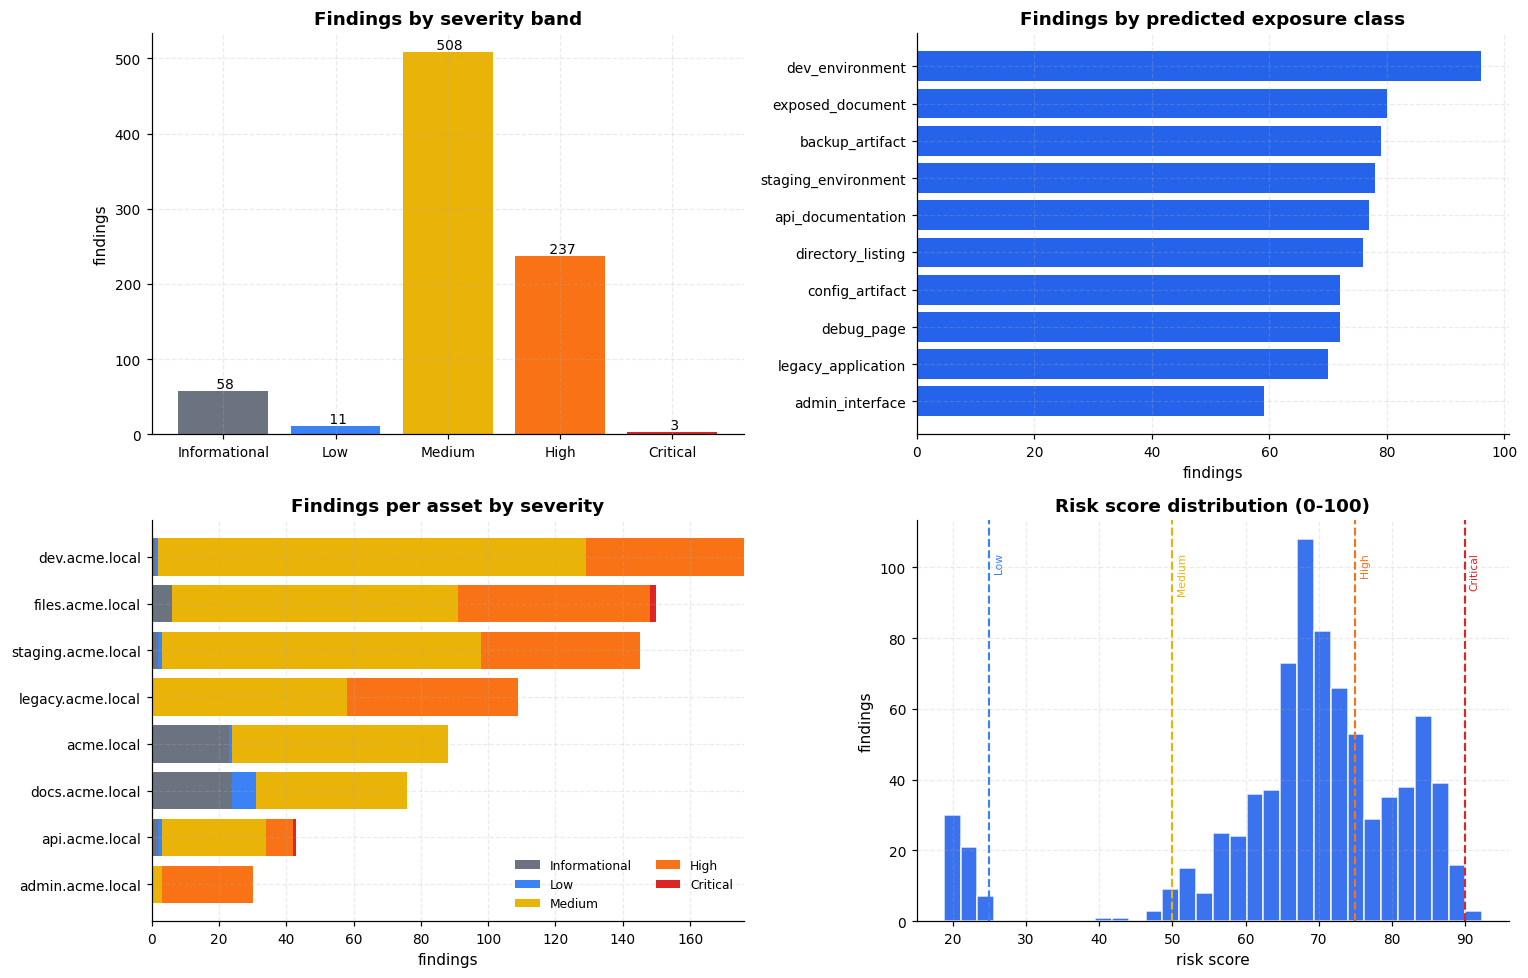

In [34]:
# --- Risk and severity visualisations -----------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1. Findings by severity
sev = findings_df["severity"].value_counts().reindex(SEVERITY_ORDER).fillna(0)
axes[0, 0].bar(sev.index, sev.values,
               color=[SEVERITY_COLORS[s] for s in sev.index])
axes[0, 0].set_title("Findings by severity band")
axes[0, 0].set_ylabel("findings")
for i, v in enumerate(sev.values):
    axes[0, 0].text(i, v, f" {int(v)}", ha="center", va="bottom", fontsize=9)

# 2. Findings by predicted category
cat = findings_df["predicted_class"].value_counts().head(10)
axes[0, 1].barh(cat.index[::-1], cat.values[::-1], color=ACCENT)
axes[0, 1].set_title("Findings by predicted exposure class")
axes[0, 1].set_xlabel("findings")

# 3. Findings by asset, stacked by severity
pivot_asset = (findings_df.pivot_table(index="asset", columns="severity",
                                       values="finding_id", aggfunc="count")
                          .reindex(columns=SEVERITY_ORDER).fillna(0))
pivot_asset = pivot_asset.loc[pivot_asset.sum(axis=1).sort_values().index]
bottom = np.zeros(len(pivot_asset))
for band in SEVERITY_ORDER:
    axes[1, 0].barh(pivot_asset.index, pivot_asset[band], left=bottom,
                    color=SEVERITY_COLORS[band], label=band)
    bottom += pivot_asset[band].values
axes[1, 0].set_title("Findings per asset by severity")
axes[1, 0].set_xlabel("findings")
axes[1, 0].legend(fontsize=8, ncol=2)

# 4. Risk score distribution
axes[1, 1].hist(findings_df["risk_score"], bins=32, color=ACCENT,
                edgecolor="white", alpha=0.9)
for lo, hi, name in SEVERITY_BANDS[1:]:
    axes[1, 1].axvline(lo, color=SEVERITY_COLORS[name], ls="--", lw=1.4)
    axes[1, 1].text(lo + 0.6, axes[1, 1].get_ylim()[1] * 0.92, name,
                    fontsize=7, color=SEVERITY_COLORS[name], rotation=90, va="top")
axes[1, 1].set_title("Risk score distribution (0-100)")
axes[1, 1].set_xlabel("risk score"); axes[1, 1].set_ylabel("findings")

plt.tight_layout()
save_fig(fig, "05_risk_overview")
plt.show()

## 20. LLM-Assisted Analysis (Optional)

`USE_LLM = False` is the default and the supported path. Everything below runs deterministically without it.

### What the LLM is and is not asked to do

**Asked to do** — analyst-narrative work, where fluent natural language genuinely adds value over a template:

- a concise explanation of what the finding is
- why it matters *in this specific context*
- a remediation recommendation
- a confidence assessment with reasoning
- a rolled-up analyst summary across the finding set
- optionally, GHDB query selection given the target profile

**Never asked to do** — anything that crosses from analysis into offence:

- generate exploit code, payloads, or attack chains
- retrieve, reconstruct, or guess real credentials or secrets
- suggest ways to bypass authentication or evade detection
- assess or target any system outside the synthetic environment

The system prompt states these constraints explicitly, and the findings passed to the model contain only synthetic placeholder values.

### Template fallback

With `USE_LLM = False`, `TemplateAnalysisProvider` produces the same five outputs from deterministic, class-specific templates parameterised by the finding's asset, severity band, and risk factors. The dashboard and the HTML report consume an identical interface either way, so **no downstream section can tell the difference**. This is a deliberate architectural choice: an optional dependency that silently degrades output quality elsewhere is not really optional.

### Why provider-agnostic

`LLMProvider` is an ABC with one method. `AnthropicProvider` and `OpenAIProvider` are thin HTTP adapters. Neither is exercised by default, and no key is bundled. If a call fails for any reason — no key, network error, malformed response — the analyst falls back to templates and logs a warning rather than raising.

In [35]:
# --- Provider-agnostic LLM interface ------------------------------------------

LLM_SYSTEM_PROMPT = (
    "You are a defensive security analyst reviewing exposure findings from an "
    "authorised assessment of a CONTROLLED SYNTHETIC test environment. "
    "All data you receive is fabricated; any credential-shaped strings are "
    "non-functional placeholders.\n"
    "Your job is triage and remediation guidance only. You must NOT produce "
    "exploit code, payloads, attack chains, authentication-bypass techniques, "
    "detection-evasion advice, or any real credentials. If asked for such "
    "content, decline and continue with the defensive analysis.\n"
    "Be concise, concrete, and specific to the finding you are given."
)


class LLMProvider(ABC):
    """Minimal provider-agnostic completion interface."""

    name: str = "abstract"

    @abstractmethod
    def complete(self, prompt: str, system: str = LLM_SYSTEM_PROMPT,
                 max_tokens: int = 600) -> str:
        raise NotImplementedError


class AnthropicProvider(LLMProvider):
    """Thin adapter for the Anthropic Messages API. Not exercised by default."""

    name = "anthropic"
    ENDPOINT = "https://api.anthropic.com/v1/messages"

    def __init__(self, api_key: str, model: str = "claude-sonnet-4-6") -> None:
        if not api_key:
            raise ValueError("An Anthropic API key is required.")
        self.api_key = api_key
        self.model = model

    def complete(self, prompt: str, system: str = LLM_SYSTEM_PROMPT,
                 max_tokens: int = 600) -> str:
        import requests
        resp = requests.post(
            self.ENDPOINT,
            headers={"x-api-key": self.api_key,
                     "anthropic-version": "2023-06-01",
                     "content-type": "application/json"},
            json={"model": self.model, "max_tokens": max_tokens, "system": system,
                  "messages": [{"role": "user", "content": prompt}]},
            timeout=60,
        )
        resp.raise_for_status()
        blocks = resp.json().get("content", [])
        return "\n".join(b.get("text", "") for b in blocks if b.get("type") == "text").strip()


class OpenAIProvider(LLMProvider):
    """Thin adapter for an OpenAI-compatible chat endpoint. Not exercised by default."""

    name = "openai"
    ENDPOINT = "https://api.openai.com/v1/chat/completions"

    def __init__(self, api_key: str, model: str = "gpt-4o-mini") -> None:
        if not api_key:
            raise ValueError("An OpenAI API key is required.")
        self.api_key = api_key
        self.model = model

    def complete(self, prompt: str, system: str = LLM_SYSTEM_PROMPT,
                 max_tokens: int = 600) -> str:
        import requests
        resp = requests.post(
            self.ENDPOINT,
            headers={"Authorization": f"Bearer {self.api_key}",
                     "Content-Type": "application/json"},
            json={"model": self.model, "max_tokens": max_tokens,
                  "messages": [{"role": "system", "content": system},
                               {"role": "user", "content": prompt}]},
            timeout=60,
        )
        resp.raise_for_status()
        return resp.json()["choices"][0]["message"]["content"].strip()


def make_llm_provider(config: Dict[str, Any]) -> Optional[LLMProvider]:
    """Instantiate a provider from CONFIG, or return None to use templates."""
    if not config.get("USE_LLM"):
        return None
    provider = (config.get("LLM_PROVIDER") or "").lower()
    key = config.get("LLM_API_KEY")
    try:
        if provider == "anthropic":
            return AnthropicProvider(key, config.get("LLM_MODEL") or "claude-sonnet-4-6")
        if provider == "openai":
            return OpenAIProvider(key, config.get("LLM_MODEL") or "gpt-4o-mini")
        logger.warning("USE_LLM is True but LLM_PROVIDER=%r is not recognised.", provider)
    except Exception as exc:
        logger.warning("LLM provider unavailable (%s); using deterministic templates.", exc)
    return None


LLM_PROVIDER: Optional[LLMProvider] = make_llm_provider(CONFIG)
print(f"LLM provider: {LLM_PROVIDER.name if LLM_PROVIDER else 'none (deterministic templates)'}")

LLM provider: none (deterministic templates)


In [36]:
# --- Deterministic template analysis (the default path) -----------------------

REMEDIATION_TEMPLATES: Dict[str, str] = {
    "config_artifact":
        "Remove the configuration file from the web root and block the path at the "
        "edge. Treat every value it contained as compromised and rotate it. Move "
        "configuration into a secrets manager or environment injection at deploy time, "
        "and add a CI check that fails the build when config files land under a "
        "publicly served directory.",
    "backup_artifact":
        "Delete the archive from the public path and move backups to storage that is "
        "not web-reachable. Restrict access to an authenticated service principal, "
        "enable object-level audit logging, and confirm whether the archive was "
        "retrieved before removal by reviewing access logs.",
    "admin_interface":
        "Restrict the administrative interface to an allow-listed network range or VPN, "
        "enforce multi-factor authentication, and remove the host from public DNS if it "
        "does not need to resolve externally. Add a noindex directive as a defence-in-depth "
        "measure, not as the primary control.",
    "debug_page":
        "Disable debug mode in the deployed configuration and ensure the framework's "
        "production settings are active. Replace verbose error handlers with a generic "
        "error page, and add a deployment gate that refuses to promote a build with "
        "debug enabled.",
    "legacy_application":
        "Confirm the application's decommission date and remove it from public routing "
        "immediately if no longer required. Where it must remain, place it behind "
        "authentication and a WAF, and record the unsupported components in the risk "
        "register with an owner and a review date.",
    "dev_environment":
        "Remove the development host from public DNS or place it behind authentication. "
        "Apply robots and noindex directives, request removal from search-engine caches, "
        "and ensure development environments are provisioned into a network segment that "
        "is not externally routable by default.",
    "staging_environment":
        "Put the staging environment behind authentication or an IP allow-list and remove "
        "it from the public index. Verify that staging data is sanitised and carries no "
        "production records, and align staging patch levels with production.",
    "directory_listing":
        "Disable automatic directory indexing on the server or virtual host. Audit the "
        "listed contents for material that should never have been web-reachable, and add "
        "an index placeholder so a misconfiguration cannot silently re-enable listing.",
    "exposed_document":
        "Review the document's classification and remove it from the public path if it is "
        "internal. Request cache removal from search providers, and add a publication "
        "review step so internally-marked documents cannot be deployed to public storage.",
    "api_documentation":
        "Confirm the documentation is intended to be public. If it describes internal-only "
        "endpoints, split the specification so internal routes are served only to "
        "authenticated consumers, and verify the documented endpoints enforce "
        "authorisation independently of their documentation status.",
    "benign_content":
        "No remediation required. Retained in the report to document the assessment's "
        "coverage and the tooling's false-positive profile.",
}

IMPACT_TEMPLATES: Dict[str, str] = {
    "config_artifact": "may disclose connection strings, keys, and internal service topology",
    "backup_artifact": "may disclose a complete point-in-time copy of application data",
    "admin_interface": "presents a privileged authentication surface to unauthenticated users",
    "debug_page": "discloses framework internals, code paths, and environment configuration",
    "legacy_application": "exposes unmaintained code with no vendor security support",
    "dev_environment": "exposes pre-release functionality outside the production change process",
    "staging_environment": "exposes a production-shaped environment with weaker controls",
    "directory_listing": "enumerates the file tree, removing the need for path guessing",
    "exposed_document": "publishes internally-classified material to an unauthenticated audience",
    "api_documentation": "maps the API attack surface, lowering the cost of enumeration",
    "benign_content": "is intended to be public and carries no disclosure impact",
}


@dataclass
class FindingAnalysis:
    explanation: str
    why_it_matters: str
    remediation: str
    confidence_assessment: str
    source: str


class TemplateAnalysisProvider:
    """Deterministic analyst narrative. The default, and always the fallback."""

    name = "template"

    def analyse(self, finding: Finding) -> FindingAnalysis:
        cls = finding.predicted_class or finding.exposure_type
        asset = ASSET_LOOKUP.get(finding.asset)
        readable = cls.replace("_", " ")
        factors = finding.risk_factors or {}

        explanation = (
            f"A {readable} was identified at {finding.url} on {finding.asset} "
            f"({asset.description.lower() if asset else 'unknown asset'}). It was "
            f"surfaced by GHDB query {finding.primary_query_id} "
            f"(\"{finding.primary_query}\") at result rank {finding.best_rank}, and "
            f"corroborated by {len(finding.discovered_by)} independent "
            f"{'query' if len(finding.discovered_by) == 1 else 'queries'}."
        )

        why = (
            f"This exposure {IMPACT_TEMPLATES.get(cls, 'expands the externally visible attack surface')}. "
            f"The host carries an asset criticality of "
            f"{factors.get('asset_criticality', 0):.2f} and the content scores "
            f"{factors.get('sensitivity', 0):.2f} on information sensitivity, yielding a "
            f"composite risk of {finding.risk_score} ({finding.severity}). "
            + ("Because the resource sits behind authentication, urgency is reduced but the "
               "path itself remains disclosed."
               if factors.get("authentication", 1.0) < 1.0 else
               "The resource is reachable without authentication.")
        )

        conf = finding.predicted_confidence or finding.confidence
        level = "high" if conf >= 0.8 else "moderate" if conf >= 0.6 else "low"
        confidence_assessment = (
            f"Detection confidence is {level} ({conf:.2f}), combining retrieval evidence "
            f"({len(finding.discovered_by)} corroborating queries, best rank "
            f"{finding.best_rank}) with the classifier's posterior for the "
            f"{readable} class. "
            + ("Manual confirmation is recommended before remediation is actioned."
               if level != "high" else
               "The evidence is consistent across retrieval and classification.")
        )

        return FindingAnalysis(
            explanation=explanation,
            why_it_matters=why,
            remediation=REMEDIATION_TEMPLATES.get(cls, "Review and restrict public access."),
            confidence_assessment=confidence_assessment,
            source="template",
        )


class FindingAnalyst:
    """
    Produces analyst narrative for findings.

    Uses an LLM when one is configured and reachable; otherwise deterministic
    templates. Consumers cannot tell the two apart at the interface level.
    """

    def __init__(self, provider: Optional[LLMProvider]) -> None:
        self.provider = provider
        self.templates = TemplateAnalysisProvider()
        self._log = logging.getLogger("ghdb.analyst")

    def _prompt(self, finding: Finding) -> str:
        return (
            "Analyse this exposure finding from a controlled synthetic assessment.\n\n"
            f"Finding ID       : {finding.finding_id}\n"
            f"URL              : {finding.url}\n"
            f"Asset            : {finding.asset}\n"
            f"Classified as    : {finding.predicted_class}\n"
            f"Severity / score : {finding.severity} / {finding.risk_score}\n"
            f"Confidence       : {finding.predicted_confidence}\n"
            f"Technology       : {finding.technology}\n"
            f"Discovery query  : {finding.primary_query} ({finding.primary_query_id})\n"
            f"Evidence snippet : {finding.evidence}\n\n"
            "Respond with exactly four sections, each on its own line, prefixed:\n"
            "EXPLANATION: <2 sentences>\n"
            "WHY_IT_MATTERS: <2 sentences>\n"
            "REMEDIATION: <2-3 concrete steps>\n"
            "CONFIDENCE: <1-2 sentences assessing detection confidence>\n"
        )

    @staticmethod
    def _parse(text: str) -> Optional[FindingAnalysis]:
        fields = {}
        for key, label in (("explanation", "EXPLANATION:"), ("why", "WHY_IT_MATTERS:"),
                           ("rem", "REMEDIATION:"), ("conf", "CONFIDENCE:")):
            m = re.search(rf"{label}\s*(.+?)(?=\n[A-Z_]+:|\Z)", text, re.S)
            if not m:
                return None
            fields[key] = " ".join(m.group(1).split())
        return FindingAnalysis(fields["explanation"], fields["why"], fields["rem"],
                               fields["conf"], source="llm")

    def analyse(self, finding: Finding) -> FindingAnalysis:
        if self.provider is not None:
            try:
                parsed = self._parse(self.provider.complete(self._prompt(finding)))
                if parsed:
                    return parsed
                self._log.warning("LLM response unparseable for %s; using template.",
                                  finding.finding_id)
            except Exception as exc:
                self._log.warning("LLM call failed for %s (%s); using template.",
                                  finding.finding_id, exc)
        return self.templates.analyse(finding)

    def analyse_all(self, findings: Sequence[Finding]) -> None:
        for f in findings:
            a = self.analyse(f)
            f.explanation = f"{a.explanation} {a.why_it_matters}"
            f.remediation = a.remediation

    def summarise(self, findings: Sequence[Finding]) -> str:
        """Roll-up analyst summary across the finding set."""
        by_sev = Counter(f.severity for f in findings)
        by_cls = Counter(f.predicted_class for f in findings)
        by_asset = Counter(f.asset for f in findings)
        critical_high = [f for f in findings if f.severity in ("Critical", "High")]
        top_assets = ", ".join(f"{h} ({n})" for h, n in by_asset.most_common(3))
        top_classes = ", ".join(f"{c.replace('_', ' ')} ({n})" for c, n in by_cls.most_common(3))

        if self.provider is not None:
            try:
                prompt = (
                    "Write a 4-6 sentence executive summary for a security assessment of a "
                    "controlled synthetic environment.\n"
                    f"Findings: {len(findings)}. By severity: {dict(by_sev)}.\n"
                    f"Top exposure classes: {top_classes}.\n"
                    f"Most affected assets: {top_assets}.\n"
                    "Focus on business risk and remediation priority. No exploit detail."
                )
                text = self.provider.complete(prompt, max_tokens=500)
                if text:
                    return text
            except Exception as exc:
                self._log.warning("LLM summary failed (%s); using template.", exc)

        return (
            f"Search-engine reconnaissance against {CONFIG['ORG_NAME']} surfaced "
            f"{len(findings)} distinct exposures across {len(by_asset)} internet-facing "
            f"assets, of which {len(critical_high)} are rated High or Critical. "
            f"The dominant exposure classes are {top_classes}. "
            f"Exposure concentrates on {top_assets}, which should be prioritised for "
            f"remediation. All findings were discoverable through passive search-index "
            f"queries alone, meaning an external actor could enumerate this surface "
            f"without ever contacting the organisation's infrastructure. "
            f"Immediate priority is the {by_sev.get('Critical', 0) + by_sev.get('High', 0)} "
            f"High and Critical findings, particularly configuration and backup artefacts, "
            f"where a single retrieval can compromise credentials or bulk data."
        )


def select_queries_with_llm(engine: "GHDBQueryEngine",
                            top_k: Optional[int] = None) -> List[GHDBQuery]:
    """
    Optional LLM-assisted query selection.

    Falls back to the deterministic TF-IDF ranker whenever an LLM is not
    configured, the call fails, or the response cannot be validated against the
    catalog. Returned IDs are always validated - the model cannot inject a
    query that is not in the local catalog.
    """
    k = top_k or int(CONFIG["INTELLIGENT_TOP_K_QUERIES"])
    if LLM_PROVIDER is None:
        logger.info("LLM selection requested but USE_LLM=False; using TF-IDF ranking.")
        return engine.select_intelligent(k)

    catalog_lines = "\n".join(
        f"{q.query_id} | {q.category} | requires: {', '.join(q.required_tech) or 'none'} | {q.description}"
        for q in engine.catalog)
    prompt = (
        "You are selecting GHDB reconnaissance queries for an authorised assessment of a "
        "controlled synthetic environment.\n\n"
        f"TARGET PROFILE:\n{engine.target_profile_text()[:1500]}\n\n"
        f"AVAILABLE QUERIES:\n{catalog_lines}\n\n"
        f"Select the {k} query IDs most likely to surface real exposures on THIS target, "
        "prioritising queries whose technology prerequisites the target actually meets.\n"
        "Respond with a JSON array of query ID strings and nothing else."
    )
    try:
        raw = LLM_PROVIDER.complete(prompt, max_tokens=900)
        ids = json.loads(re.search(r"\[.*\]", raw, re.S).group(0))
        selected = [GHDB_BY_ID[i] for i in ids if i in GHDB_BY_ID]
        if selected:
            logger.info("LLM selected %d valid queries (%d requested).", len(selected), k)
            return selected[:k]
        logger.warning("LLM returned no valid query IDs; using TF-IDF ranking.")
    except Exception as exc:
        logger.warning("LLM query selection failed (%s); using TF-IDF ranking.", exc)
    return engine.select_intelligent(k)


analyst = FindingAnalyst(LLM_PROVIDER)
analyst.analyse_all(FINDINGS)
ANALYST_SUMMARY = analyst.summarise(FINDINGS)

_demo = max(FINDINGS, key=lambda f: f.risk_score or 0)
print(f"Analysis source: {'LLM' if LLM_PROVIDER else 'deterministic templates'}\n")
print(f"--- {_demo.finding_id} ({_demo.severity}, {_demo.risk_score}) ---")
print(textwrap.fill(_demo.explanation, 96))
print("\nRemediation:")
print(textwrap.fill(_demo.remediation, 96))
print("\n--- Analyst summary ---")
print(textwrap.fill(ANALYST_SUMMARY, 96))

Analysis source: deterministic templates

--- ACME-0142 (Critical, 92.32) ---
A config artifact was identified at http://api.acme.local/settings/search_config.ini on
api.acme.local (api gateway serving public and internal interfaces). It was surfaced by GHDB
query GHDB-033 ("site:acme.local intext:"API_KEY" configuration") at result rank 4, and
corroborated by 2 independent queries. This exposure may disclose connection strings, keys, and
internal service topology. The host carries an asset criticality of 0.90 and the content scores
0.97 on information sensitivity, yielding a composite risk of 92.32 (Critical). The resource is
reachable without authentication.

Remediation:
Remove the configuration file from the web root and block the path at the edge. Treat every
value it contained as compromised and rotate it. Move configuration into a secrets manager or
environment injection at deploy time, and add a CI check that fails the build when config files
land under a publicly served direct

## 21. Attack-Surface Graph

Findings in a flat table lose the structure that makes attack surface *actionable*. A graph restores it, and answers questions a list cannot:

- Which single host, if fixed, removes the most high-risk exposure?
- Which technologies span multiple hosts, so that one framework CVE becomes a multi-host incident?
- Which findings cluster on the same endpoint, indicating a systemic misconfiguration rather than an isolated slip?

### Schema

**Node types:** `Organization`, `Domain`, `Technology`, `Endpoint`, `Finding`

**Edge types:**

| Edge | From → To | Meaning |
|---|---|---|
| `OWNS` | Organization → Domain | Organisational ownership |
| `HOSTS` | Domain → Endpoint | The host serves this endpoint group |
| `RUNS` | Domain → Technology | Fingerprinted technology, weighted by confidence |
| `CONTAINS` | Endpoint → Finding | The endpoint group contains this finding |
| `EXPOSES` | Domain → Finding | Direct exposure attribution, weighted by risk |
| `DISCOVERED_BY` | Finding → Query | Provenance back to the GHDB query |
| `RELATED_TO` | Finding ↔ Finding | Same asset and same exposure class |

Endpoints are grouped by their first two path segments (`/files/backups/...` → `/files/backups`) so that dozens of individual artefacts collapse into the directory that actually needs fixing.

### Metrics

Degree centrality identifies structural hubs. Betweenness (sampled, seeded) identifies nodes that bridge otherwise separate regions — a technology shared across a dev host and a production host is a bridge, and bridges are where lateral movement begins. Per-asset roll-ups give findings count, high-risk count, and aggregate risk.

In [37]:
# --- Attack-surface graph -----------------------------------------------------

class AttackSurfaceGraph:
    """Builds and analyses a typed graph of the discovered attack surface."""

    def __init__(self, org_name: str, assets: Sequence[DiscoveredAsset],
                 tech_detections: Sequence[TechnologyDetection],
                 findings: Sequence[Finding]) -> None:
        self.org = org_name
        self.assets = list(assets)
        self.techs = list(tech_detections)
        self.findings = list(findings)
        self.G = nx.MultiDiGraph()
        self._log = logging.getLogger("ghdb.graph")

    @staticmethod
    def _endpoint_group(path: str) -> str:
        parts = [p for p in path.split("?")[0].split("/") if p]
        return "/" + "/".join(parts[:2]) if parts else "/"

    def build(self) -> nx.MultiDiGraph:
        G = self.G
        G.add_node(self.org, node_type="Organization", label=self.org)

        for a in self.assets:
            G.add_node(a.host, node_type="Domain", label=a.host, kind=a.kind,
                       criticality=a.criticality, indexed_documents=a.indexed_documents)
            G.add_edge(self.org, a.host, key="OWNS", edge_type="OWNS", weight=a.criticality)

        for t in self.techs:
            tid = f"tech::{t.technology}"
            if not G.has_node(tid):
                G.add_node(tid, node_type="Technology", label=t.technology)
            G.add_edge(t.host, tid, key="RUNS", edge_type="RUNS", weight=t.confidence)

        by_key: Dict[Tuple[str, str], List[Finding]] = defaultdict(list)
        for f in self.findings:
            group = self._endpoint_group(f.path)
            eid = f"{f.asset}{group}"
            if not G.has_node(eid):
                G.add_node(eid, node_type="Endpoint", label=eid, host=f.asset)
                G.add_edge(f.asset, eid, key="HOSTS", edge_type="HOSTS", weight=1.0)

            G.add_node(f.finding_id, node_type="Finding", label=f.finding_id,
                       url=f.url, severity=f.severity, risk_score=f.risk_score,
                       exposure_class=f.predicted_class, asset=f.asset)
            G.add_edge(eid, f.finding_id, key="CONTAINS", edge_type="CONTAINS", weight=1.0)
            G.add_edge(f.asset, f.finding_id, key="EXPOSES", edge_type="EXPOSES",
                       weight=(f.risk_score or 0) / 100.0)

            qid = f"query::{f.primary_query_id}"
            if not G.has_node(qid):
                G.add_node(qid, node_type="Query", label=f.primary_query_id,
                           category=f.query_category)
            G.add_edge(f.finding_id, qid, key="DISCOVERED_BY", edge_type="DISCOVERED_BY",
                       weight=1.0)

            by_key[(f.asset, f.predicted_class or f.exposure_type)].append(f)

        # RELATED_TO: findings sharing an asset and exposure class, chained to
        # keep the edge count linear rather than quadratic.
        for _, group_findings in by_key.items():
            ordered = sorted(group_findings, key=lambda f: -(f.risk_score or 0))
            for a, b in zip(ordered, ordered[1:]):
                G.add_edge(a.finding_id, b.finding_id, key="RELATED_TO",
                           edge_type="RELATED_TO", weight=0.5)

        self._log.info("Graph built: %d nodes, %d edges.",
                       G.number_of_nodes(), G.number_of_edges())
        return G

    # -- metrics -------------------------------------------------------------
    def metrics(self) -> Dict[str, Any]:
        G = self.G
        simple = nx.Graph(G)  # collapse multi-edges for centrality
        degree = nx.degree_centrality(simple)
        k = min(96, max(simple.number_of_nodes() - 1, 1))
        betweenness = nx.betweenness_centrality(simple, k=k, seed=SEED)

        types = Counter(nx.get_node_attributes(G, "node_type").values())
        edge_types = Counter(d["edge_type"] for _, _, d in G.edges(data=True))

        return {
            "nodes": G.number_of_nodes(),
            "edges": G.number_of_edges(),
            "node_types": dict(types),
            "edge_types": dict(edge_types),
            "density": round(nx.density(simple), 5),
            "connected_components": nx.number_connected_components(simple),
            "degree_centrality": degree,
            "betweenness_centrality": betweenness,
        }

    def asset_rollup(self) -> pd.DataFrame:
        rows = []
        for a in self.assets:
            fs = [f for f in self.findings if f.asset == a.host]
            high = [f for f in fs if f.severity in ("High", "Critical")]
            techs = [t.technology for t in self.techs if t.host == a.host]
            rows.append({
                "asset": a.host, "kind": a.kind, "criticality": a.criticality,
                "technologies": len(techs), "findings": len(fs),
                "high_risk_findings": len(high),
                "mean_risk": round(np.mean([f.risk_score for f in fs]), 2) if fs else 0.0,
                "total_risk": round(sum(f.risk_score or 0 for f in fs), 1),
            })
        return pd.DataFrame(rows).sort_values("total_risk", ascending=False).reset_index(drop=True)


asg = AttackSurfaceGraph(CONFIG["ORG_NAME"], DISCOVERED_ASSETS, TECH_DETECTIONS, FINDINGS)
ATTACK_GRAPH = asg.build()
GRAPH_METRICS = asg.metrics()
asset_rollup_df = asg.asset_rollup()

print(f"Nodes: {GRAPH_METRICS['nodes']}   Edges: {GRAPH_METRICS['edges']}   "
      f"Density: {GRAPH_METRICS['density']}")
print(f"Node types: {GRAPH_METRICS['node_types']}")
print(f"Edge types: {GRAPH_METRICS['edge_types']}\n")

_deg = GRAPH_METRICS["degree_centrality"]
_structural = [(n, v) for n, v in _deg.items()
               if ATTACK_GRAPH.nodes[n].get("node_type") != "Finding"]
_structural.sort(key=lambda t: -t[1])
print("Top structural nodes by degree centrality:")
for n, v in _structural[:10]:
    print(f"  {v:.4f}  [{ATTACK_GRAPH.nodes[n]['node_type']:<12}] {n}")

print()
display(asset_rollup_df)

16:46:09 | INFO    | ghdb.graph             | Graph built: 1610 nodes, 4023 edges.


Nodes: 1610   Edges: 4023   Density: 0.00311
Node types: {'Organization': 1, 'Domain': 8, 'Technology': 16, 'Endpoint': 715, 'Finding': 817, 'Query': 53}
Edge types: {'OWNS': 8, 'RUNS': 90, 'HOSTS': 715, 'EXPOSES': 817, 'CONTAINS': 817, 'DISCOVERED_BY': 817, 'RELATED_TO': 759}

Top structural nodes by degree centrality:
  0.2063  [Domain      ] dev.acme.local
  0.1927  [Domain      ] files.acme.local
  0.1659  [Domain      ] staging.acme.local
  0.1436  [Domain      ] legacy.acme.local
  0.1150  [Domain      ] acme.local
  0.0963  [Domain      ] docs.acme.local
  0.0566  [Domain      ] api.acme.local
  0.0367  [Domain      ] admin.acme.local
  0.0174  [Query       ] query::GHDB-081
  0.0168  [Query       ] query::GHDB-082



,asset,kind,criticality,technologies,findings,high_risk_findings,mean_risk,total_risk
0,dev.acme.local,dev,0.70,15,176,47,70.82,12463.7
1,files.acme.local,files,0.85,13,150,59,73.98,11096.9
2,staging.acme.local,staging,0.75,14,145,47,71.50,10368.2
3,legacy.acme.local,legacy,0.80,14,109,51,75.51,8230.5
4,acme.local,corporate,0.55,13,88,0,53.03,4666.4
5,docs.acme.local,docs,0.45,9,76,0,44.54,3384.7
6,api.acme.local,api,0.90,7,43,9,63.53,2731.8
7,admin.acme.local,admin,1.00,5,30,27,79.75,2392.6


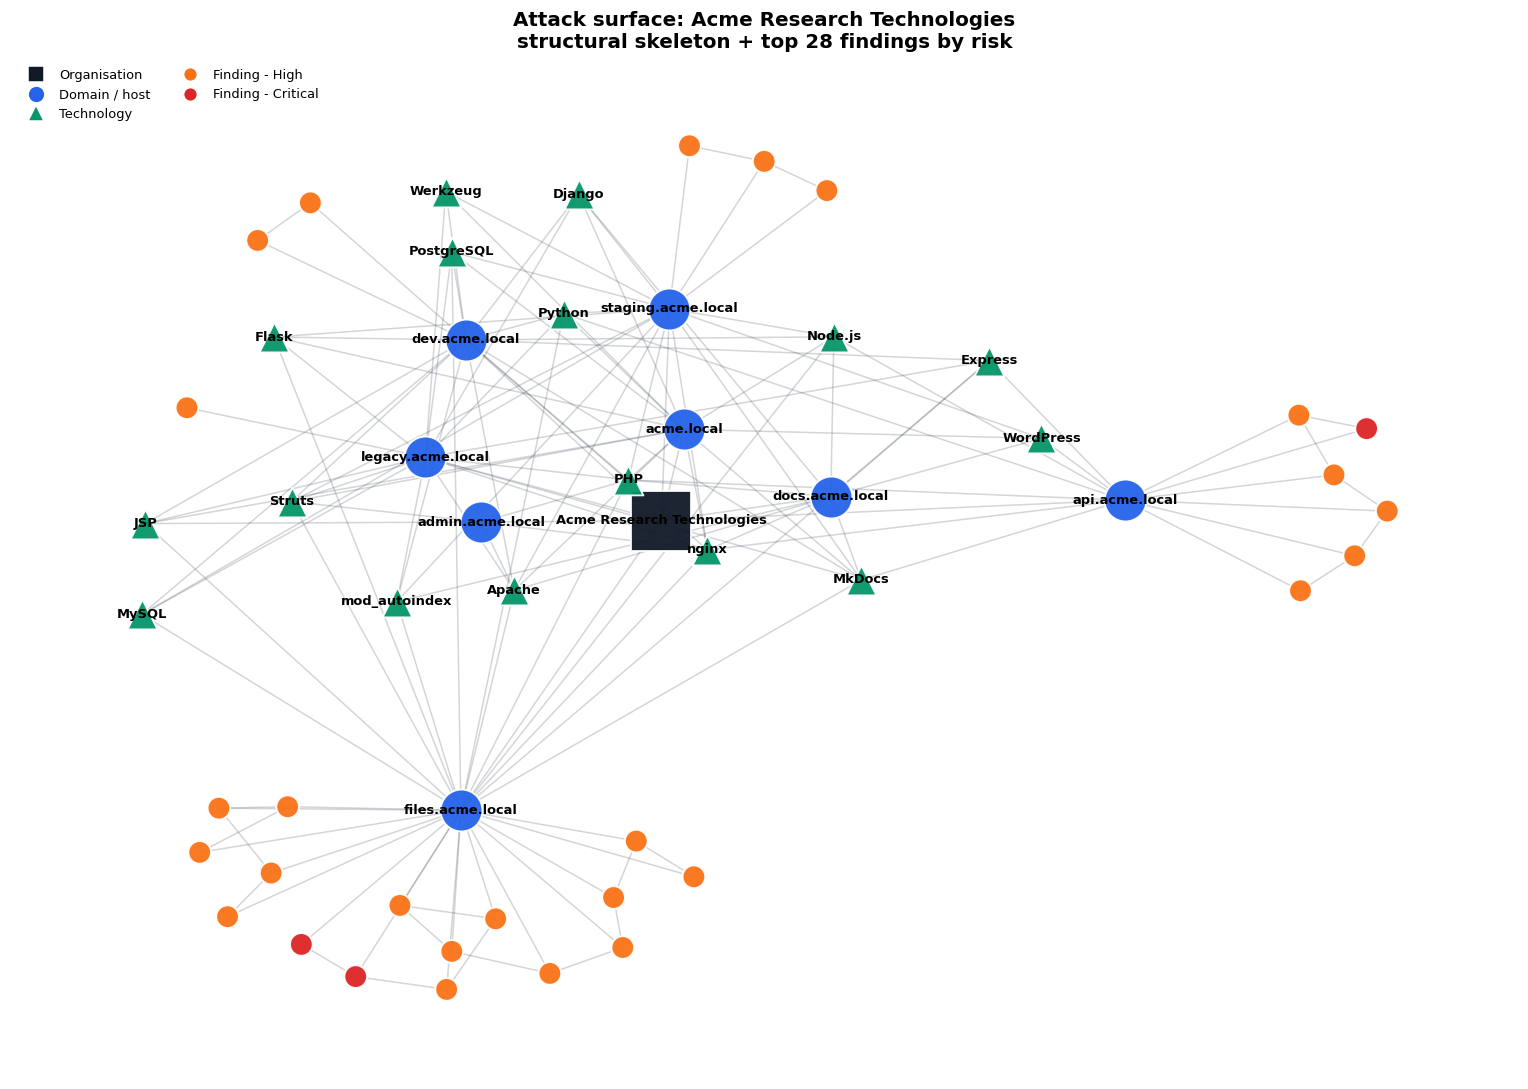

In [38]:
# --- Attack-surface graph visualisation ---------------------------------------
# The full graph has hundreds of finding nodes. Visualising it whole produces a
# hairball, so the figure shows the structural skeleton plus the highest-risk
# findings - which is what an analyst actually needs to look at.

TOP_N_FINDINGS = 28
top_findings = sorted(FINDINGS, key=lambda f: -(f.risk_score or 0))[:TOP_N_FINDINGS]
keep = ({CONFIG["ORG_NAME"]}
        | {a.host for a in DISCOVERED_ASSETS}
        | {f"tech::{t}" for t in ESTATE_TECH}
        | {f.finding_id for f in top_findings})
sub = nx.Graph(ATTACK_GRAPH.subgraph(keep))

NODE_STYLE = {
    "Organization": ("#111827", 1500, "s"),
    "Domain":       ("#2563eb", 750, "o"),
    "Technology":   ("#059669", 380, "^"),
    "Finding":      (None, 220, "o"),
}

pos = nx.spring_layout(sub, seed=SEED, k=0.55, iterations=180)

fig, ax = plt.subplots(figsize=(14, 10))
for ntype, (colour, size, shape) in NODE_STYLE.items():
    nodes = [n for n in sub.nodes if sub.nodes[n].get("node_type") == ntype]
    if not nodes:
        continue
    colours = ([SEVERITY_COLORS.get(sub.nodes[n].get("severity", "Medium"), "#6b7280")
                for n in nodes] if ntype == "Finding" else colour)
    nx.draw_networkx_nodes(sub, pos, nodelist=nodes, node_color=colours,
                           node_size=size, node_shape=shape, ax=ax,
                           edgecolors="white", linewidths=1.2, alpha=0.95)

nx.draw_networkx_edges(sub, pos, ax=ax, alpha=0.22, width=1.0, edge_color="#374151")

labels = {n: sub.nodes[n].get("label", n) for n in sub.nodes
          if sub.nodes[n].get("node_type") in ("Organization", "Domain", "Technology")}
labels = {n: l.replace("tech::", "") for n, l in labels.items()}
nx.draw_networkx_labels(sub, pos, labels=labels, font_size=8.5,
                        font_weight="bold", ax=ax)

legend = [plt.Line2D([0], [0], marker="s", color="w", markerfacecolor="#111827",
                     markersize=11, label="Organisation"),
          plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="#2563eb",
                     markersize=11, label="Domain / host"),
          plt.Line2D([0], [0], marker="^", color="w", markerfacecolor="#059669",
                     markersize=11, label="Technology")]
legend += [plt.Line2D([0], [0], marker="o", color="w",
                      markerfacecolor=SEVERITY_COLORS[s], markersize=9,
                      label=f"Finding - {s}")
           for s in SEVERITY_ORDER
           if any(sub.nodes[n].get("severity") == s for n in sub.nodes)]
ax.legend(handles=legend, loc="upper left", fontsize=8.5, ncol=2)
ax.set_title(f"Attack surface: {CONFIG['ORG_NAME']}\n"
             f"structural skeleton + top {TOP_N_FINDINGS} findings by risk",
             fontsize=13, fontweight="bold")
ax.axis("off")
ax.grid(False)
plt.tight_layout()
save_fig(fig, "06_attack_surface_graph")
plt.show()

## 22. Query Effectiveness Analysis

Which GHDB families are worth the budget? With ground truth available, this becomes measurable rather than a matter of folklore.

Per query, computed against the ground-truth labels:

| Metric | Definition |
|---|---|
| `results` | Raw results returned (capped at `RESULTS_PER_QUERY`) |
| `unique_findings` | Distinct URLs contributed after deduplication |
| `true_positives` | Retrieved documents whose true class is in the query's `target_classes` |
| `precision` | `true_positives / results` — on-target yield |
| `recall` | Fraction of all ground-truth documents in the target classes that this query retrieved |
| `high_risk` | Retrieved documents whose true class is high-severity |
| `findings_per_query` | Aggregate efficiency at the category level |

Two distinct notions of "wrong" are worth separating, and the table keeps them apart:

- A dork retrieving a document of a *different but still exposed* class is only partially wrong — it surfaced a real problem, just not the one it was aiming for. That is why per-query precision here is stricter than the sweep-level precision in Section 13, which counts any true exposure as a hit.
- A dork retrieving benign content is straightforwardly wrong, and drives analyst fatigue.

In [39]:
# --- Per-query and per-category effectiveness ---------------------------------

class QueryEffectivenessAnalyzer:
    """Scores each GHDB query against ground truth."""

    def __init__(self, corpus_by_id: Dict[str, CorpusDocument],
                 ground_truth: Dict[str, str]) -> None:
        self.corpus_by_id = corpus_by_id
        self.gt = ground_truth
        self._class_index: Dict[str, set] = defaultdict(set)
        for did, cls in ground_truth.items():
            self._class_index[cls].add(did)

    def analyse(self, run: ReconRun, findings: Sequence[Finding]) -> pd.DataFrame:
        results_by_query: Dict[str, List[SearchResult]] = defaultdict(list)
        for r in run.results:
            results_by_query[r.query_id].append(r)

        primary_counts = Counter(f.primary_query_id for f in findings)
        rows = []
        for q in run.queries:
            res = results_by_query.get(q.query_id, [])
            retrieved = {r.doc_id for r in res if r.doc_id}
            target_universe = set().union(
                *[self._class_index[c] for c in q.target_classes]) if q.target_classes else set()

            tp = len(retrieved & target_universe)
            on_target_precision = tp / len(retrieved) if retrieved else 0.0
            recall = tp / len(target_universe) if target_universe else 0.0
            f1 = (2 * on_target_precision * recall / (on_target_precision + recall)
                  ) if (on_target_precision + recall) else 0.0
            exposures = sum(1 for d in retrieved if d in self.gt)
            high_risk = sum(1 for d in retrieved
                            if self.gt.get(d) in HIGH_SEVERITY_CLASSES)

            rows.append({
                "query_id": q.query_id, "category": q.category,
                "query": q.query_template.replace("{domain}", CONFIG["ORG_DOMAIN"]),
                "results": len(res),
                "unique_findings": primary_counts.get(q.query_id, 0),
                "true_positives": tp,
                "exposures_found": exposures,
                "high_risk": high_risk,
                "precision": round(on_target_precision, 4),
                "recall": round(recall, 4),
                "f1": round(f1, 4),
                "exposure_rate": round(exposures / len(res), 4) if res else 0.0,
            })
        return pd.DataFrame(rows)

    @staticmethod
    def by_category(query_df: pd.DataFrame) -> pd.DataFrame:
        agg = (query_df.groupby("category")
               .agg(queries=("query_id", "count"),
                    results=("results", "sum"),
                    unique_findings=("unique_findings", "sum"),
                    high_risk=("high_risk", "sum"),
                    mean_precision=("precision", "mean"),
                    mean_recall=("recall", "mean"))
               .reset_index())
        agg["findings_per_query"] = (agg["unique_findings"] / agg["queries"]).round(2)
        agg["mean_precision"] = agg["mean_precision"].round(4)
        agg["mean_recall"] = agg["mean_recall"].round(4)
        return agg.sort_values("unique_findings", ascending=False).reset_index(drop=True)


qea = QueryEffectivenessAnalyzer(CORPUS_BY_ID, GROUND_TRUTH_INSTANCES)
query_metrics_df = qea.analyse(recon_run, FINDINGS)
category_metrics_df = QueryEffectivenessAnalyzer.by_category(query_metrics_df)

print("Query effectiveness by category\n")
display(category_metrics_df)

print("\nTop 10 individual queries by unique findings contributed:\n")
display(query_metrics_df.sort_values("unique_findings", ascending=False)
        .head(10)[["query_id", "category", "query", "results", "unique_findings",
                   "high_risk", "precision", "recall"]].reset_index(drop=True))

_zero = query_metrics_df[query_metrics_df["results"] == 0]
print(f"\nQueries returning zero results: {len(_zero)} of {len(query_metrics_df)}")
if len(_zero):
    print("  " + ", ".join(_zero["query_id"].tolist()))

Query effectiveness by category



,category,queries,results,unique_findings,high_risk,mean_precision,mean_recall,findings_per_query
0,Exposed Documents,5,142,122,4,0.6400,0.1222,24.40
1,Backup Artefacts,6,132,88,114,0.8412,0.1892,14.67
2,Configuration Artefacts,6,133,82,117,0.8473,0.2354,13.67
3,Technology Discovery,4,120,81,33,0.9083,0.1470,20.25
4,Staging Environments,4,104,81,1,0.7840,0.1853,20.25
5,Development Environments,5,115,72,14,0.8242,0.1278,14.40
6,API Documentation,4,102,70,2,0.8479,0.1545,17.50
7,Debugging Pages,6,109,69,87,0.7957,0.1510,11.50
8,Exposed Administrative Interfaces,5,64,54,56,0.8532,0.1000,10.80
9,Legacy Applications,5,102,53,11,0.6847,0.1572,10.60



Top 10 individual queries by unique findings contributed:



,query_id,category,query,results,unique_findings,high_risk,precision,recall
0,GHDB-081,Exposed Documents,site:acme.local filetype:xlsx,30,28,2,0.4667,0.0972
1,GHDB-082,Exposed Documents,site:acme.local filetype:csv,30,27,2,0.6667,0.1389
2,GHDB-080,Exposed Documents,site:acme.local filetype:pdf,30,26,0,0.1333,0.0278
3,GHDB-050,Staging Environments,site:acme.local inurl:staging,30,25,1,0.9333,0.2500
4,GHDB-103,Technology Discovery,"site:acme.local intext:""npm run dev""",30,25,0,1.0000,0.2344
5,GHDB-053,Staging Environments,site:acme.local inurl:preprod OR inurl:qa,30,24,0,0.6667,0.1786
6,GHDB-022,Backup Artefacts,site:acme.local filetype:zip backup,26,23,20,0.7308,0.1979
7,GHDB-083,Exposed Documents,"site:acme.local intext:""internal use only""",30,23,0,0.9333,0.1944
8,GHDB-100,Technology Discovery,"site:acme.local intext:""apache server at""",30,22,0,0.9333,0.1167
9,GHDB-030,Configuration Artefacts,site:acme.local inurl:.env,30,22,26,0.8000,0.3000



Queries returning zero results: 1 of 54
  GHDB-091


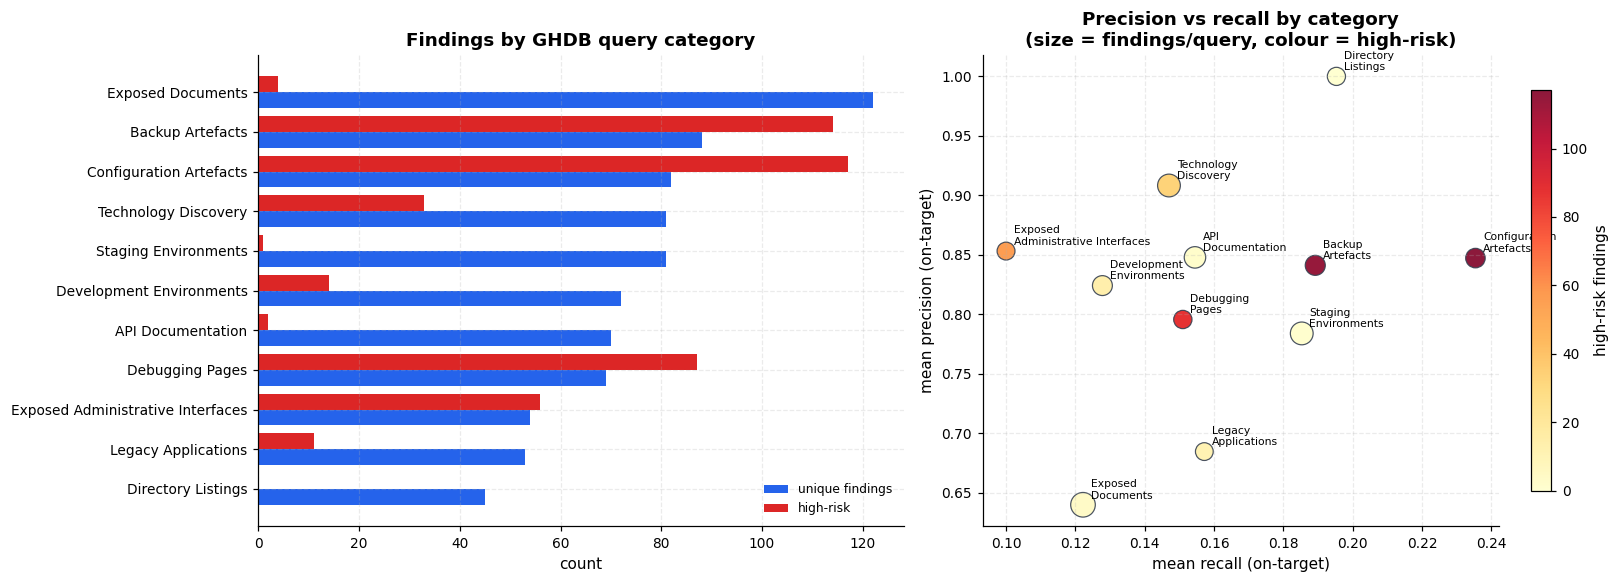

In [40]:
# --- Query effectiveness visualisation ----------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(15, 5.4))

cat = category_metrics_df.sort_values("unique_findings")
y = np.arange(len(cat))
axes[0].barh(y - 0.2, cat["unique_findings"], height=0.4, color=ACCENT, label="unique findings")
axes[0].barh(y + 0.2, cat["high_risk"], height=0.4, color="#dc2626", label="high-risk")
axes[0].set_yticks(y)
axes[0].set_yticklabels(cat["category"], fontsize=9)
axes[0].set_xlabel("count")
axes[0].set_title("Findings by GHDB query category")
axes[0].legend(fontsize=8)

sc = axes[1].scatter(category_metrics_df["mean_recall"],
                     category_metrics_df["mean_precision"],
                     s=40 + 9 * category_metrics_df["findings_per_query"],
                     c=category_metrics_df["high_risk"], cmap="YlOrRd",
                     edgecolors="#374151", linewidths=0.8, alpha=0.9)
for _, r in category_metrics_df.iterrows():
    axes[1].annotate(r["category"].replace(" ", "\n", 1),
                     (r["mean_recall"], r["mean_precision"]),
                     fontsize=7, xytext=(5, 4), textcoords="offset points")
axes[1].set_xlabel("mean recall (on-target)")
axes[1].set_ylabel("mean precision (on-target)")
axes[1].set_title("Precision vs recall by category\n(size = findings/query, colour = high-risk)")
fig.colorbar(sc, ax=axes[1], label="high-risk findings", shrink=0.85)

plt.tight_layout()
save_fig(fig, "07_query_effectiveness")
plt.show()

## 23. Experiments

Four reconnaissance configurations, evaluated on identical ground truth so the comparison is apples to apples.

| # | Method | Description |
|---|---|---|
| **1** | Static GHDB selection | Baseline. Run the entire catalog, including dorks for technologies the target does not run. |
| **2** | Technology-aware selection | Filter to queries whose technology and asset-kind prerequisites the target actually satisfies. |
| **3** | Technology-aware + ML filter | As (2), then drop findings the classifier predicts are `benign_content`. Tests whether ML triage improves precision without destroying recall. |
| **4** | Intelligent (TF-IDF ranked) + ML filter | Top-K queries by relevance to the target profile, then ML filtering. Optionally LLM-selected when `USE_LLM=True`. |

### What each metric means here

Precision, recall, and F1 are computed at the **document level against ground-truth exposure status** — of the documents surfaced, how many were genuine exposures, and of all genuine exposures, how many were surfaced. High-risk discoveries counts retrieved documents whose true class is in the high-severity set.

### The trade-off being measured

These configurations are not strictly ordered. Experiment 1 runs the most queries and should therefore find the most, at the worst efficiency. Experiments 3 and 4 trade recall for precision and for query budget. **Which one is "best" depends on whether the constraint is analyst time or coverage** — and the table makes that trade-off explicit instead of declaring a winner.

In [41]:
# --- Experiment harness -------------------------------------------------------

@dataclass
class ExperimentResult:
    name: str
    strategy: str
    n_queries: int
    n_raw_results: int
    n_findings: int
    precision: float
    recall: float
    f1: float
    high_risk: int
    coverage: float
    findings_per_query: float
    ml_filtered: bool


def run_experiment(name: str, queries: Sequence[GHDBQuery], strategy: str,
                   ml_filter: bool = False) -> Tuple[ExperimentResult, List[Finding]]:
    """Execute a reconnaissance configuration and score it against ground truth."""
    run = recon_engine.run(queries, strategy=strategy)
    findings = extractor.extract(run)

    if ml_filter and findings:
        records = pd.DataFrame([
            build_record(f.url, f.title, f.snippet, f.file_type, f.technology,
                         doc_id=f.doc_id) for f in findings])
        preds = FINAL_MODEL.predict(records)
        probas = FINAL_MODEL.predict_proba(records)
        kept: List[Finding] = []
        for f, p, pr in zip(findings, preds, probas):
            f.predicted_class = p
            f.predicted_confidence = round(float(pr.max()), 4)
            if p != "benign_content":
                kept.append(f)
        findings = kept

    doc_ids = {f.doc_id for f in findings}
    m = evaluator.score(doc_ids)
    high_risk = sum(1 for d in doc_ids
                    if GROUND_TRUTH_INSTANCES.get(d) in HIGH_SEVERITY_CLASSES)

    return ExperimentResult(
        name=name, strategy=strategy, n_queries=len(queries),
        n_raw_results=run.n_results, n_findings=len(findings),
        precision=m.precision, recall=m.recall, f1=m.f1,
        high_risk=high_risk, coverage=m.coverage,
        findings_per_query=round(len(findings) / max(len(queries), 1), 2),
        ml_filtered=ml_filter,
    ), findings


EXPERIMENTS: List[ExperimentResult] = []

_static_q = query_engine.select("static")
_tech_q = query_engine.select("tech_aware")
_intel_q = query_engine.select("llm" if CONFIG["USE_LLM"] else "intelligent")

exp1, _ = run_experiment("1. Static GHDB selection", _static_q, "static")
exp2, _ = run_experiment("2. Technology-aware selection", _tech_q, "tech_aware")
exp3, _ = run_experiment("3. Tech-aware + ML finding filter", _tech_q, "tech_aware", ml_filter=True)
exp4_label = ("4. LLM-assisted selection + ML filter" if CONFIG["USE_LLM"]
              else "4. Intelligent (TF-IDF) selection + ML filter")
exp4, _ = run_experiment(exp4_label, _intel_q, "intelligent", ml_filter=True)

EXPERIMENTS = [exp1, exp2, exp3, exp4]

experiment_df = pd.DataFrame([{
    "Method": e.name,
    "Queries": e.n_queries,
    "Raw results": e.n_raw_results,
    "Findings": e.n_findings,
    "Precision": e.precision,
    "Recall": e.recall,
    "F1": e.f1,
    "High-risk": e.high_risk,
    "Coverage": e.coverage,
    "Findings/query": e.findings_per_query,
} for e in EXPERIMENTS])

print("=" * 100)
print("EXPERIMENT COMPARISON (document-level, against ground-truth exposure status)")
print("=" * 100)
display(experiment_df)

16:46:12 | INFO    | ghdb.queryengine       | Technology-aware selection: 54/68 queries retained.
16:46:12 | INFO    | ghdb.queryengine       | Intelligent selection: top 26 queries by TF-IDF relevance.
16:46:12 | INFO    | ghdb.recon             | [static] 68 queries -> 1283 raw results (backend=offline).
16:46:12 | INFO    | ghdb.findings          | Extracted 863 unique findings from 1283 raw results (32.7% dedup).
16:46:12 | INFO    | ghdb.recon             | [tech_aware] 54 queries -> 1223 raw results (backend=offline).
16:46:12 | INFO    | ghdb.findings          | Extracted 817 unique findings from 1223 raw results (33.2% dedup).
16:46:12 | INFO    | ghdb.recon             | [tech_aware] 54 queries -> 1223 raw results (backend=offline).
16:46:12 | INFO    | ghdb.findings          | Extracted 817 unique findings from 1223 raw results (33.2% dedup).
16:46:12 | INFO    | ghdb.recon             | [intelligent] 26 queries -> 490 raw results (backend=offline).
16:46:12 | INFO    | ghdb.

EXPERIMENT COMPARISON (document-level, against ground-truth exposure status)


,Method,Queries,Raw results,Findings,Precision,Recall,F1,High-risk,Coverage,Findings/query
0,1. Static GHDB selection,68,1283,863,0.8749,0.6554,0.7494,279,1.0,12.69
1,2. Technology-aware selection,54,1223,817,0.9229,0.6545,0.7659,279,1.0,15.13
2,3. Tech-aware + ML finding filter,54,1223,759,0.9934,0.6545,0.7891,279,1.0,14.06
3,4. Intelligent (TF-IDF) selection + ML filter,26,490,385,0.9896,0.3307,0.4958,133,1.0,14.81


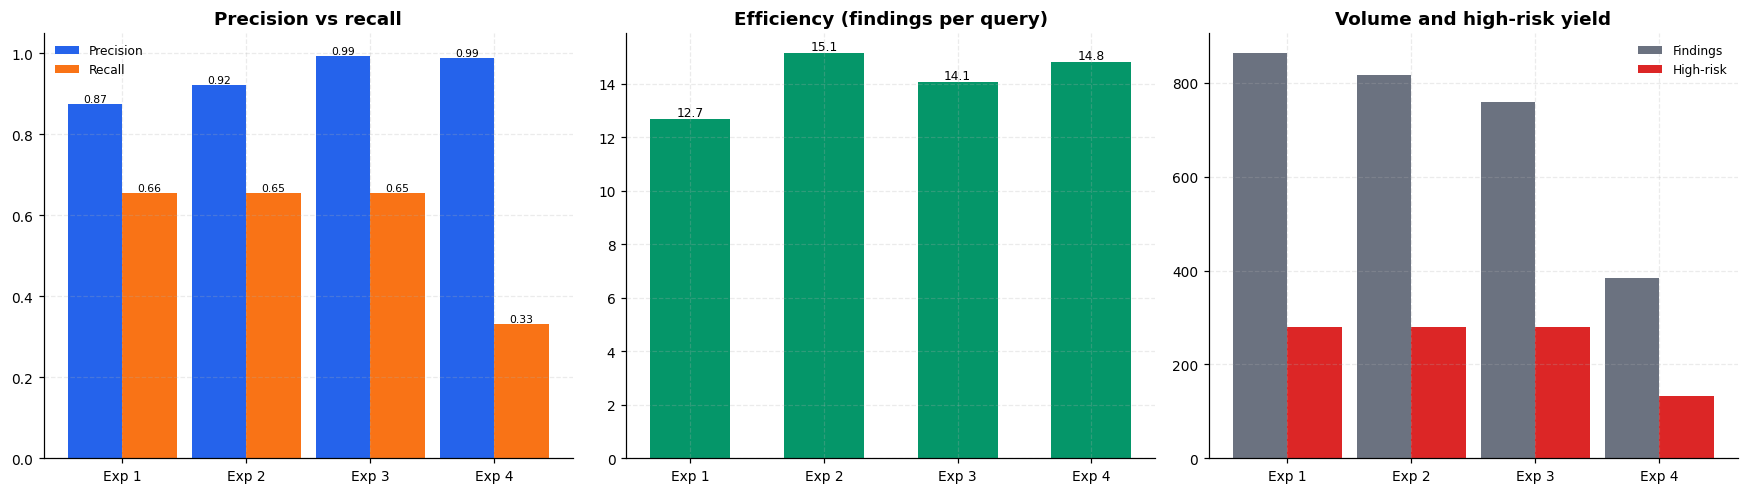

Highest F1        : 3. Tech-aware + ML finding filter  (F1 = 0.7891)
Highest efficiency: 2. Technology-aware selection  (15.13 findings/query)


In [42]:
# --- Experiment comparison figure ---------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
labels = [f"Exp {i+1}" for i in range(len(EXPERIMENTS))]
x = np.arange(len(EXPERIMENTS))

axes[0].bar(x - 0.22, experiment_df["Precision"], 0.44, label="Precision", color=ACCENT)
axes[0].bar(x + 0.22, experiment_df["Recall"], 0.44, label="Recall", color="#f97316")
axes[0].set_xticks(x); axes[0].set_xticklabels(labels)
axes[0].set_ylim(0, 1.05); axes[0].set_title("Precision vs recall")
axes[0].legend(fontsize=8)
for i, (p, r) in enumerate(zip(experiment_df["Precision"], experiment_df["Recall"])):
    axes[0].text(i - 0.22, p, f"{p:.2f}", ha="center", va="bottom", fontsize=7)
    axes[0].text(i + 0.22, r, f"{r:.2f}", ha="center", va="bottom", fontsize=7)

axes[1].bar(x, experiment_df["Findings/query"], 0.6, color="#059669")
axes[1].set_xticks(x); axes[1].set_xticklabels(labels)
axes[1].set_title("Efficiency (findings per query)")
for i, v in enumerate(experiment_df["Findings/query"]):
    axes[1].text(i, v, f"{v:.1f}", ha="center", va="bottom", fontsize=8)

axes[2].bar(x - 0.22, experiment_df["Findings"], 0.44, label="Findings", color="#6b7280")
axes[2].bar(x + 0.22, experiment_df["High-risk"], 0.44, label="High-risk", color="#dc2626")
axes[2].set_xticks(x); axes[2].set_xticklabels(labels)
axes[2].set_title("Volume and high-risk yield")
axes[2].legend(fontsize=8)

plt.tight_layout()
save_fig(fig, "08_experiment_comparison")
plt.show()

_best_f1 = experiment_df.loc[experiment_df["F1"].idxmax()]
_best_eff = experiment_df.loc[experiment_df["Findings/query"].idxmax()]
print(f"Highest F1        : {_best_f1['Method']}  (F1 = {_best_f1['F1']})")
print(f"Highest efficiency: {_best_eff['Method']}  ({_best_eff['Findings/query']} findings/query)")

## 24. Ablation Study

Which feature blocks actually carry the signal? The cumulative ablation adds one block at a time, plus two single-block references for contribution attribution:

| Configuration | Blocks |
|---|---|
| URL only | `url` |
| URL + title | `url`, `title` |
| URL + title + snippet | `url`, `title`, `snippet` |
| All metadata | `url`, `title`, `snippet`, `meta` |
| *Title only* (reference) | `title` |
| *Snippet only* (reference) | `snippet` |

### Methodology

Each configuration is a fresh `Pipeline` fit on the **training split only** and scored on **validation**. The test split is not touched — model-selection experiments belong on validation, and reporting ablation numbers on test would contaminate the headline result in Section 18.

### The prediction this tests

Section 6.3 built structural camouflage that borrows *at most two of three* search-visible fields. If that mechanism works as designed, no single field should be sufficient, and the full block set should beat every subset. A flat ablation curve would mean the corpus is trivially separable and the whole modelling exercise is decoration.

Note that the curve is **not required to be monotonic**, and it is worth watching whether it is. Adding a block adds features, and features that are frequently camouflaged can carry more noise than signal at a fixed regularisation strength. A block that *reduces* macro-F1 when added on its own, but contributes once the metadata block is present, is telling you something real about where the misleading evidence lives. The cell below reports each marginal contribution and flags any that are negative.

In [43]:
# --- Feature ablation ---------------------------------------------------------

ABLATION_CONFIGS: List[Tuple[str, Tuple[str, ...]]] = [
    ("URL only",                ("url",)),
    ("URL + title",             ("url", "title")),
    ("URL + title + snippet",   ("url", "title", "snippet")),
    ("All metadata",            ("url", "title", "snippet", "meta")),
    ("Title only (ref)",        ("title",)),
    ("Snippet only (ref)",      ("snippet",)),
]

ablation_rows = []
for label, blocks in ABLATION_CONFIGS:
    pipe = build_pipeline(CANDIDATES[BEST_MODEL_NAME], blocks)
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_val)
    n_feat = pipe.named_steps["features"].transform(X_train.head(3)).shape[1]
    ablation_rows.append({
        "configuration": label,
        "blocks": " + ".join(blocks),
        "n_features": n_feat,
        "val_accuracy": round(accuracy_score(y_val, pred), 4),
        "val_macro_f1": round(f1_score(y_val, pred, average="macro", zero_division=0), 4),
        "val_weighted_f1": round(f1_score(y_val, pred, average="weighted", zero_division=0), 4),
    })
    logger.info("Ablation %-24s macro-F1 %.4f", label, ablation_rows[-1]["val_macro_f1"])

ablation_df = pd.DataFrame(ablation_rows)

# Marginal contribution of each added block in the cumulative sequence.
cumulative = ablation_df.iloc[:4].copy()
cumulative["marginal_gain"] = cumulative["val_macro_f1"].diff().fillna(
    cumulative["val_macro_f1"].iloc[0]).round(4)

display(ablation_df)
print("\nMarginal macro-F1 contribution of each added block:\n")
for _, r in cumulative.iterrows():
    flag = "  <-- negative" if r["marginal_gain"] < 0 else ""
    print(f"  {r['configuration']:<24} {r['val_macro_f1']:.4f}   ({r['marginal_gain']:+.4f}){flag}")

_gains = cumulative.iloc[1:]
_biggest = _gains["marginal_gain"].idxmax()
print(f"\nLargest single gain: {cumulative.loc[_biggest, 'configuration']} "
      f"({cumulative.loc[_biggest, 'marginal_gain']:+.4f})")

_negative = _gains[_gains["marginal_gain"] < 0]
_full = ablation_df.iloc[3]["val_macro_f1"]
_best_subset = ablation_df.iloc[:3]["val_macro_f1"].max()

print()
if len(_negative):
    print("Non-monotonic result. Adding these blocks REDUCED validation macro-F1:")
    for _, r in _negative.iterrows():
        print(f"  {r['configuration']} ({r['marginal_gain']:+.4f})")
    print(textwrap.fill(
        "This is a real result, not a bug. The snippet is the field most often "
        "borrowed by the camouflage mechanism, so its high-dimensional bigram "
        "features carry a large share of the misleading evidence. At a fixed "
        "regularisation strength the model absorbs that noise. The block still "
        "earns its place once the metadata block is present - file type, "
        "technology, and the keyword flags give the model the anchors it needs "
        "to discount a misleading snippet - which is why the full configuration "
        "wins overall.", 78))
else:
    print("The ablation is monotonic: every added block improved validation macro-F1.")

print(f"\nFull block set : {_full:.4f}")
print(f"Best subset    : {_best_subset:.4f}")
print(f"Advantage      : {_full - _best_subset:+.4f}")
print(f"\nSingle-block references: title only {ablation_df.iloc[4]['val_macro_f1']:.4f}, "
      f"snippet only {ablation_df.iloc[5]['val_macro_f1']:.4f} "
      f"- neither field alone is sufficient, as the camouflage design intends.")

16:46:13 | INFO    | ghdb.platform          | Ablation URL only                 macro-F1 0.7269
16:46:14 | INFO    | ghdb.platform          | Ablation URL + title              macro-F1 0.7982
16:46:14 | INFO    | ghdb.platform          | Ablation URL + title + snippet    macro-F1 0.7831
16:46:16 | INFO    | ghdb.platform          | Ablation All metadata             macro-F1 0.9036
16:46:16 | INFO    | ghdb.platform          | Ablation Title only (ref)         macro-F1 0.7313
16:46:16 | INFO    | ghdb.platform          | Ablation Snippet only (ref)       macro-F1 0.7670


,configuration,blocks,n_features,val_accuracy,val_macro_f1,val_weighted_f1
0,URL only,url,216,0.7386,0.7269,0.7415
1,URL + title,url + title,829,0.8133,0.7982,0.8142
2,URL + title + snippet,url + title + snippet,2033,0.7925,0.7831,0.7918
3,All metadata,url + title + snippet + meta,2093,0.9004,0.9036,0.9007
4,Title only (ref),title,613,0.7510,0.7313,0.7557
5,Snippet only (ref),snippet,1204,0.7884,0.7670,0.7878



Marginal macro-F1 contribution of each added block:

  URL only                 0.7269   (+0.7269)
  URL + title              0.7982   (+0.0713)
  URL + title + snippet    0.7831   (-0.0151)  <-- negative
  All metadata             0.9036   (+0.1205)

Largest single gain: All metadata (+0.1205)

Non-monotonic result. Adding these blocks REDUCED validation macro-F1:
  URL + title + snippet (-0.0151)
This is a real result, not a bug. The snippet is the field most often borrowed
by the camouflage mechanism, so its high-dimensional bigram features carry a
large share of the misleading evidence. At a fixed regularisation strength the
model absorbs that noise. The block still earns its place once the metadata
block is present - file type, technology, and the keyword flags give the model
the anchors it needs to discount a misleading snippet - which is why the full
configuration wins overall.

Full block set : 0.9036
Best subset    : 0.7982
Advantage      : +0.1054

Single-block references: t

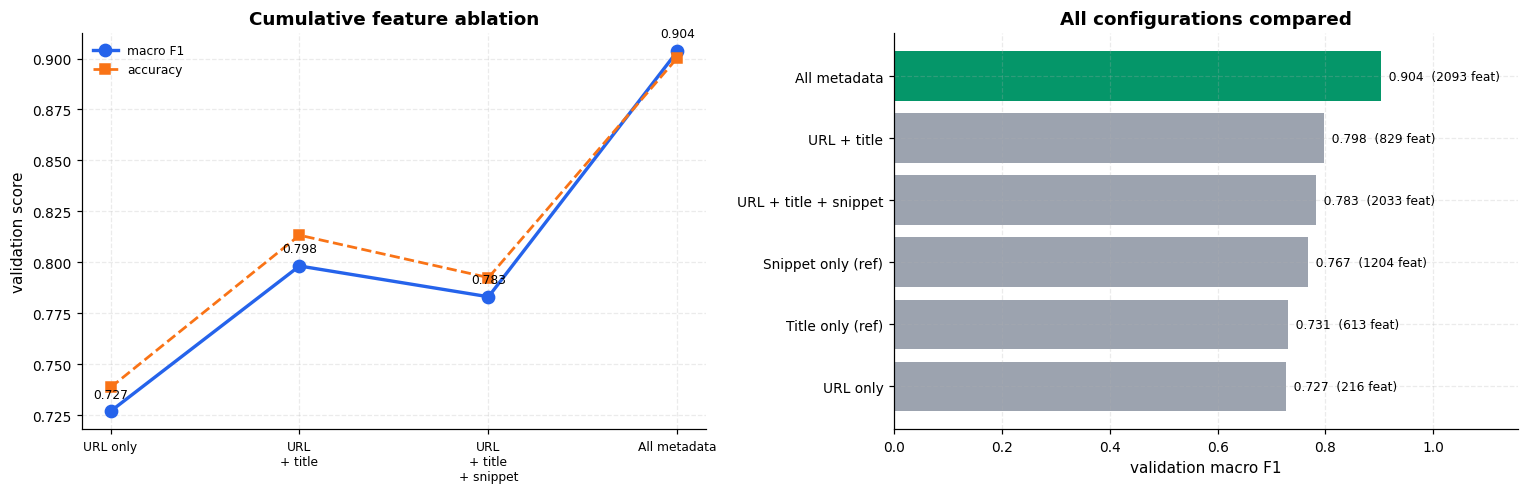

In [44]:
# --- Ablation figure ----------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))

cum = ablation_df.iloc[:4]
axes[0].plot(range(len(cum)), cum["val_macro_f1"], "o-", color=ACCENT, lw=2.2, ms=8,
             label="macro F1")
axes[0].plot(range(len(cum)), cum["val_accuracy"], "s--", color="#f97316", lw=1.8, ms=6,
             label="accuracy")
axes[0].set_xticks(range(len(cum)))
axes[0].set_xticklabels([c.replace(" + ", "\n+ ") for c in cum["configuration"]], fontsize=8)
axes[0].set_ylabel("validation score")
axes[0].set_title("Cumulative feature ablation")
axes[0].legend(fontsize=8)
for i, v in enumerate(cum["val_macro_f1"]):
    axes[0].annotate(f"{v:.3f}", (i, v), textcoords="offset points",
                     xytext=(0, 9), ha="center", fontsize=8)

ref = ablation_df.sort_values("val_macro_f1")
axes[1].barh(ref["configuration"], ref["val_macro_f1"],
             color=["#059669" if c == "All metadata" else "#9ca3af"
                    for c in ref["configuration"]])
axes[1].set_xlabel("validation macro F1")
axes[1].set_title("All configurations compared")
for i, (v, n) in enumerate(zip(ref["val_macro_f1"], ref["n_features"])):
    axes[1].text(v, i, f"  {v:.3f}  ({n} feat)", va="center", fontsize=8)
axes[1].set_xlim(0, max(ref["val_macro_f1"]) * 1.28)

plt.tight_layout()
save_fig(fig, "09_ablation_study")
plt.show()

## 25. Error Analysis

Aggregate metrics say *how much* the model is wrong. This section asks *where* and *why* — the part that determines whether the failure mode is acceptable in deployment.

Three analyses, all computed automatically from the held-out test split:

**1. Does error concentrate on camouflaged documents?** Section 6.3 built documents whose surface form was deliberately borrowed from a confusable class. If the model's mistakes cluster there at a rate well above the base rate, the errors are explained by designed ambiguity rather than by a modelling defect. This is a falsifiable prediction, and it is checked rather than assumed.

**2. False positives and false negatives in the operational binary view.** For a security tool, the asymmetry matters enormously:

- A **false positive** (benign content flagged high-severity) costs analyst time and, at volume, trains the team to ignore the tool.
- A **false negative** (a real high-severity exposure classified as benign) is a config file or database backup left publicly indexed. These are the expensive ones.

**3. Per-example explanation.** For every surfaced error, the notebook prints the true class, prediction, model confidence, camouflage metadata, and a generated diagnosis linking the mistake to the specific fields that were misleading.

In [45]:
# --- Error analysis: is error concentrated on camouflaged documents? ----------

test_doc_ids = list(X_test["doc_id"])
test_docs = [CORPUS_BY_ID[d] for d in test_doc_ids]

error_df = pd.DataFrame({
    "doc_id": test_doc_ids,
    "true_class": y_test,
    "pred_ml": y_pred_ml,
    "pred_rule": y_pred_rule,
    "ml_confidence": proba_ml.max(axis=1).round(4),
    "camouflaged_as": [d.camouflaged_as for d in test_docs],
    "camouflaged_fields": [", ".join(d.camouflaged_fields) for d in test_docs],
    "is_decoy": [d.is_decoy for d in test_docs],
    "url": [d.url for d in test_docs],
    "title": [d.title for d in test_docs],
    "snippet": [d.snippet for d in test_docs],
})
error_df["ml_correct"] = error_df["true_class"] == error_df["pred_ml"]
error_df["rule_correct"] = error_df["true_class"] == error_df["pred_rule"]
error_df["camouflaged"] = error_df["camouflaged_as"].notna()

n_err = int((~error_df["ml_correct"]).sum())
camo_base = error_df["camouflaged"].mean()
camo_in_err = error_df.loc[~error_df["ml_correct"], "camouflaged"].mean() if n_err else 0.0
camo_in_ok = error_df.loc[error_df["ml_correct"], "camouflaged"].mean()

print("=" * 74)
print("ERROR CONCENTRATION")
print("=" * 74)
print(f"Test documents                     : {len(error_df)}")
print(f"Misclassified by ML                : {n_err} ({100*n_err/len(error_df):.1f}%)")
print(f"Misclassified by rules             : {int((~error_df['rule_correct']).sum())}")
print()
print(f"Camouflage base rate (all test)    : {camo_base:.3f}")
print(f"Camouflage rate among ML errors    : {camo_in_err:.3f}")
print(f"Camouflage rate among ML successes : {camo_in_ok:.3f}")
_lift = (camo_in_err / camo_base) if camo_base else float("nan")
print(f"Lift                               : {_lift:.2f}x")
print()
if _lift > 1.3:
    print("=> Errors concentrate on structurally camouflaged documents, as designed.")
    print("   The residual error is dominated by engineered ambiguity rather than by")
    print("   a deficiency in the feature representation.")
else:
    print("=> Errors are NOT concentrated on camouflaged documents. The residual error")
    print("   is not explained by the ambiguity mechanism and warrants investigation.")

_mean_conf_err = error_df.loc[~error_df["ml_correct"], "ml_confidence"].mean() if n_err else 0.0
print(f"\nMean model confidence when correct : {error_df.loc[error_df['ml_correct'], 'ml_confidence'].mean():.3f}")
print(f"Mean model confidence when wrong   : {_mean_conf_err:.3f}")
print("(A meaningful gap means confidence is usable as a triage signal.)")

ERROR CONCENTRATION
Test documents                     : 240
Misclassified by ML                : 27 (11.2%)
Misclassified by rules             : 72

Camouflage base rate (all test)    : 0.400
Camouflage rate among ML errors    : 0.963
Camouflage rate among ML successes : 0.329
Lift                               : 2.41x

=> Errors concentrate on structurally camouflaged documents, as designed.
   The residual error is dominated by engineered ambiguity rather than by
   a deficiency in the feature representation.

Mean model confidence when correct : 0.936
Mean model confidence when wrong   : 0.743
(A meaningful gap means confidence is usable as a triage signal.)


In [46]:
# --- False positives and false negatives in the high-severity binary view -----

error_df["true_high"] = error_df["true_class"].isin(HIGH_SEVERITY_CLASSES)
error_df["pred_high"] = error_df["pred_ml"].isin(HIGH_SEVERITY_CLASSES)

false_positives = error_df[(~error_df["true_high"]) & error_df["pred_high"]]
false_negatives = error_df[error_df["true_high"] & (~error_df["pred_high"])]

print(f"High-severity detection on the test split")
print(f"  True positives : {int((error_df['true_high'] & error_df['pred_high']).sum())}")
print(f"  False positives: {len(false_positives)}")
print(f"  False negatives: {len(false_negatives)}")
print(f"  True negatives : {int(((~error_df['true_high']) & (~error_df['pred_high'])).sum())}")


def diagnose(row: pd.Series) -> str:
    """Generate a plain-language diagnosis for a single misclassification."""
    reasons: List[str] = []
    if pd.notna(row["camouflaged_as"]):
        fields = row["camouflaged_fields"] or "unspecified fields"
        reasons.append(
            f"its {fields} were drawn from the '{row['camouflaged_as']}' class, so the "
            f"strongest lexical evidence points away from the true label")
        if row["camouflaged_as"] == row["pred_ml"]:
            reasons.append("the model predicted exactly the camouflage class, meaning the "
                           "borrowed surface form dominated the residual true-class signal")
    if row["is_decoy"]:
        reasons.append("cross-class decoy vocabulary was injected into the title or snippet")
    if row["ml_confidence"] < 0.55:
        reasons.append(f"the model was itself unconfident ({row['ml_confidence']:.2f}), so "
                       f"the error would be caught by a confidence threshold")
    elif row["ml_confidence"] > 0.85:
        reasons.append(f"the model was confidently wrong ({row['ml_confidence']:.2f}), which "
                       f"is the more costly failure mode")
    if not reasons:
        reasons.append("no camouflage or decoy was applied; the error reflects genuine "
                       "vocabulary overlap between the two classes")
    return "; ".join(reasons)


def show_examples(frame: pd.DataFrame, heading: str, limit: int = 4) -> None:
    print("\n" + "=" * 92)
    print(heading)
    print("=" * 92)
    if frame.empty:
        print("  None on the held-out test split.")
        return
    for _, r in frame.head(limit).iterrows():
        print(f"\n  {r['doc_id']}   true={r['true_class']}   predicted={r['pred_ml']}   "
              f"conf={r['ml_confidence']:.3f}")
        print(f"    URL     : {r['url']}")
        print(f"    Title   : {textwrap.shorten(r['title'], 88)}")
        print(f"    Snippet : {textwrap.shorten(r['snippet'], 88)}")
        print(f"    Camouflage: {r['camouflaged_as'] or 'none'}"
              + (f" (fields: {r['camouflaged_fields']})" if r['camouflaged_as'] else ""))
        print("    Why      : " + textwrap.fill(diagnose(r), 84,
                                                subsequent_indent=" " * 15))


show_examples(false_positives.sort_values("ml_confidence", ascending=False),
              "FALSE POSITIVES - benign or low-severity content flagged high-severity")
show_examples(false_negatives.sort_values("ml_confidence", ascending=False),
              "FALSE NEGATIVES - genuine high-severity exposure missed (the costly errors)")

High-severity detection on the test split
  True positives : 55
  False positives: 11
  False negatives: 2
  True negatives : 172

FALSE POSITIVES - benign or low-severity content flagged high-severity

  DOC-00160   true=dev_environment   predicted=debug_page   conf=0.924
    URL     : http://dev.acme.local/ci/build/31
    Title   : Application error trace #33
    Snippet : Stack trace for request /Integrity: NoneType object has no attribute Integrity.
    Camouflage: debug_page (fields: title, snippet)
    Why      : its title, snippet were drawn from the 'debug_page' class, so the strongest lexical
               evidence points away from the true label; the model predicted exactly
               the camouflage class, meaning the borrowed surface form dominated the
               residual true-class signal; the model was confidently wrong (0.92),
               which is the more costly failure mode

  DOC-01414   true=legacy_application   predicted=admin_interface   conf=0.863
    U

In [47]:
# --- Where the two models disagree --------------------------------------------

disagree = error_df[error_df["ml_correct"] != error_df["rule_correct"]]
ml_wins = disagree[disagree["ml_correct"]]
rule_wins = disagree[disagree["rule_correct"]]

print(f"Documents where exactly one model is right: {len(disagree)}")
print(f"  ML correct, rules wrong : {len(ml_wins)}")
print(f"  Rules correct, ML wrong : {len(rule_wins)}")
print(f"  Net advantage to ML     : {len(ml_wins) - len(rule_wins)}")

if len(ml_wins):
    print(f"\nCamouflage rate where ML wins   : {ml_wins['camouflaged'].mean():.3f}")
if len(rule_wins):
    print(f"Camouflage rate where rules win : {rule_wins['camouflaged'].mean():.3f}")

_pairs = Counter(zip(disagree["true_class"], disagree["pred_rule"]))
print("\nMost common rule-baseline failures that the ML model corrects:")
for (true_c, pred_c), n in Counter(
        zip(ml_wins["true_class"], ml_wins["pred_rule"])).most_common(6):
    print(f"  {n:>3}x  {true_c:<22} misread as {pred_c}")

print("\nInterpretation: the rule baseline is first-match-wins, so a single borrowed")
print("keyword in a camouflaged field is enough to capture it. The linear model")
print("weighs evidence across all three fields simultaneously, which is precisely")
print("the advantage the ambiguity mechanism was constructed to expose.")

Documents where exactly one model is right: 51
  ML correct, rules wrong : 48
  Rules correct, ML wrong : 3
  Net advantage to ML     : 45

Camouflage rate where ML wins   : 0.688
Camouflage rate where rules win : 0.667

Most common rule-baseline failures that the ML model corrects:
   11x  benign_content         misread as staging_environment
    6x  dev_environment        misread as staging_environment
    4x  benign_content         misread as exposed_document
    3x  exposed_document       misread as legacy_application
    3x  benign_content         misread as api_documentation
    2x  staging_environment    misread as debug_page

Interpretation: the rule baseline is first-match-wins, so a single borrowed
keyword in a camouflaged field is enough to capture it. The linear model
weighs evidence across all three fields simultaneously, which is precisely
the advantage the ambiguity mechanism was constructed to expose.


## 26. Security Report

The report is written to `reports/security_assessment.html` as a self-contained document — no external CSS, fonts, or scripts — so it can be attached to an email or archived without breaking.

### Structure

Executive Summary · Scope · Methodology · Attack Surface · Findings · Risk Summary · Query Effectiveness · ML Performance · Limitations · Recommendations

Every number in it is pulled from the objects computed above. Nothing is hard-coded, and re-running the notebook with a different seed produces a report with different numbers rather than the same numbers attached to different data.

### Scope statement

The report leads with, and repeats in its Limitations section, an explicit statement that the assessment was conducted against a controlled synthetic environment generated by the notebook, and that no third-party system was contacted. A report that could be mistaken for a real-world assessment of a real organisation would be a serious problem, so the disclosure is prominent rather than buried in a footer.

### Data exports

Alongside the HTML: `findings.csv`, `findings.json`, `risk_summary.csv`, `query_metrics.csv`, plus `experiments.csv`, `ml_metrics.json`, and `ground_truth.json` for downstream analysis.

In [48]:
# --- HTML security report generator -------------------------------------------

class ReportGenerator:
    """Renders a self-contained HTML assessment report and data exports."""

    CSS = """
    :root{--ink:#111827;--muted:#6b7280;--line:#e5e7eb;--accent:#2563eb;--bg:#f9fafb}
    *{box-sizing:border-box}
    body{font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,Helvetica,Arial,sans-serif;
         color:var(--ink);margin:0;padding:0;background:var(--bg);line-height:1.6}
    .wrap{max-width:1100px;margin:0 auto;padding:0 28px 72px}
    header{background:linear-gradient(135deg,#111827,#1f2937);color:#fff;padding:44px 28px}
    header .inner{max-width:1100px;margin:0 auto}
    header h1{margin:0 0 6px;font-size:27px;letter-spacing:-.4px}
    header .sub{color:#cbd5e1;font-size:14px}
    .banner{background:#fef3c7;border-left:5px solid #d97706;padding:14px 18px;margin:22px 0;
            border-radius:0 6px 6px 0;font-size:14px}
    h2{font-size:19px;margin:38px 0 12px;padding-bottom:7px;border-bottom:2px solid var(--line)}
    h3{font-size:15px;margin:22px 0 8px}
    table{border-collapse:collapse;width:100%;margin:14px 0;font-size:13px;background:#fff;
          border-radius:6px;overflow:hidden;box-shadow:0 1px 2px rgba(0,0,0,.06)}
    th{background:#f3f4f6;text-align:left;padding:9px 11px;font-weight:600;
       border-bottom:2px solid var(--line);white-space:nowrap}
    td{padding:8px 11px;border-bottom:1px solid var(--line);vertical-align:top}
    tr:last-child td{border-bottom:none}
    .cards{display:flex;gap:14px;flex-wrap:wrap;margin:18px 0}
    .card{flex:1;min-width:150px;background:#fff;border:1px solid var(--line);
          border-radius:8px;padding:15px 17px}
    .card .n{font-size:26px;font-weight:700;letter-spacing:-.5px}
    .card .l{font-size:11px;color:var(--muted);text-transform:uppercase;letter-spacing:.6px}
    .sev{display:inline-block;padding:2px 9px;border-radius:11px;color:#fff;
         font-size:11px;font-weight:600;white-space:nowrap}
    .finding{background:#fff;border:1px solid var(--line);border-radius:8px;
             padding:17px 19px;margin:13px 0}
    .finding h4{margin:0 0 9px;font-size:14.5px}
    .finding dl{display:grid;grid-template-columns:150px 1fr;gap:5px 14px;
                margin:0;font-size:13px}
    .finding dt{color:var(--muted);font-weight:600}
    .finding dd{margin:0}
    code{background:#f3f4f6;padding:1.5px 5px;border-radius:3px;font-size:12px;
         font-family:ui-monospace,SFMono-Regular,Menlo,monospace;word-break:break-all}
    footer{margin-top:44px;padding-top:18px;border-top:1px solid var(--line);
           font-size:12px;color:var(--muted)}
    ul{margin:8px 0;padding-left:22px} li{margin:5px 0}
    """

    def __init__(self, org: str, findings: Sequence[Finding]) -> None:
        self.org = org
        self.findings = list(findings)
        self.generated = datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M UTC")

    # -- helpers ------------------------------------------------------------
    @staticmethod
    def _e(text: Any) -> str:
        return html.escape(str(text))

    @staticmethod
    def _sev_badge(sev: str) -> str:
        return (f'<span class="sev" style="background:{SEVERITY_COLORS.get(sev, "#6b7280")}">'
                f'{html.escape(sev)}</span>')

    def _table(self, df: pd.DataFrame, max_rows: int = 40) -> str:
        head = "".join(f"<th>{self._e(c)}</th>" for c in df.columns)
        body = "".join(
            "<tr>" + "".join(f"<td>{self._e(v)}</td>" for v in row) + "</tr>"
            for row in df.head(max_rows).itertuples(index=False))
        return f"<table><thead><tr>{head}</tr></thead><tbody>{body}</tbody></table>"

    def _cards(self) -> str:
        by_sev = Counter(f.severity for f in self.findings)
        items = [
            ("Findings", len(self.findings), "#111827"),
            ("Assets", len({f.asset for f in self.findings}), "#2563eb"),
            ("Critical", by_sev.get("Critical", 0), SEVERITY_COLORS["Critical"]),
            ("High", by_sev.get("High", 0), SEVERITY_COLORS["High"]),
            ("Medium", by_sev.get("Medium", 0), SEVERITY_COLORS["Medium"]),
            ("Queries run", recon_run.n_queries, "#059669"),
        ]
        return ('<div class="cards">' + "".join(
            f'<div class="card"><div class="n" style="color:{c}">{v}</div>'
            f'<div class="l">{self._e(l)}</div></div>' for l, v, c in items) + "</div>")

    def _finding_block(self, f: Finding) -> str:
        rows = [
            ("Severity", f"{self._sev_badge(f.severity or 'Informational')} "
                         f"&nbsp;risk score {f.risk_score}"),
            ("Confidence", f"{f.predicted_confidence:.3f}"
                           if f.predicted_confidence else "n/a"),
            ("Affected asset", f"<code>{self._e(f.asset)}</code> "
                               f"(criticality {ASSET_LOOKUP[f.asset].criticality:.2f})"),
            ("Location", f"<code>{self._e(f.url)}</code>"),
            ("Exposure class", self._e((f.predicted_class or '').replace('_', ' '))),
            ("Technology", self._e(f.technology)),
            ("Discovery method", f"GHDB <code>{self._e(f.primary_query_id)}</code> &mdash; "
                                 f"<code>{self._e(f.primary_query)}</code> "
                                 f"(rank {f.best_rank}, "
                                 f"{len(f.discovered_by)} corroborating quer"
                                 f"{'y' if len(f.discovered_by) == 1 else 'ies'})"),
            ("Evidence", f"<code>{self._e(f.evidence)}</code>"),
            ("Risk explanation", self._e(f.explanation)),
            ("Remediation", self._e(f.remediation)),
        ]
        dl = "".join(f"<dt>{k}</dt><dd>{v}</dd>" for k, v in rows)
        return (f'<div class="finding"><h4>{self._e(f.finding_id)} &mdash; '
                f'{self._e((f.predicted_class or "").replace("_", " ").title())} on '
                f'{self._e(f.asset)}</h4><dl>{dl}</dl></div>')

    # -- report --------------------------------------------------------------
    def render(self, *, summary: str, assets: pd.DataFrame, risk_summary: pd.DataFrame,
               query_metrics: pd.DataFrame, ml_results: pd.DataFrame,
               experiments: pd.DataFrame, detection: DetectionMetrics,
               graph_metrics: Dict[str, Any], top_n: int = 15) -> str:
        by_sev = Counter(f.severity for f in self.findings)
        ranked = sorted(self.findings, key=lambda f: -(f.risk_score or 0))
        priority = [f for f in ranked if f.severity in ("Critical", "High")][:top_n] or ranked[:top_n]

        parts: List[str] = []
        parts.append(f"""<!DOCTYPE html><html lang="en"><head><meta charset="utf-8">
<meta name="viewport" content="width=device-width,initial-scale=1">
<title>Attack Surface Assessment &mdash; {self._e(self.org)}</title>
<style>{self.CSS}</style></head><body>
<header><div class="inner">
<h1>Search-Engine Attack Surface Assessment</h1>
<div class="sub">{self._e(self.org)} &nbsp;&middot;&nbsp; GHDB reconnaissance, ML triage,
and risk prioritisation &nbsp;&middot;&nbsp; generated {self._e(self.generated)}</div>
</div></header><div class="wrap">""")

        parts.append(f"""<div class="banner"><strong>Controlled synthetic environment.</strong>
This assessment was conducted entirely against a synthetic target generated by the
originating notebook. {self._e(self.org)} is a fictional organisation and its
<code>*.acme.local</code> hosts are non-resolvable. No third-party system was contacted,
scanned, or queried. All credential-shaped values are non-functional placeholders.
This report is a demonstration of methodology and must not be read as an assessment of
any real organisation.</div>""")

        parts.append("<h2>Executive Summary</h2>")
        parts.append(self._cards())
        parts.append(f"<p>{self._e(summary)}</p>")

        parts.append(f"""<h2>Scope</h2>
<ul>
<li><strong>Target:</strong> {self._e(self.org)} (<code>{self._e(CONFIG['ORG_DOMAIN'])}</code>)
and all discovered subdomains &mdash; a synthetic environment.</li>
<li><strong>Technique:</strong> passive search-engine reconnaissance using GHDB-style
queries. No active scanning, probing, authentication, or exploitation.</li>
<li><strong>Search backend:</strong> <code>{self._e(SEARCH_BACKEND.name)}</code>
({len(CORPUS)} indexed documents).</li>
<li><strong>Assets in scope:</strong> {len(DISCOVERED_ASSETS)} hosts.</li>
<li><strong>Queries executed:</strong> {recon_run.n_queries} of
{len(GHDB_CATALOG)} catalog entries ({self._e(recon_run.strategy)} selection).</li>
<li><strong>Out of scope:</strong> exploitation, credential testing, denial of service,
social engineering, physical access, and any system outside the synthetic environment.</li>
</ul>""")

        parts.append(f"""<h2>Methodology</h2>
<ol>
<li><strong>Asset discovery</strong> &mdash; host extraction from the search index.</li>
<li><strong>Technology fingerprinting</strong> &mdash; passive signature matching against
indexed content, {len(ESTATE_TECH)} technologies identified.</li>
<li><strong>Query selection</strong> &mdash; {self._e(recon_run.strategy)} selection from a
{len(GHDB_CATALOG)}-entry GHDB-style catalog.</li>
<li><strong>Reconnaissance</strong> &mdash; queries dispatched to the search backend, capped
at {CONFIG['RESULTS_PER_QUERY']} results each.</li>
<li><strong>Finding extraction</strong> &mdash; URL deduplication, provenance tracking, and
grouping.</li>
<li><strong>Classification</strong> &mdash; {self._e(BEST_MODEL_NAME)} over URL, title,
snippet, and metadata features.</li>
<li><strong>Risk scoring</strong> &mdash; seven-factor weighted geometric model normalised
to 0&ndash;100.</li>
<li><strong>Graph analysis</strong> &mdash; typed attack-surface graph
({graph_metrics['nodes']} nodes, {graph_metrics['edges']} edges).</li>
</ol>""")

        parts.append("<h2>Attack Surface</h2>")
        parts.append(self._table(assets))
        parts.append(f"""<p>Detection performance against the environment's known ground
truth: <strong>{detection.recall:.1%} of all exposures detected</strong>
(precision {detection.precision:.1%}, false-negative rate
{detection.false_negative_rate:.1%}, class coverage {detection.coverage:.0%}).</p>""")

        parts.append(f"<h2>Findings</h2><p>{len(self.findings)} distinct exposures. "
                     f"The {len(priority)} highest-risk are detailed below; the complete "
                     f"set is exported to <code>findings.csv</code> and "
                     f"<code>findings.json</code>.</p>")
        parts.extend(self._finding_block(f) for f in priority)

        parts.append("<h2>Risk Summary</h2>")
        parts.append(self._table(risk_summary))
        parts.append("<p>Severity bands: Informational 0&ndash;24, Low 25&ndash;49, "
                     "Medium 50&ndash;74, High 75&ndash;89, Critical 90&ndash;100. "
                     "Scores are the weighted geometric mean of exposure severity, asset "
                     "criticality, detection confidence, information sensitivity, "
                     "exploitability, public discoverability, and authentication status.</p>")

        parts.append("<h2>Query Effectiveness</h2>")
        parts.append(self._table(query_metrics))
        parts.append("<h3>Reconnaissance strategy comparison</h3>")
        parts.append(self._table(experiments))

        parts.append("<h2>Machine Learning Performance</h2>")
        parts.append(self._table(ml_results))
        parts.append(f"""<p>Evaluated on a held-out stratified test split
({len(y_test)} documents, 15% of the corpus) that was not used for training or model
selection. 5-fold cross-validated macro-F1 on the training split:
{CV_MEAN_F1:.4f} &plusmn; {CV_STD_F1:.4f}. High-severity detection ROC-AUC
{ROC_AUC[BEST_MODEL_NAME]:.4f}, PR-AUC {PR_AUC[BEST_MODEL_NAME]:.4f}.</p>""")

        parts.append(f"""<h2>Limitations</h2>
<ul>
<li>The target is a <strong>synthetic environment</strong> generated by the originating
notebook. Absolute metric values characterise this corpus and do not transfer to real
estates.</li>
<li>The search backend is a deterministic local index. Real search engines rank
differently, index partially, and change over time.</li>
<li>Recall is bounded by the {CONFIG['RESULTS_PER_QUERY']}-result cap per query and by
the {len(GHDB_CATALOG)}-entry catalog.</li>
<li>Ground-truth sensitivity and exploitability values are known here; in a real
deployment the risk model falls back to class-level priors.</li>
<li>The rarest class contributes roughly a dozen documents per held-out split, so
per-class metrics for those classes carry wide confidence intervals.</li>
<li>Findings were not validated by retrieval or manual inspection of the target, which
is what a real engagement would require before reporting.</li>
</ul>""")

        crit_high = by_sev.get("Critical", 0) + by_sev.get("High", 0)
        parts.append(f"""<h2>Recommendations</h2>
<ol>
<li><strong>Remediate the {crit_high} High and Critical findings first</strong>,
prioritising configuration and backup artefacts, where a single retrieval can disclose
credentials or bulk data.</li>
<li><strong>Disable directory indexing</strong> estate-wide and add a configuration check
that fails deployment when autoindex is enabled on a public virtual host.</li>
<li><strong>Remove non-production hosts from public DNS and the search index.</strong>
Development and staging environments should not be externally resolvable by default.</li>
<li><strong>Add a CI gate</strong> that blocks builds shipping configuration files,
archives, or debug settings into a publicly served directory.</li>
<li><strong>Run this sweep continuously.</strong> Exposure is created by ordinary
deployment activity; a point-in-time assessment goes stale within weeks.</li>
<li><strong>Request cache removal</strong> from search providers for every remediated
exposure &mdash; deleting the file does not remove it from the index.</li>
</ol>""")

        parts.append(f"""<footer>Generated {self._e(self.generated)} by the AI-Powered GHDB
Attack Surface Intelligence Platform. Seed {SEED}; search mode
<code>{self._e(CONFIG['SEARCH_MODE'])}</code>; LLM analysis
{'enabled' if CONFIG['USE_LLM'] else 'disabled (deterministic templates)'}.
Synthetic environment &mdash; not an assessment of any real organisation.
</footer></div></body></html>""")

        return "".join(parts)


print("ReportGenerator defined.")

ReportGenerator defined.


In [49]:
# --- Build the risk summary, render the report, and export the data -----------

risk_summary_df = (findings_df.groupby(["severity"])
                   .agg(findings=("finding_id", "count"),
                        assets=("asset", "nunique"),
                        mean_risk=("risk_score", "mean"),
                        max_risk=("risk_score", "max"))
                   .reindex(SEVERITY_ORDER).fillna(0).reset_index())
risk_summary_df["mean_risk"] = risk_summary_df["mean_risk"].round(2)
risk_summary_df["findings"] = risk_summary_df["findings"].astype(int)
risk_summary_df["assets"] = risk_summary_df["assets"].astype(int)

report = ReportGenerator(CONFIG["ORG_NAME"], FINDINGS)
html_report = report.render(
    summary=ANALYST_SUMMARY,
    assets=assets_df,
    risk_summary=risk_summary_df,
    query_metrics=category_metrics_df,
    ml_results=TEST_RESULTS,
    experiments=experiment_df,
    detection=primary_metrics,
    graph_metrics=GRAPH_METRICS,
)

report_path = PATHS["reports"] / "security_assessment.html"
report_path.write_text(html_report, encoding="utf-8")

# --- Data exports -------------------------------------------------------------
findings_export = findings_df.copy()
findings_export["discovered_by"] = [", ".join(f.discovered_by) for f in FINDINGS]
findings_export["remediation"] = [f.remediation for f in FINDINGS]
findings_export["explanation"] = [f.explanation for f in FINDINGS]

exports: Dict[str, Path] = {}
exports["findings.csv"] = PATHS["results"] / "findings.csv"
findings_export.to_csv(exports["findings.csv"], index=False)

exports["findings.json"] = PATHS["results"] / "findings.json"
exports["findings.json"].write_text(json.dumps([{
    **{k: v for k, v in asdict(f).items() if k not in ("risk_factors",)},
    "risk_factors": f.risk_factors,
} for f in FINDINGS], indent=2, default=str), encoding="utf-8")

exports["risk_summary.csv"] = PATHS["results"] / "risk_summary.csv"
risk_summary_df.to_csv(exports["risk_summary.csv"], index=False)

exports["query_metrics.csv"] = PATHS["results"] / "query_metrics.csv"
query_metrics_df.to_csv(exports["query_metrics.csv"], index=False)

exports["experiments.csv"] = PATHS["results"] / "experiments.csv"
experiment_df.to_csv(exports["experiments.csv"], index=False)

exports["ablation.csv"] = PATHS["results"] / "ablation.csv"
ablation_df.to_csv(exports["ablation.csv"], index=False)

exports["ml_metrics.json"] = PATHS["results"] / "ml_metrics.json"
exports["ml_metrics.json"].write_text(json.dumps({
    "selected_model": BEST_MODEL_NAME,
    "test_results": TEST_RESULTS.to_dict(orient="records"),
    "cv_macro_f1_mean": round(CV_MEAN_F1, 4),
    "cv_macro_f1_std": round(CV_STD_F1, 4),
    "roc_auc_high_severity": {k: round(v, 4) for k, v in ROC_AUC.items()},
    "pr_auc_high_severity": {k: round(v, 4) for k, v in PR_AUC.items()},
    "hardest_classes": HARDEST_CLASSES,
    "top_confusions": [{"true": t, "predicted": p, "count": n} for t, p, n in TOP_CONFUSIONS],
    "split_sizes": {"train": len(y_train), "val": len(y_val), "test": len(y_test)},
}, indent=2), encoding="utf-8")

exports["ground_truth.json"] = PATHS["results"] / "ground_truth.json"
exports["ground_truth.json"].write_text(json.dumps({
    "categories_present": GROUND_TRUTH_CATEGORIES,
    "instance_counts": GROUND_TRUTH_COUNTS,
    "total_exposures": len(ALL_EXPOSURE_DOC_IDS),
    "total_benign": len(BENIGN_DOC_IDS),
    "detection": asdict(primary_metrics),
}, indent=2), encoding="utf-8")

exports["corpus.csv"] = PATHS["data"] / "corpus.csv"
corpus_df.to_csv(exports["corpus.csv"], index=False)

print(f"Report written : {report_path}  ({len(html_report):,} bytes)\n")
print("Data exports:")
for name, path in exports.items():
    print(f"  {name:<22} {path.stat().st_size:>10,} bytes")

# Render the report inline in Colab.
try:
    from IPython.display import IFrame, HTML as IPyHTML
    display(IPyHTML(f'<a href="{report_path}" target="_blank">Open the full HTML report</a>'))
except Exception:
    pass

Report written : /content/ghdb_project/reports/security_assessment.html  (40,787 bytes)

Data exports:
  findings.csv              939,382 bytes
  findings.json           1,688,250 bytes
  risk_summary.csv              167 bytes
  query_metrics.csv           5,923 bytes
  experiments.csv               412 bytes
  ablation.csv                  398 bytes
  ml_metrics.json             1,907 bytes
  ground_truth.json             971 bytes
  corpus.csv                657,037 bytes


## 27. Gradio Dashboard

An interactive triage surface over the same objects the report uses. It runs entirely locally and requires no LLM.

| Tab | Contents |
|---|---|
| **Run Recon** | Choose a selection strategy, execute a sweep, see live counts and ground-truth metrics |
| **Findings** | Filter by severity, asset, exposure class, technology, and minimum confidence |
| **Finding Detail** | Full record for a selected finding: severity, confidence, asset, evidence, discovery query, explanation, remediation |
| **Attack Surface** | Per-asset roll-up and the rendered graph |
| **Statistics** | Assets, queries, findings, high-risk count, technologies, exposure classes, query effectiveness |

`CONFIG["LAUNCH_DASHBOARD"]` is `False` by default so a top-to-bottom run completes without blocking on a server. Set it to `True` (and re-run the launch cell) to start it; in Colab, Gradio returns a proxied URL automatically.

If `gradio` is not installed the section reports that cleanly and the notebook continues — nothing else depends on it.

In [50]:
# --- Gradio dashboard ---------------------------------------------------------

def build_dashboard():
    """Construct the Gradio interface. Returns None when gradio is unavailable."""
    if not GRADIO_AVAILABLE:
        logger.warning("gradio not installed; dashboard unavailable.")
        return None

    import gradio as gr

    severities = ["All"] + SEVERITY_ORDER
    assets_opt = ["All"] + sorted({f.asset for f in FINDINGS})
    classes_opt = ["All"] + sorted({f.predicted_class for f in FINDINGS if f.predicted_class})
    techs_opt = ["All"] + sorted({f.technology for f in FINDINGS})

    def run_recon(strategy: str, results_cap: int, use_ml_filter: bool):
        queries = query_engine.select(strategy)
        engine = ReconEngine(SEARCH_BACKEND, CONFIG["ORG_DOMAIN"], int(results_cap))
        run = engine.run(queries, strategy=strategy)
        found = extractor.extract(run)

        if use_ml_filter and found:
            recs = pd.DataFrame([build_record(f.url, f.title, f.snippet, f.file_type,
                                              f.technology, doc_id=f.doc_id) for f in found])
            preds = FINAL_MODEL.predict(recs)
            probas = FINAL_MODEL.predict_proba(recs)
            keep = []
            for f, p, pr in zip(found, preds, probas):
                f.predicted_class = p
                f.predicted_confidence = round(float(pr.max()), 4)
                if p != "benign_content":
                    keep.append(f)
            found = keep

        risk_scorer.apply(found)
        m = evaluator.score({f.doc_id for f in found})
        by_sev = Counter(f.severity for f in found)

        summary = (
            f"### Reconnaissance complete\n\n"
            f"| Metric | Value |\n|---|---|\n"
            f"| Strategy | `{strategy}` |\n"
            f"| Queries executed | {len(queries)} |\n"
            f"| Raw results | {run.n_results} |\n"
            f"| Unique findings | {len(found)} |\n"
            f"| Critical / High | {by_sev.get('Critical',0)} / {by_sev.get('High',0)} |\n"
            f"| Precision (ground truth) | {m.precision:.3f} |\n"
            f"| Recall (ground truth) | {m.recall:.3f} |\n"
            f"| Class coverage | {m.coverage:.0%} |\n"
        )
        table = pd.DataFrame([{
            "Finding": f.finding_id, "Severity": f.severity, "Risk": f.risk_score,
            "Asset": f.asset, "Class": f.predicted_class, "URL": f.url,
        } for f in sorted(found, key=lambda x: -(x.risk_score or 0))[:200]])
        return summary, table

    def filter_findings(sev: str, asset: str, cls: str, tech: str, min_conf: float):
        rows = []
        for f in sorted(FINDINGS, key=lambda x: -(x.risk_score or 0)):
            if sev != "All" and f.severity != sev:
                continue
            if asset != "All" and f.asset != asset:
                continue
            if cls != "All" and f.predicted_class != cls:
                continue
            if tech != "All" and f.technology != tech:
                continue
            if (f.predicted_confidence or 0) < min_conf:
                continue
            rows.append({"Finding": f.finding_id, "Severity": f.severity,
                         "Risk": f.risk_score,
                         "Confidence": round(f.predicted_confidence or 0, 3),
                         "Asset": f.asset, "Class": f.predicted_class,
                         "Query": f.primary_query_id, "URL": f.url})
        df = pd.DataFrame(rows)
        return df, f"**{len(rows)}** findings match the current filters."

    def finding_detail(finding_id: str):
        f = next((x for x in FINDINGS if x.finding_id == finding_id.strip()), None)
        if f is None:
            return f"No finding with ID `{finding_id}`. Try one from the Findings tab."
        factors = "\n".join(f"| {k.replace('_', ' ')} | {v:.3f} | {RISK_WEIGHTS[k]:.2f} |"
                            for k, v in (f.risk_factors or {}).items())
        return (
            f"## {f.finding_id} &mdash; {(f.predicted_class or '').replace('_',' ').title()}\n\n"
            f"**Severity:** {f.severity} (risk {f.risk_score}/100) &nbsp;|&nbsp; "
            f"**Confidence:** {f.predicted_confidence:.3f}\n\n"
            f"**Asset:** `{f.asset}` &nbsp;|&nbsp; **Technology:** {f.technology} "
            f"&nbsp;|&nbsp; **File type:** {f.file_type}\n\n"
            f"**Location:** `{f.url}`\n\n"
            f"**Evidence:** `{f.evidence}`\n\n"
            f"**Discovery query:** `{f.primary_query}` ({f.primary_query_id}, "
            f"rank {f.best_rank}, {len(f.discovered_by)} corroborating queries: "
            f"{', '.join(f.discovered_by)})\n\n"
            f"### Risk factor breakdown\n\n| Factor | Value | Weight |\n|---|---|---|\n{factors}\n\n"
            f"### Explanation\n\n{f.explanation}\n\n"
            f"### Remediation\n\n{f.remediation}\n"
        )

    stats_md = (
        f"## Assessment statistics\n\n"
        f"| Metric | Value |\n|---|---|\n"
        f"| Organisation | {CONFIG['ORG_NAME']} |\n"
        f"| Assets discovered | {len(DISCOVERED_ASSETS)} |\n"
        f"| Indexed documents | {len(CORPUS)} |\n"
        f"| GHDB catalog size | {len(GHDB_CATALOG)} |\n"
        f"| Queries executed | {recon_run.n_queries} |\n"
        f"| Findings discovered | {len(FINDINGS)} |\n"
        f"| High-risk findings | {sum(1 for f in FINDINGS if f.severity in ('High','Critical'))} |\n"
        f"| Technologies identified | {len(ESTATE_TECH)} |\n"
        f"| Exposure categories | {len(GROUND_TRUTH_CATEGORIES)} |\n"
        f"| Detection recall | {primary_metrics.recall:.3f} |\n"
        f"| Detection precision | {primary_metrics.precision:.3f} |\n"
        f"| Classifier | {BEST_MODEL_NAME} |\n"
        f"| Test macro-F1 | {TEST_RESULTS.loc[1, 'f1_macro']:.4f} |\n"
        f"| Search backend | `{SEARCH_BACKEND.name}` |\n"
        f"| LLM analysis | {'enabled' if CONFIG['USE_LLM'] else 'disabled (templates)'} |\n"
    )

    with gr.Blocks(title="GHDB Attack Surface Intelligence",
                   theme=gr.themes.Soft()) as demo:
        gr.Markdown(
            f"# GHDB Attack Surface Intelligence &mdash; {CONFIG['ORG_NAME']}\n"
            "> **Controlled synthetic environment.** All data is generated by the "
            "originating notebook. No third-party system is contacted."
        )

        with gr.Tab("Run Recon"):
            with gr.Row():
                strategy_in = gr.Dropdown(["static", "tech_aware", "intelligent"],
                                          value="tech_aware", label="Query selection strategy")
                cap_in = gr.Slider(5, 60, value=int(CONFIG["RESULTS_PER_QUERY"]), step=5,
                                   label="Results per query")
                mlfilter_in = gr.Checkbox(value=True, label="Apply ML finding filter")
            run_btn = gr.Button("Run GHDB Recon", variant="primary")
            recon_md = gr.Markdown()
            recon_tbl = gr.Dataframe(label="Findings (top 200 by risk)", wrap=True)
            run_btn.click(run_recon, [strategy_in, cap_in, mlfilter_in],
                          [recon_md, recon_tbl])

        with gr.Tab("Findings"):
            with gr.Row():
                sev_in = gr.Dropdown(severities, value="All", label="Severity")
                asset_in = gr.Dropdown(assets_opt, value="All", label="Asset")
                cls_in = gr.Dropdown(classes_opt, value="All", label="Exposure class")
                tech_in = gr.Dropdown(techs_opt, value="All", label="Technology")
            conf_in = gr.Slider(0.0, 1.0, value=0.0, step=0.05, label="Minimum confidence")
            count_md = gr.Markdown()
            find_tbl = gr.Dataframe(wrap=True)
            for ctrl in (sev_in, asset_in, cls_in, tech_in, conf_in):
                ctrl.change(filter_findings, [sev_in, asset_in, cls_in, tech_in, conf_in],
                            [find_tbl, count_md])
            demo.load(filter_findings, [sev_in, asset_in, cls_in, tech_in, conf_in],
                      [find_tbl, count_md])

        with gr.Tab("Finding Detail"):
            fid_in = gr.Textbox(value=FINDINGS[0].finding_id if FINDINGS else "",
                                label="Finding ID (e.g. ACME-0001)")
            detail_btn = gr.Button("Show detail", variant="primary")
            detail_md = gr.Markdown()
            detail_btn.click(finding_detail, fid_in, detail_md)

        with gr.Tab("Attack Surface"):
            gr.Markdown("### Per-asset roll-up")
            gr.Dataframe(value=asset_rollup_df, wrap=True)
            _graph_png = PATHS["figures"] / "06_attack_surface_graph.png"
            if _graph_png.exists():
                gr.Image(value=str(_graph_png), label="Attack-surface graph",
                         show_label=True)

        with gr.Tab("Statistics"):
            gr.Markdown(stats_md)
            gr.Markdown("### Query effectiveness by category")
            gr.Dataframe(value=category_metrics_df, wrap=True)
            gr.Markdown("### Experiment comparison")
            gr.Dataframe(value=experiment_df, wrap=True)

    return demo


DASHBOARD = build_dashboard()

if DASHBOARD is None:
    print("Dashboard unavailable (gradio not installed). Everything else is unaffected.")
elif CONFIG["LAUNCH_DASHBOARD"]:
    DASHBOARD.launch(share=bool(CONFIG["DASHBOARD_SHARE"]), quiet=True)
else:
    print("Dashboard built successfully but not launched.")
    print("Set CONFIG['LAUNCH_DASHBOARD'] = True and re-run this cell to start it.")

16:46:19 | INFO    | httpx                  | HTTP Request: GET https://huggingface.co/api/agent-harnesses "HTTP/1.1 200 OK"
16:46:19 | INFO    | httpx                  | HTTP Request: GET https://api.gradio.app/pkg-version "HTTP/1.1 200 OK"
16:46:19 | INFO    | httpx                  | HTTP Request: HEAD https://huggingface.co/api/telemetry/https%3A/api.gradio.app/gradio-initiated-analytics "HTTP/1.1 200 OK"


Dashboard built successfully but not launched.
Set CONFIG['LAUNCH_DASHBOARD'] = True and re-run this cell to start it.


## 28. Final Results

Everything below is computed from this execution. No value in this section is hard-coded.

In [51]:
# --- Final summary ------------------------------------------------------------

_high_risk = sum(1 for f in FINDINGS if f.severity in ("High", "Critical"))
_ml_row = TEST_RESULTS[TEST_RESULTS["model"] == BEST_MODEL_NAME].iloc[0]
_rule_row = TEST_RESULTS[TEST_RESULTS["model"] == "Rule-Based Baseline"].iloc[0]
_best_exp = experiment_df.loc[experiment_df["F1"].idxmax()]

def _rule(char: str = "=") -> str:
    return char * 78

print(_rule())
print("  PROJECT COMPLETE - AI-POWERED GHDB ATTACK SURFACE INTELLIGENCE PLATFORM")
print(_rule())
print(f"""
  TARGET ENVIRONMENT (synthetic, generated at runtime)
    Organisation                 {CONFIG['ORG_NAME']}
    Assets discovered            {len(DISCOVERED_ASSETS)}
    Indexed documents            {len(CORPUS)}
    Ground-truth exposures       {len(ALL_EXPOSURE_DOC_IDS)}
    Structurally camouflaged     {int(corpus_df['camouflaged_as'].notna().sum())}
    Technologies fingerprinted   {len(ESTATE_TECH)}

  RECONNAISSANCE ({recon_run.strategy})
    GHDB catalog size            {len(GHDB_CATALOG)}
    Queries executed             {recon_run.n_queries}
    Raw results                  {recon_run.n_results}
    Unique findings              {len(FINDINGS)}
    High / Critical              {_high_risk}

  DETECTION vs GROUND TRUTH
    Precision                    {primary_metrics.precision:.4f}
    Recall (detection rate)      {primary_metrics.recall:.4f}
    F1                           {primary_metrics.f1:.4f}
    False-negative rate          {primary_metrics.false_negative_rate:.4f}
    False-positive rate          {primary_metrics.false_positive_rate:.4f}
    Exposure-class coverage      {primary_metrics.coverage:.0%}

  CLASSIFICATION (held-out test split, n={len(y_test)})
    Selected model               {BEST_MODEL_NAME}
    Cross-validated macro-F1     {CV_MEAN_F1:.4f} +/- {CV_STD_F1:.4f}
    Test accuracy                {_ml_row['accuracy']:.4f}
    Test macro-F1                {_ml_row['f1_macro']:.4f}
    Rule-baseline macro-F1       {_rule_row['f1_macro']:.4f}
    Improvement over baseline    {_ml_row['f1_macro'] - _rule_row['f1_macro']:+.4f}
    ROC-AUC (high-severity)      {ROC_AUC[BEST_MODEL_NAME]:.4f}
    PR-AUC (high-severity)       {PR_AUC[BEST_MODEL_NAME]:.4f}

  BEST EXPERIMENT BY F1
    {_best_exp['Method']}
    Queries {_best_exp['Queries']} | Findings {_best_exp['Findings']} | """
f"""Precision {_best_exp['Precision']:.4f} | Recall {_best_exp['Recall']:.4f}

  ABLATION (validation macro-F1)""")
for _, r in ablation_df.iloc[:4].iterrows():
    print(f"    {r['configuration']:<28} {r['val_macro_f1']:.4f}")

print(f"""
  ATTACK-SURFACE GRAPH
    Nodes                        {GRAPH_METRICS['nodes']}
    Edges                        {GRAPH_METRICS['edges']}
    Connected components         {GRAPH_METRICS['connected_components']}

  REPRODUCIBILITY
    Seed                         {SEED}
    Search mode                  {CONFIG['SEARCH_MODE']}
    LLM analysis                 {'enabled' if CONFIG['USE_LLM'] else 'disabled (templates)'}
""")

print(_rule("-"))
print(f"  OUTPUTS  ({OUTPUT_ROOT})")
print(_rule("-"))
for sub in SUBDIRS:
    files = sorted(PATHS[sub].glob("*"))
    if not files:
        continue
    print(f"\n  {sub}/")
    for fp in files:
        print(f"    {fp.name:<34} {fp.stat().st_size:>10,} bytes")

print(f"\n{_rule()}")
print(f"  Report: {PATHS['reports'] / 'security_assessment.html'}")
print(_rule())

  PROJECT COMPLETE - AI-POWERED GHDB ATTACK SURFACE INTELLIGENCE PLATFORM

  TARGET ENVIRONMENT (synthetic, generated at runtime)
    Organisation                 Acme Research Technologies
    Assets discovered            8
    Indexed documents            1600
    Ground-truth exposures       1152
    Structurally camouflaged     627
    Technologies fingerprinted   16

  RECONNAISSANCE (tech_aware)
    GHDB catalog size            68
    Queries executed             54
    Raw results                  1223
    Unique findings              817
    High / Critical              240

  DETECTION vs GROUND TRUTH
    Precision                    0.9229
    Recall (detection rate)      0.6545
    F1                           0.7659
    False-negative rate          0.3455
    False-positive rate          0.0771
    Exposure-class coverage      100%

  CLASSIFICATION (held-out test split, n=240)
    Selected model               TF-IDF + Logistic Regression
    Cross-validated macro-F1     0.

## 29. Limitations

Stating these plainly is not modesty; it is what makes the rest of the results usable.

### 29.1 The environment is synthetic, and that bounds every number

The corpus was generated from templates. However carefully the decoy and camouflage mechanisms were built, template-generated text has statistical regularities that real web content does not, and a linear model over TF-IDF will exploit them. **The absolute metrics characterise this corpus, not the real web.** What transfers is the *relative* comparison — ML versus rules, tech-aware versus static selection, which feature blocks matter — because all configurations face the identical corpus. The macro-F1 of 0.886 should be read as "the ML model beat a strong keyword baseline by ~0.18 macro-F1 on a task with engineered ambiguity", not as a forecast of real-world accuracy.

### 29.2 The search backend is not a search engine

A real index is partial, ranked by hundreds of signals, personalised, temporally unstable, and subject to operator-specific quirks. The offline backend is deterministic and complete over its corpus. Determinism is what buys reproducibility, and the trade is deliberate — but it means recall figures here are optimistic relative to what the same dorks would achieve against a live index that simply never crawled half the target.

### 29.3 The ambiguity is engineered, so the error floor is too

Section 25 confirms errors concentrate on camouflaged documents. That is the mechanism working as designed — but it also means the residual error rate is a property of `AMBIGUITY_RATE`, a configuration constant. Raise it and the model looks worse; lower it and it looks better. The error rate is therefore not an estimate of anything external.

### 29.4 Small per-class support

At 15% of 1,600 documents, the test split holds roughly 240 documents. The rarest class contributes about a dozen. Per-class precision and recall for those classes have confidence intervals wide enough that differences of a few points are noise. The 5-fold cross-validation standard deviation is the honest indicator of run-to-run stability.

### 29.5 Risk-model factors are partly unobservable in practice

Information sensitivity, exploitability, and discoverability are known exactly here because the environment generated them. In a real deployment they are not readable from a search result, so the scorer falls back to class-level priors — a materially coarser signal. Reported risk scores would be correspondingly less precise in the field.

### 29.6 No validation of findings

A real engagement confirms findings before reporting. This pipeline stops at retrieval and classification by design (validation would require contacting the target). The false-positive rate reported is therefore a *classification* false-positive rate, not a *confirmed-finding* false-positive rate.

### 29.7 The catalog is a model of GHDB, not GHDB

Sixty-eight hand-written queries parameterised for this environment. The real database holds thousands, with long-tail dorks targeting specific product versions. Query-effectiveness rankings here reflect this catalog against this corpus.

### 29.8 Optional paths are untested by default

The LLM analysis and live-search backends run in the default configuration only as fallbacks. Their code paths are exercised by neither the metrics nor the report unless a user enables them, and should be treated as unvalidated.

## 30. Future Work

Ordered by expected value per unit of effort.

### 30.1 Validate against a real, owned estate

The single highest-value next step. Point the pipeline at a domain the operator actually owns, with an authorised search-API key, and compare classifier performance against the synthetic numbers. That gap is the real measure of whether any of this transfers. Everything else is refinement of a model whose external validity is currently unestablished.

### 30.2 Learn the risk weights instead of asserting them

The seven risk weights are expert judgement. With a corpus of analyst-triaged findings — even a few hundred, labelled with the remediation priority actually assigned — the weights could be fit by ordinal regression or learning-to-rank, turning a defensible prior into a calibrated model. This would also expose which factors analysts *actually* weigh, which is rarely what a scoring rubric claims.

### 30.3 Calibrate confidence, not just rank it

The current confidence blends retrieval and model signals in a way that ranks well but is not calibrated. Isotonic or Platt calibration on a held-out split would make "confidence 0.8" mean "correct 80% of the time" — the property required for a threshold-based auto-triage policy that skips manual review below a cut-off.

### 30.4 Temporal modelling

Exposure is a process, not a state. Files appear and are removed; the index lags both. Modelling findings as a time series would enable exposure-duration metrics (how long was that backup indexed?), regression detection (this host keeps re-exposing), and mean-time-to-remediation as a programme KPI — all of which matter far more operationally than a point-in-time count.

### 30.5 Cross-encoder reranking for the ambiguous cases

The linear model's errors concentrate on camouflaged documents where field-level evidence conflicts. A small cross-encoder scoring (query, result) pairs jointly, applied only to low-confidence cases, would target exactly the residual error while keeping the fast linear model for the confident majority. Cascading this way keeps the CPU-only requirement intact.

### 30.6 Active learning on the disagreement set

Section 25 identifies documents where the rule baseline and the ML model disagree. Those are the highest-information examples for a human to label. An active-learning loop that queues disagreements for analyst review would improve the model where it is weakest for the least labelling effort.

### 30.7 Adversarial evaluation

A defender who knows dorking is being run against them can suppress it — robots directives, noindex headers, cache-removal requests, path randomisation. Modelling that adversary and measuring recall degradation would say something about how durable this technique is, which is the question a security programme should be asking before it invests in the tooling.

### 30.8 Broaden beyond web search

Search indexes are one exposure channel. Public code repositories, container registries, certificate transparency logs, package manifests, and paste sites are others, and they share this pipeline's shape: enumerate, classify, score, graph, report. The `SearchBackend` abstraction already accommodates them.